In [18]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.4 MB/s eta 0:00:00


In [24]:
with open('/content/carrefour_iso.geojson', 'r') as f:
    fixed = f.read().replace('\\"', '"')
with open('/content/carre_iso.geojson', 'w') as f:
    f.write(fixed)

In [26]:
import json

with open("/content/carrefour_iso.geojson", "r", encoding="utf-8") as f:
    txt = f.read()

# Convert the string into an actual JSON object
obj = json.loads(txt)

with open("/content/car.geojson", "w", encoding="utf-8") as f:
    json.dump(obj, f, ensure_ascii=False)

print("Fixed")

Fixed


In [29]:
# Vérifie les 200 premiers caractères du fichier (en binaire)
with open("/content/carre_iso.geojson", "rb") as f:
    raw_start = f.read(200)
    print(repr(raw_start))

b'"{"type":"FeatureCollection","bbox":[-7.9847,33.353678,-7.246903,33.770455],"features":[{"type":"Feature","properties":{"group_index":0,"value":180.0,"center":[-7.642088499388522,33.53604141602794],"a'


In [35]:
gss = gpd.read_file("/content/carrefour_2.geojson", DRIVER="GEOJSON")

DataSourceError: '/content/carrefour_2.geojson' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
==============================================================================
Multi-Destination Isochrone  |  Traffic & Retail Attractivity Analysis v2.0
==============================================================================

Pipeline
--------
  1.  Load ORS isochrone GeoJSON
        → main zones  (group_index, value in seconds: 180/300/600/1080)
        → ORS overlap features (multi-site intersection polygons)
  2.  Load & clean TomTom parquet  (once, globally)
  3.  For every destination (group_index):
        a. Build outer polygon = union of all rings
        b. Fetch OSMnx drive network
        c. Build road DataFrame  (lanes, width, highway class …)
        d. Clip TomTom to destination bounding polygon
        e. Nearest-geometry snap: TomTom segments → OSMnx edges  (≤50 m)
        f. Compute CVR, RTPI, CRAS, exposure/reliability/accessibility
        g. Tag each road with its innermost isochrone ring
        h. Count degree-≥3 intersections per ring
        i. Aggregate per ring + per destination
  4.  ORS overlap-zone analysis (shared catchments between sites)
  5.  Cross-site summary + Retail Attractivity Index (RAI)
  6.  Exports
        → multi_iso_analysis_<YYYYMMDD_HHMM>.xlsx   (11 sheets, formatted)
        → multi_iso_roads_<YYYYMMDD_HHMM>.gpkg       (road-level GeoPackage)

Metric Reference (FR)
---------------------
  CVR    Coefficient de variation du temps de parcours = σ(TT) / μ(TT)
         Plus faible → flux plus fiable. Utilisé pour la classification LoS A-F.
  RTPI   Road Traffic Performance Index           ∈ [0-100]
         Composite pondéré : vitesse d'exposition, capacité, longueur,
         volume de sondes, stabilité, fiabilité, accessibilité.
  CRAS   Composite Road Attractivity Score        ∈ [0-100]
         Surcouche orientée commerce : RTPI + classification routière +
         stabilité + volume de trafic.
  RAI    Indice d'Attractivité Commerciale par anneau ∈ [0-100]
         Composite : CRAS, densité de population, densité d'intersections,
         accessibilité, fiabilité — pondéré pour le commerce de détail.
  WRAI   RAI pondéré par destination              ∈ [0-100]
         Les anneaux intérieurs ont des poids plus élevés (zone de chalandise primaire).

==============================================================================
"""

# %% ── 0. INSTALLS (uncomment once per environment) ──────────────────────────
# !pip install osmnx geopandas pandas numpy shapely openpyxl pyarrow -q

# %% ── 1. IMPORTS ─────────────────────────────────────────────────────────────
import os
import ast
import warnings
import datetime
from collections import defaultdict

import numpy  as np
import pandas as pd
import geopandas as gpd
import osmnx  as ox
import shapely.wkb
from shapely import wkt

from openpyxl import Workbook
from openpyxl.styles import (
    PatternFill, Font, Alignment, Border, Side,
    numbers as xl_numbers,
)
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.label import DataLabel

warnings.filterwarnings("ignore")
ox.settings.log_console = False
print("✅ Imports OK")


# %% ── 2. CONFIGURATION ───────────────────────────────────────────────────────

# ── Paths ─────────────────────────────────────────────────────────────────────
ISO_PATH    = "/content/ors__v2_isochrones_{profile}_post_1780485542734.geojson"   # ORS GeoJSON
TOMTOM_PATH = "all_tomtom_traffic_142.parquet"           # TomTom traffic parquet

# ── Projection (UTM Zone 29N — Morocco) ──────────────────────────────────────
TARGET_CRS  = "EPSG:32629"

# ── Snap distance TomTom → OSMnx (meters) ────────────────────────────────────
MAX_MATCH_M = 50

# ── Intersection bonus coefficient in zone attractivity formula ───────────────
ALPHA = 0.5

# ── Timestamp (unique filenames) ─────────────────────────────────────────────
TS = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# ── Site labels (customise per project) ──────────────────────────────────────
SITE_LABELS = {0:"Marjane Hay Hassani",
 1:"Marjane Morocco Mall",
 2:"Carrefour Bouskoura",
 3:"Carrefour DAR BOUAZZA",
 4:"Carrefour ZENATA",
 5:"Carrefour Ain Sebaa",
 6:"Carrefour Almaz"}

# ── Isochrone ring metadata ───────────────────────────────────────────────────
#   value  = ORS range value (seconds)
#   label  = human-readable label
#   weight = inner-ring bias weights for Weighted RAI (must sum to 1)
#   band   = ordinal ring number
RING_META = {
    180:  {"label": "Anneau 1  (< 3 min)",   "weight": 0.40, "band": 1},
    300:  {"label": "Anneau 2  (3–5 min)",   "weight": 0.30, "band": 2},
    600:  {"label": "Anneau 3  (5–10 min)",  "weight": 0.20, "band": 3},
    1080: {"label": "Anneau 4  (10–18 min)", "weight": 0.10, "band": 4},
}

# ── Level-of-Service thresholds (CVR-based) ──────────────────────────────────
LOS_TABLE = [
    (0.10, "A – Écoulement libre",            "70AD47"),
    (0.20, "B – Écoulement stable",           "92D050"),
    (0.30, "C – Proche de la capacité",       "FFC000"),
    (0.40, "D – Quasi-saturation",            "FF9900"),
    (0.50, "E – Écoulement instable",         "FF4500"),
    (9999, "F – Forcé / Rupture",             "C00000"),
]

# ── Highway retail-suitability score (0–1) ────────────────────────────────────
#   Reflects road visibility, access points, and traffic composition
#   suitable for large-format retail (hypermarket / superstore)
HWY_RETAIL = {
    "motorway":      0.60, "motorway_link":  0.45,
    "trunk":         0.80, "trunk_link":     0.60,
    "primary":       1.00, "primary_link":   0.80,
    "secondary":     0.90, "secondary_link": 0.70,
    "tertiary":      0.65, "tertiary_link":  0.55,
    "residential":   0.35, "unclassified":   0.30,
    "living_street": 0.20, "service":        0.20,
}

# ── Excel palette ─────────────────────────────────────────────────────────────
XL = {
    "hdr_dark":   "1F3864",   # Navy – main table headers
    "hdr_mid":    "2E75B6",   # Medium blue – section headers
    "hdr_light":  "D9E2F3",   # Ice blue – sub-headers
    "row_alt":    "F2F7FB",   # Alternating row fill
    "accent":     "ED7D31",   # Orange – highlight / KPI
    "good":       "70AD47",   # Green
    "warn":       "FFC000",   # Amber
    "bad":        "C00000",   # Red
    "white":      "FFFFFF",
    "gray":       "D3D3D3",
    "light_gray": "F5F5F5",
}

# ── Column translation dictionary (English → French) for Excel headers ────────
COL_TR = {
    "site_label":          "Site",
    "dest_id":             "ID Destination",
    "ring_label":          "Anneau",
    "ring_band":           "Ordre",
    "ring_wt":             "Poids Anneau",
    "road_count":          "Nb Segments",
    "total_length_m":      "Longueur Totale (m)",
    "area_km2":            "Superficie (km²)",
    "total_pop":           "Population Totale",
    "pop_density_km2":     "Densité Pop. (/km²)",
    "reachfactor":         "Facteur d'Atteinte",
    "mean_speed_kmh":      "Vitesse Moy. (km/h)",
    "std_speed_kmh":       "Écart-Type Vitesse",
    "p25_speed":           "P25 Vitesse",
    "p75_speed":           "P75 Vitesse",
    "mean_CVR":            "CVR Moyen",
    "std_CVR":             "Écart-Type CVR",
    "p75_CVR":             "P75 CVR",
    "LOS_mode":            "Niveau de Service (LoS)",
    "mean_RTPI":           "RTPI Moyen",
    "median_RTPI":         "RTPI Médian",
    "std_RTPI":            "Écart-Type RTPI",
    "mean_CRAS":           "CRAS Moyen",
    "RAI":                 "IAc (RAI)",
    "cras_n":              "CRAS (norm.)",
    "pop_n":               "Pop (norm.)",
    "conn_n":              "Connectivité (norm.)",
    "acc_n":               "Accessibilité (norm.)",
    "rel_n":               "Fiabilité (norm.)",
    "intersection_count":  "Nb Intersections",
    "intersection_density":"Densité Intersections (/km)",
    "mean_lanes":          "Nb Voies Moy.",
    "mean_width_m":        "Largeur Estimée (m)",
    "oneway_count":        "Nb Sens Unique",
    "oneway_pct":          "% Sens Unique",
    "primary_n":           "Nb Routes Primaires",
    "primary_pct":         "% Routes Primaires",
    "secondary_n":         "Nb Routes Secondaires",
    "secondary_pct":       "% Routes Secondaires",
    "tertiary_n":          "Nb Routes Tertiaires",
    "tertiary_pct":        "% Routes Tertiaires",
    "residential_n":       "Nb Résidentielles",
    "residential_pct":     "% Résidentielles",
    "total_sample":        "Volume de Sondes",
    "mean_accessibility":  "Accessibilité Moy.",
    "mean_reliability":    "Fiabilité Moy.",
    "mean_stability":      "Stabilité Moy.",
    "road_density_pkm":    "Densité Routière (seg/km)",
}

# helper to translate a list of column names
def _tr_cols(cols):
    return [COL_TR.get(c, c) for c in cols]

def _tr_df(df, cols):
    """Return a copy of df with selected cols, renamed to French."""
    sub = df[cols].copy()
    sub.rename(columns={c: COL_TR.get(c, c) for c in cols}, inplace=True)
    return sub

# %% ── 3. HELPER FUNCTIONS ────────────────────────────────────────────────────

def los_classify(cvr: float) -> str:
    """Return LoS grade label for a given CVR value."""
    for thr, lbl, _ in LOS_TABLE:
        if cvr <= thr:
            return lbl
    return "F – Forcé / Rupture"


def los_hex(cvr: float) -> str:
    """Return hex colour for LoS cell background."""
    for thr, _, col in LOS_TABLE:
        if cvr <= thr:
            return col
    return "C00000"


def retail_tier(wrai: float) -> str:
    """Interpret Weighted RAI as a retail suitability tier."""
    if wrai >= 75:
        return "★★★  Prime – Grande distribution"
    elif wrai >= 55:
        return "★★   Bon  – Hypermarché / Superstore"
    elif wrai >= 35:
        return "★    Acceptable – Supermarché / Spécialisé"
    else:
        return "○    Limité – Commerce de proximité"


def _clean_lanes(val):
    if isinstance(val, list):
        return val[0] if val else None
    return val


def get_roads_data(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Derive lanes, estimated road width, and retail highway score."""
    df = edges[["lanes", "highway", "geometry", "oneway", "length"]].copy()
    df["highway"] = df["highway"].apply(
        lambda x: x[0] if isinstance(x, list) and x else x
    )
    df["lanes_n"] = pd.to_numeric(df["lanes"].apply(_clean_lanes), errors="coerce")
    try:
        mode_map = (
            df.dropna(subset=["lanes_n"])
              .groupby("highway")["lanes_n"]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.median())
              .to_dict()
        )
    except Exception:
        mode_map = {}
    mask = df["lanes_n"].isna()
    df["lanes_n"] = df["lanes_n"].where(~mask, df["highway"].map(mode_map))
    df.drop(columns=["lanes"], inplace=True)
    df.rename(columns={"lanes_n": "lanes"}, inplace=True)

    DEFAULTS = {
        "motorway": 18.0, "motorway_link": 9.0, "trunk": 13.0, "trunk_link": 9.0,
        "primary": 11.0,  "primary_link": 9.0,  "secondary": 8.5,
        "secondary_link": 7.5, "tertiary": 6.5, "tertiary_link": 6.0,
        "residential": 6.0, "unclassified": 5.0, "living_street": 4.0, "service": 4.0,
    }
    df["w_default"]  = df["highway"].map(DEFAULTS).fillna(6.0)
    df["w_lanes"]    = df["lanes"] * 3.25
    df["width_est"]  = df[["w_default", "w_lanes"]].max(axis=1).fillna(df["w_default"])
    df.drop(columns=["w_default", "w_lanes"], inplace=True)
    df["hwy_score"]  = df["highway"].map(HWY_RETAIL).fillna(0.3)
    return df


def _load_geom(val):
    try:
        if isinstance(val, bytes): return shapely.wkb.loads(val)
        if isinstance(val, str):   return wkt.loads(val)
        return val
    except Exception:
        return None


def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all road-level traffic and retail exposure metrics.

    CVR              = std(TT) / mean(TT)   — unreliability index
    exposure_speed   = 1 – rank(speed)      — slow roads score high (dwell time)
    capacity_score   = rank(log lanes×width) — road capacity
    stability_score  = 1 – rank(CVR)        — inverse unreliability
    volume_score     = rank(log sample)     — traffic volume proxy
    exposure_core    = weighted composite
    reliability      = log(sample)/log(max) — TomTom coverage quality
    RTPI             = 0.75×(exposure×reliability) + 0.25×accessibility  × 100
    CRAS             = retail-oriented overlay of RTPI, highway class, stability, volume × 100
    """
    df = df.copy()
    df["lanes"] = df["lanes"].fillna(df["lanes"].median())

    raw_cvr = df["travelTimeStandardDeviation"] / df["averageTravelTime"]
    df["CVR"]  = raw_cvr.clip(0, raw_cvr.quantile(0.99))
    df["LOS"]  = df["CVR"].apply(los_classify)

    df["exposure_speed"]  = 1 - df["harmonicAverageSpeed"].rank(pct=True)
    df["capacity_score"]  = np.log1p(df["lanes"] * df["width_est"]).rank(pct=True)
    df["length_score"]    = np.log1p(df["length"]).rank(pct=True)
    df["stability_score"] = 1 - df["CVR"].rank(pct=True)
    df["volume_score"]    = np.log1p(df["sampleSize"]).rank(pct=True)

    df["exposure_core"]   = (
        0.25 * df["exposure_speed"]  +
        0.20 * df["capacity_score"]  +
        0.15 * df["length_score"]    +
        0.20 * df["volume_score"]    +
        0.20 * df["stability_score"]
    )

    df["reliability"]   = (
        np.log1p(df["sampleSize"]) / np.log1p(df["sampleSize"].max())
    ).clip(0, 1)

    df["entry_factor"]  = np.where(df["oneway"] == False, 1.0, 0.7)
    df["accessibility"] = df["capacity_score"] * df["entry_factor"]

    df["RTPI_raw"]      = (
        0.75 * df["exposure_core"] * df["reliability"] +
        0.25 * df["accessibility"]
    )
    df["RTPI"]          = df["RTPI_raw"] * 100
    r0, r1              = df["RTPI"].min(), df["RTPI"].max()
    df["RTPI_norm"]     = 100 * (df["RTPI"] - r0) / (r1 - r0) if r1 > r0 else 50.0

    df["CRAS"]          = (
        0.40 * df["RTPI_norm"] / 100 +
        0.30 * df["hwy_score"]       +
        0.15 * df["stability_score"] +
        0.15 * df["volume_score"]
    ) * 100

    return df


def tag_rings(df_matched: gpd.GeoDataFrame,
              dest_zones: gpd.GeoDataFrame,
              zone_col: str) -> gpd.GeoDataFrame:
    """
    Assign each road segment to its innermost isochrone ring via centroid join.
    Rings are cumulative polygons; innermost (smallest value) wins.
    """
    df = df_matched.drop(columns=["index_right"], errors="ignore").copy()
    df_4326 = gpd.GeoDataFrame(df, geometry="geometry", crs=TARGET_CRS).to_crs("EPSG:4326")
    df_4326["_cen"] = df_4326.geometry.centroid
    centroids = df_4326.set_geometry("_cen")

    joined = gpd.sjoin(
        centroids,
        dest_zones[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
        how="left", predicate="within",
    )
    # Keep innermost (smallest value) ring per segment
    result = (
        joined.sort_values("iso_zone")
              .drop_duplicates(subset="traffic_id", keep="first")
              .drop(columns=["_cen", "index_right"], errors="ignore")
              .set_geometry("geometry")
              .reset_index(drop=True)
    )
    return result


def snap_tomtom_osm(tomtom_gdf: gpd.GeoDataFrame,
                    road_gdf:   gpd.GeoDataFrame,
                    max_dist:   float = MAX_MATCH_M) -> gpd.GeoDataFrame:
    """Nearest-geometry join: TomTom LINESTRING → closest OSMnx edge."""
    tom = tomtom_gdf.to_crs(TARGET_CRS).copy()
    osm = road_gdf.copy()
    if osm.crs is None:
        osm = osm.set_crs("EPSG:4326")
    osm = osm.to_crs(TARGET_CRS)

    tom = (
        tom.reset_index(drop=True)
           .reset_index()
           .rename(columns={"index": "traffic_id"})
    )
    joined = gpd.sjoin_nearest(
        tom, osm, how="left", max_distance=max_dist, distance_col="dist_m"
    )
    best = (
        joined.sort_values("dist_m")
              .drop_duplicates(subset="traffic_id", keep="first")
              .reset_index(drop=True)
    )
    return best


def intersections_per_ring(G,
                           dest_zones: gpd.GeoDataFrame,
                           zone_col: str) -> pd.DataFrame:
    """Count degree-≥3 nodes (true intersections) inside each isochrone ring."""
    G_u   = G.to_undirected()
    nodes = ox.graph_to_gdfs(G_u, edges=False).copy()
    deg   = dict(G_u.degree())
    nodes["degree"] = nodes.index.map(deg)
    inter = nodes[nodes["degree"] > 2][["geometry"]].reset_index()

    joined = gpd.sjoin(
        inter,
        dest_zones[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
        how="left", predicate="within",
    )
    # Innermost ring per node
    joined = (
        joined.dropna(subset=["iso_zone"])
              .sort_values("iso_zone")
              .drop_duplicates(subset="osmid", keep="first")
    )
    return joined.groupby("iso_zone").size().reset_index(name="intersection_count")


def ring_aggregate(df_final: pd.DataFrame,
                   dest_zones: gpd.GeoDataFrame,
                   int_counts: pd.DataFrame,
                   zone_col: str,
                   dest_id: int) -> pd.DataFrame:
    """
    Produce per-ring KPIs for one destination.
    Merges ORS population / area / reachfactor metadata.
    """
    count_col = "streetName" if "streetName" in df_final.columns else "dist_m"

    agg = (
        df_final.groupby("iso_zone")
        .agg(
            road_count           = (count_col,                "count"),
            total_length_m       = ("length",                 "sum"),
            mean_speed_kmh       = ("harmonicAverageSpeed",   "mean"),
            std_speed_kmh        = ("harmonicAverageSpeed",   "std"),
            p25_speed            = ("harmonicAverageSpeed",   lambda x: x.quantile(0.25)),
            p75_speed            = ("harmonicAverageSpeed",   lambda x: x.quantile(0.75)),
            mean_CVR             = ("CVR",                    "mean"),
            std_CVR              = ("CVR",                    "std"),
            p75_CVR              = ("CVR",                    lambda x: x.quantile(0.75)),
            mean_RTPI            = ("RTPI",                   "mean"),
            median_RTPI          = ("RTPI",                   "median"),
            std_RTPI             = ("RTPI",                   "std"),
            mean_CRAS            = ("CRAS",                   "mean"),
            mean_lanes           = ("lanes",                  "mean"),
            mean_width_m         = ("width_est",              "mean"),
            total_sample         = ("sampleSize",             "sum"),
            mean_accessibility   = ("accessibility",          "mean"),
            mean_reliability     = ("reliability",            "mean"),
            mean_stability       = ("stability_score",        "mean"),
            oneway_count         = ("entry_factor",           lambda x: (x == 0.7).sum()),
            primary_n            = ("highway",                lambda x: x.isin(["primary","primary_link","trunk","trunk_link"]).sum()),
            secondary_n          = ("highway",                lambda x: x.isin(["secondary","secondary_link"]).sum()),
            tertiary_n           = ("highway",                lambda x: x.isin(["tertiary","tertiary_link"]).sum()),
            residential_n        = ("highway",                lambda x: x.isin(["residential","unclassified","living_street"]).sum()),
        )
        .reset_index()
    )

    agg["oneway_pct"]       = 100 * agg["oneway_count"]   / agg["road_count"]
    agg["primary_pct"]      = 100 * agg["primary_n"]      / agg["road_count"]
    agg["secondary_pct"]    = 100 * agg["secondary_n"]    / agg["road_count"]
    agg["tertiary_pct"]     = 100 * agg["tertiary_n"]     / agg["road_count"]
    agg["residential_pct"]  = 100 * agg["residential_n"]  / agg["road_count"]
    agg["road_density_pkm"] = agg["road_count"] / (agg["total_length_m"] / 1000)
    agg["LOS_mode"]         = agg["mean_CVR"].apply(los_classify)

    # Merge intersection counts
    agg = agg.merge(int_counts, on="iso_zone", how="left")
    agg["intersection_count"]   = agg["intersection_count"].fillna(0)
    agg["intersection_density"] = agg["intersection_count"] / (agg["total_length_m"] / 1000)

    # Merge ORS metadata (area m², reachfactor, total_pop)
    ors = (
        dest_zones[[zone_col, "area", "reachfactor", "total_pop"]]
        .rename(columns={zone_col: "iso_zone"})
        .groupby("iso_zone")
        .first()
        .reset_index()
    )
    agg = agg.merge(ors, on="iso_zone", how="left")
    agg["area_km2"]         = agg["area"] / 1_000_000
    agg["pop_density_km2"]  = agg["total_pop"] / agg["area_km2"].replace(0, np.nan)

    # Ring labels
    agg["dest_id"]    = dest_id
    agg["site_label"] = SITE_LABELS.get(dest_id, f"Site {dest_id}")
    agg["ring_label"] = agg["iso_zone"].map({k: v["label"]  for k, v in RING_META.items()})
    agg["ring_band"]  = agg["iso_zone"].map({k: v["band"]   for k, v in RING_META.items()})
    agg["ring_wt"]    = agg["iso_zone"].map({k: v["weight"] for k, v in RING_META.items()})

    return agg.sort_values("iso_zone").reset_index(drop=True)


# %% ── 4. LOAD ISOCHRONES ─────────────────────────────────────────────────────


print("\n── Loading isochrones ─────────────────────────────")
iso_path_1     = "/content/marjane_iso.geojson"
iso_paths_car  = [
    "/content/car_1.geojson",  # → group_index 2  (Carrefour Bouskoura)
    "/content/car_2.geojson",  # → group_index 3  (Carrefour DAR BOUAZZA)
    "/content/car_3.geojson",  # → group_index 4  (Carrefour ZENATA)
    "/content/car_4.geojson",  # → group_index 5  (Carrefour Ain Sebaa)
    "/content/car_5.geojson",  # → group_index 6  (Carrefour Almaz)
]

# Marjane file already has group_index 0 and 1 — keep as-is
raw_iso_1 = gpd.read_file(iso_path_1).to_crs("EPSG:4326")
next_gid  = int(raw_iso_1["group_index"].dropna().max()) + 1  # = 2

parts = [raw_iso_1]
for path in iso_paths_car:
    gdf  = gpd.read_file(path).to_crs("EPSG:4326")
    mask = gdf["group_index"].notna()

    # Shift every non-null group_index by next_gid
    # (each car file has exactly one store → group_index 0 → 2/3/4/5/6)
    gdf.loc[mask, "group_index"] = (
        gdf.loc[mask, "group_index"].astype(int) + next_gid
    )
    next_gid += 1
    parts.append(gdf)

raw_iso = pd.concat(parts, ignore_index=True)
raw_iso = gpd.GeoDataFrame(raw_iso, geometry="geometry", crs="EPSG:4326")
print(f"  Total features : {len(raw_iso)}")
print(f"  Columns        : {raw_iso.columns.tolist()}")

# Separate main zone features (have group_index) from ORS overlap features
iso_main    = raw_iso[raw_iso["group_index"].notna()].copy()
iso_main["group_index"] = iso_main["group_index"].astype(int)
iso_main["value"]       = iso_main["value"].astype(int)

iso_overlap = raw_iso[raw_iso["group_index"].isna()].copy() if "group_index" in raw_iso.columns else gpd.GeoDataFrame()

destinations = sorted(iso_main["group_index"].unique())
print(f"  Destinations   : {destinations}")
print(f"  Ring values (s): {sorted(iso_main['value'].unique())}")

# Zone column
zone_col = "value"

# Destination center coordinates (from ORS properties)
dest_centers = {}
for gid in destinations:
    cen = iso_main[iso_main["group_index"] == gid]["center"].iloc[0]
    if isinstance(cen, str):
        cen = ast.literal_eval(cen)
    dest_centers[gid] = cen  # [lon, lat]
    print(f"  {SITE_LABELS.get(gid, f'Site {gid}')} center: lon={cen[0]:.5f}, lat={cen[1]:.5f}")


# %% ── 5. LOAD TOMTOM (once) ─────────────────────────────────────────────────

print("\n── Loading TomTom parquet ─────────────────────────")
tomtom_raw = pd.read_parquet(TOMTOM_PATH)
print(f"  Rows loaded    : {len(tomtom_raw):,}")
print(f"  Columns        : {tomtom_raw.columns.tolist()}")

tomtom_raw["geometry"] = tomtom_raw["geometry"].apply(_load_geom)
tomtom_raw = tomtom_raw[tomtom_raw["geometry"].notna()].copy()

CRITICAL = ["harmonicAverageSpeed", "sampleSize",
            "averageTravelTime", "travelTimeStandardDeviation"]
tomtom_raw.dropna(subset=CRITICAL, inplace=True)
tomtom_raw.reset_index(drop=True, inplace=True)

tomtom_gdf = gpd.GeoDataFrame(tomtom_raw, geometry="geometry", crs="EPSG:4326")
print(f"  After cleaning : {len(tomtom_gdf):,} segments")


# %% ── 6. MULTI-DESTINATION LOOP ─────────────────────────────────────────────

all_roads   = []   # road-level GeoDataFrames, all destinations
all_rings   = []   # ring-level aggregation rows, all destinations
dest_summary = {}  # dest-level summary dict

for gid in destinations:
    lbl = SITE_LABELS.get(gid, f"Site {gid}")
    print(f"\n{'='*60}")
    print(f"  Processing  →  {lbl}  (group_index={gid})")
    print(f"{'='*60}")

    dest_zones = iso_main[iso_main["group_index"] == gid].copy()

    # ── 6a. Outer polygon = union of all rings ────────────────────────────────
    try:
        outer = dest_zones.geometry.union_all()
    except AttributeError:
        outer = dest_zones.geometry.unary_union

    # ── 6b. Fetch OSMnx drive network ────────────────────────────────────────
    print(f"  Fetching OSMnx network …")
    try:
        G = ox.graph_from_polygon(outer, network_type="drive")
    except Exception as e:
        print(f"  ⚠  OSMnx fetch error: {e}  — skipping")
        continue
    n_nodes, n_edges = len(G.nodes), len(G.edges)
    print(f"  Graph: {n_nodes:,} nodes  |  {n_edges:,} edges")

    # ── 6c. Build road DataFrame ──────────────────────────────────────────────
    raw_edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
    road_df   = get_roads_data(raw_edges)
    print(f"  Road segments : {len(road_df):,}")

    # ── 6d. Clip TomTom to this destination ───────────────────────────────────
    outer_gdf = gpd.GeoDataFrame(geometry=[outer], crs="EPSG:4326")
    idx = gpd.sjoin(tomtom_gdf, outer_gdf, how="inner", predicate="intersects").index.unique()
    tom_clip = tomtom_gdf.loc[idx].copy().reset_index(drop=True)
    print(f"  TomTom segs in area : {len(tom_clip):,}")

    if len(tom_clip) == 0:
        print("  ⚠  No TomTom coverage — skipping destination")
        continue

    # ── 6e. Snap TomTom → OSMnx ─────────────────────────────────────────────
    print(f"  Snapping TomTom → OSMnx (≤{MAX_MATCH_M} m) …")
    df = snap_tomtom_osm(tom_clip, road_df)
    n_unmatched = df["dist_m"].isna().sum()
    match_pct = 100 * (1 - n_unmatched / len(df))
    print(f"  Match rate : {match_pct:.1f}%  ({n_unmatched:,} unmatched)")

    df.dropna(subset=["dist_m"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 6f. Compute metrics ──────────────────────────────────────────────────
    df = compute_metrics(df)

    # ── 6g. Tag rings ────────────────────────────────────────────────────────
    df_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=TARGET_CRS)
    df_tagged = tag_rings(df_gdf, dest_zones, zone_col)
    n_unzoned = df_tagged["iso_zone"].isna().sum()
    if n_unzoned:
        print(f"  ⚠  {n_unzoned} roads outside all rings — tagged NaN")
    df_tagged.dropna(subset=["iso_zone"], inplace=True)
    df_tagged["iso_zone"] = df_tagged["iso_zone"].astype(int)
    df_tagged["dest_id"]  = gid
    df_tagged["site_label"] = lbl

    # ── 6h. Intersection counts per ring ─────────────────────────────────────
    int_counts = intersections_per_ring(G, dest_zones, zone_col)

    # ── 6i. Ring aggregation ─────────────────────────────────────────────────
    ring_agg = ring_aggregate(df_tagged, dest_zones, int_counts, zone_col, gid)
    print(f"\n  Ring summary:")
    print(ring_agg[["ring_label","road_count","mean_speed_kmh",
                     "mean_CVR","mean_CRAS","total_pop","LOS_mode"]].to_string(index=False))

    all_roads.append(df_tagged)
    all_rings.append(ring_agg)

    # ── Destination-level summary ─────────────────────────────────────────────
    dest_summary[gid] = {
        "site_label": lbl,
        "dest_id": gid,
        "center_lon": dest_centers[gid][0],
        "center_lat": dest_centers[gid][1],
        "n_osmnx_nodes": n_nodes,
        "n_osmnx_edges": n_edges,
        "n_roads_matched": len(df_tagged),
        "tomtom_match_pct": round(match_pct, 1),
    }

print(f"\n✅  All destinations processed")


# %% ── 7. CONSOLIDATE ALL RINGS ───────────────────────────────────────────────

rings_df  = pd.concat(all_rings,  ignore_index=True)
roads_all = pd.concat(all_roads,  ignore_index=True)
roads_all = gpd.GeoDataFrame(roads_all, geometry="geometry", crs=TARGET_CRS)

print(f"\nTotal road segments : {len(roads_all):,}")
print(f"Total ring rows     : {len(rings_df):,}")


# %% ── 8. RETAIL ATTRACTIVITY INDEX (RAI) ────────────────────────────────────
#
#  Ring-level RAI
#  ─────────────
#  Normalize each component [0-1] across ALL rings (all destinations),
#  then combine with retail-specific weights:
#
#    W_cras   = 0.30   ← CRAS drives core road quality signal
#    W_pop    = 0.20   ← population density within ring (customer potential)
#    W_conn   = 0.20   ← intersection density (network accessibility)
#    W_acc    = 0.15   ← directional accessibility (two-way bias)
#    W_rel    = 0.15   ← travel time reliability
#
#  RAI ∈ [0, 100].
#
#  Weighted Destination RAI (WRAI)
#  ────────────────────────────────
#  WRAI = Σ (ring_weight × ring_RAI)
#    ring weights: 0.40 / 0.30 / 0.20 / 0.10  (inner bias for daily shoppers)
# ─────────────────────────────────────────────────────────────────────────────

def _norm01(s: pd.Series) -> pd.Series:
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0.5, index=s.index)


rings_df["cras_n"]  = _norm01(rings_df["mean_CRAS"])
rings_df["pop_n"]   = _norm01(rings_df["pop_density_km2"].fillna(0))
rings_df["conn_n"]  = _norm01(rings_df["intersection_density"].fillna(0))
rings_df["acc_n"]   = _norm01(rings_df["mean_accessibility"].fillna(0))
rings_df["rel_n"]   = _norm01(rings_df["mean_reliability"].fillna(0))

rings_df["RAI"] = (
    0.30 * rings_df["cras_n"]  +
    0.20 * rings_df["pop_n"]   +
    0.20 * rings_df["conn_n"]  +
    0.15 * rings_df["acc_n"]   +
    0.15 * rings_df["rel_n"]
) * 100

# Weighted RAI per destination (weighted sum across rings)
wrai_rows = []
for gid in destinations:
    sub = rings_df[rings_df["dest_id"] == gid].copy()
    if sub.empty:
        continue
    wt_sum = (sub["ring_wt"] * sub["RAI"]).sum() / sub["ring_wt"].sum()
    wrai_rows.append({
        "dest_id":    gid,
        "site_label": SITE_LABELS.get(gid, f"Site {gid}"),
        "WRAI":       round(wt_sum, 2),
        "tier":       retail_tier(wt_sum),
    })

wrai_df = pd.DataFrame(wrai_rows).sort_values("WRAI", ascending=False).reset_index(drop=True)
wrai_df["rank"] = range(1, len(wrai_df) + 1)

print("\n── Retail Attractivity Index ─────────────────────────")
print(wrai_df[["rank","site_label","WRAI","tier"]].to_string(index=False))


# %% ── 9. ORS OVERLAP ZONE ANALYSIS ──────────────────────────────────────────

overlap_rows = []
if not iso_overlap.empty and "contours" in iso_overlap.columns:
    for _, row in iso_overlap.iterrows():
        try:
            contours = row["contours"]
            if isinstance(contours, str):
                contours = ast.literal_eval(contours)
            sites_involved  = [SITE_LABELS.get(c[0], f"Site {c[0]}") for c in contours]
            rings_involved  = [list(RING_META.values())[c[1]]["label"] for c in contours]
            overlap_rows.append({
                "area_km2":        round(row.get("area", 0) / 1_000_000, 4),
                "sites_involved":  " ∩ ".join(sites_involved),
                "rings_involved":  " / ".join(rings_involved),
                "n_sites":         len(contours),
            })
        except Exception:
            continue
    overlap_df = pd.DataFrame(overlap_rows)
    if not overlap_df.empty:
        overlap_df.sort_values("area_km2", ascending=False, inplace=True)
        print(f"\n── ORS Overlap Zones : {len(overlap_df)} feature(s) ──────────")
        print(overlap_df.head(10).to_string(index=False))
else:
    overlap_df = pd.DataFrame()


# %% ── 10. EXCEL REPORT ───────────────────────────────────────────────────────

OUT_XLSX = f"multi_iso_analysis_{TS}.xlsx"

# ── Formatting helpers ─────────────────────────────────────────────────────────

_thin = Side(border_style="thin", color="BDBDBD")
_thk  = Side(border_style="medium", color="888888")
BORDER_ALL   = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)
BORDER_THICK = Border(left=_thk,  right=_thk,  top=_thk,  bottom=_thk)


def _fill(hex_col: str) -> PatternFill:
    return PatternFill("solid", fgColor=hex_col)


def _font(bold=False, sz=10, color="000000", italic=False) -> Font:
    return Font(bold=bold, size=sz, color=color, italic=italic,
                name="Calibri")


def _align(h="left", v="center", wrap=False) -> Alignment:
    return Alignment(horizontal=h, vertical=v, wrap_text=wrap)


def _write_title(ws, row: int, col: int, text: str,
                 bg=None, fg="FFFFFF", size=12, bold=True, span=1):
    cell = ws.cell(row=row, column=col, value=text)
    cell.font      = _font(bold=bold, sz=size, color=fg)
    cell.alignment = _align("center")
    if bg:
        cell.fill  = _fill(bg)
    cell.border = BORDER_THICK
    if span > 1:
        ws.merge_cells(
            start_row=row, start_column=col,
            end_row=row,   end_column=col + span - 1,
        )
    return cell


def _write_header_row(ws, row: int, headers: list,
                      bg=XL["hdr_dark"], fg="FFFFFF"):
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=row, column=c, value=h)
        cell.font      = _font(bold=True, sz=9, color=fg)
        cell.fill      = _fill(bg)
        cell.alignment = _align("center")
        cell.border    = BORDER_ALL


def _write_df(ws, df: pd.DataFrame, start_row: int = 1,
              alt_color: str = XL["row_alt"],
              num_fmt: dict = None):
    """
    Write a DataFrame (without column headers) starting at start_row.
    Applies alternating row fills, number formatting per column name.
    num_fmt: {col_name: excel_format_string}
    """
    num_fmt = num_fmt or {}
    col_names = list(df.columns)
    for r_idx, row_vals in enumerate(df.itertuples(index=False), start=start_row):
        fill = _fill(alt_color) if r_idx % 2 == 0 else _fill(XL["white"])
        for c_idx, val in enumerate(row_vals, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=val)
            cell.fill      = fill
            cell.border    = BORDER_ALL
            cell.alignment = _align("center", wrap=False)
            col = col_names[c_idx - 1]
            if col in num_fmt:
                cell.number_format = num_fmt[col]


def _auto_width(ws, min_w=8, max_w=40):
    for col_cells in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col_cells[0].column)
        for cell in col_cells:
            try:
                max_len = max(max_len, len(str(cell.value or "")))
            except Exception:
                pass
        ws.column_dimensions[col_letter].width = min(max_w, max(min_w, max_len + 2))


def _freeze(ws, cell="B2"):
    ws.freeze_panes = cell


# ── Build workbook ─────────────────────────────────────────────────────────────

wb = Workbook()
wb.remove(wb.active)   # remove default blank sheet

# ─────────────────────────────────────────────────────────────────────────────
# Sheet 1: Couverture / Aperçu
# ─────────────────────────────────────────────────────────────────────────────
ws = wb.create_sheet("01_Couverture")
ws.sheet_view.showGridLines = False
ws.column_dimensions["A"].width = 3
ws.column_dimensions["B"].width = 35
ws.column_dimensions["C"].width = 55

_write_title(ws, 2, 2,
             "ANALYSE ISOCHRONE MULTI-DESTINATIONS",
             bg=XL["hdr_dark"], fg="FFFFFF", size=16, span=2)
_write_title(ws, 3, 2,
             "Rapport d'Attractivité Trafic & Commerce",
             bg=XL["hdr_mid"], fg="FFFFFF", size=12, span=2)

info_rows = [
    ("Date de l'analyse",      datetime.datetime.now().strftime("%d %B %Y, %H:%M")),
    ("Source de données – TomTom",  TOMTOM_PATH),
    ("Source isochrone",       ISO_PATH),
    ("Profil",                "driving-car"),
    ("SCR (opérations métriques)", TARGET_CRS),
    ("Distance de capture",    f"{MAX_MATCH_M} m"),
    ("Destinations",          ", ".join(SITE_LABELS.values())),
    ("Anneaux temporels (s)", ", ".join(str(k) for k in sorted(RING_META))),
    ("", ""),
    ("Classeur de sortie",     OUT_XLSX),
]

for i, (k, v) in enumerate(info_rows, start=5):
    ws.cell(row=i, column=2, value=k).font = _font(bold=True, sz=10)
    ws.cell(row=i, column=3, value=v).font = _font(sz=10)

# Tableau WRAI sur la couverture
r = 5 + len(info_rows) + 1
_write_title(ws, r, 2, "Indice d'Attractivité Commerciale Pondéré (WRAI)",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=2)
r += 1
_write_header_row(ws, r, ["Rang", "Site", "WRAI (0–100)", "Niveau"])
r += 1
for _, row_w in wrai_df.iterrows():
    wrai_val = row_w["WRAI"]
    colour = XL["good"] if wrai_val >= 60 else (XL["warn"] if wrai_val >= 40 else XL["bad"])
    for c_idx, v in enumerate([row_w["rank"], row_w["site_label"],
                                round(wrai_val, 1), row_w["tier"]], 1):
        cell = ws.cell(row=r, column=c_idx + 1, value=v)
        cell.border = BORDER_ALL
        cell.alignment = _align("center")
        if c_idx == 3:
            cell.fill = _fill(colour)
            cell.font = _font(bold=True, color="FFFFFF")
    r += 1
_auto_width(ws)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 2: Profils des Destinations
# ─────────────────────────────────────────────────────────────────────────────
ws2 = wb.create_sheet("02_Profils_Destination")
_freeze(ws2, "A3")

PROFILE_COLS = [
    "site_label", "ring_label", "ring_band",
    "road_count", "total_length_m", "area_km2", "total_pop", "pop_density_km2", "reachfactor",
    "mean_speed_kmh", "std_speed_kmh", "mean_CVR", "LOS_mode",
    "mean_RTPI", "mean_CRAS", "RAI",
    "intersection_count", "intersection_density",
    "primary_pct", "secondary_pct", "oneway_pct",
]

disp_cols = [c for c in PROFILE_COLS if c in rings_df.columns]
french_headers = _tr_cols(disp_cols)
_write_title(ws2, 1, 1, "Profils des Destinations & Anneaux", bg=XL["hdr_dark"],
             fg="FFFFFF", size=13, span=len(french_headers))
_write_header_row(ws2, 2, french_headers)

NF = {
    "total_length_m": "#,##0",
    "area_km2": "#,##0.00",
    "total_pop": "#,##0",
    "pop_density_km2": "#,##0",
    "mean_speed_kmh": "0.0",
    "std_speed_kmh": "0.0",
    "mean_CVR": "0.000",
    "mean_RTPI": "0.0",
    "mean_CRAS": "0.0",
    "RAI": "0.0",
    "intersection_density": "0.0",
    "primary_pct": "0.0",
    "secondary_pct": "0.0",
    "oneway_pct": "0.0",
    "reachfactor": "0.000",
}

# Translate NF keys to French column names for the written DataFrame
NF_fr = {COL_TR.get(k, k): v for k, v in NF.items()}
out_df = _tr_df(rings_df, disp_cols)
_write_df(ws2, out_df, start_row=3, num_fmt=NF_fr)

# Conditional format: RAI column
rai_col_name = COL_TR.get("RAI", "RAI")
rai_col_idx  = french_headers.index(rai_col_name) + 1
rai_col_ltr  = get_column_letter(rai_col_idx)
ws2.conditional_formatting.add(
    f"{rai_col_ltr}3:{rai_col_ltr}{2 + len(out_df)}",
    ColorScaleRule(
        start_type="min",  start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max",    end_color="70AD47",
    ),
)
# CVR column (inverse: red = high CVR)
cvr_col_name = COL_TR.get("mean_CVR", "CVR Moyen")
cvr_col_idx = french_headers.index(cvr_col_name) + 1
cvr_col_ltr = get_column_letter(cvr_col_idx)
ws2.conditional_formatting.add(
    f"{cvr_col_ltr}3:{cvr_col_ltr}{2 + len(out_df)}",
    ColorScaleRule(
        start_type="min",  start_color="70AD47",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max",    end_color="C00000",
    ),
)
_auto_width(ws2)
_freeze(ws2, "D3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 3: Performance Trafic (Niveau de Service)
# ─────────────────────────────────────────────────────────────────────────────
ws3 = wb.create_sheet("03_Performance_Trafic")

TRAFFIC_COLS = [
    "site_label", "ring_label",
    "mean_CVR", "std_CVR", "p75_CVR", "LOS_mode",
    "mean_speed_kmh", "p25_speed", "p75_speed",
    "mean_reliability", "mean_stability",
    "total_sample",
]
tr_cols = [c for c in TRAFFIC_COLS if c in rings_df.columns]
french_tr_headers = _tr_cols(tr_cols)

_write_title(ws3, 1, 1, "Performance Trafic — Analyse du Niveau de Service (LoS)",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(french_tr_headers))

# LoS legend
ws3.cell(row=2, column=1, value="Légende LoS →").font = _font(bold=True, sz=9)
for i, (thr, lbl, col) in enumerate(LOS_TABLE, 2):
    c = ws3.cell(row=2, column=i, value=lbl)
    c.fill = _fill(col)
    c.font = _font(bold=True, color="FFFFFF", sz=8)
    c.alignment = _align("center")

_write_header_row(ws3, 3, french_tr_headers)
out_tr = _tr_df(rings_df, tr_cols)
_write_df(ws3, out_tr, start_row=4, num_fmt=NF_fr)

# Colour-code the LOS_mode column
los_col_name = COL_TR.get("LOS_mode", "Niveau de Service (LoS)")
if los_col_name in french_tr_headers:
    los_col = french_tr_headers.index(los_col_name) + 1
    cvr_col2_name = COL_TR.get("mean_CVR", "CVR Moyen")
    cvr_col2 = french_tr_headers.index(cvr_col2_name) + 1
    for r_idx in range(4, 4 + len(rings_df)):
        cvr_val = ws3.cell(row=r_idx, column=cvr_col2).value or 0
        hex_c = los_hex(float(cvr_val))
        ws3.cell(row=r_idx, column=los_col).fill  = _fill(hex_c)
        ws3.cell(row=r_idx, column=los_col).font  = _font(bold=True, color="FFFFFF", sz=9)

_auto_width(ws3)
_freeze(ws3, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 4: Qualité du Réseau Routier
# ─────────────────────────────────────────────────────────────────────────────
ws4 = wb.create_sheet("04_Qualite_Reseau_Routier")

NET_COLS = [
    "site_label", "ring_label",
    "road_count", "total_length_m", "road_density_pkm",
    "mean_lanes", "mean_width_m",
    "primary_pct", "secondary_pct", "tertiary_pct", "residential_pct",
    "oneway_pct",
    "intersection_count", "intersection_density",
    "mean_CRAS",
]
nc = [c for c in NET_COLS if c in rings_df.columns]
french_nc_headers = _tr_cols(nc)

_write_title(ws4, 1, 1, "Qualité du Réseau Routier — Capacité & Structure",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(french_nc_headers))
_write_header_row(ws4, 2, french_nc_headers)
out_nc = _tr_df(rings_df, nc)
_write_df(ws4, out_nc, start_row=3, num_fmt=NF_fr)

# Color CRAS column
cras_col_name = COL_TR.get("mean_CRAS", "CRAS Moyen")
cras_ci = french_nc_headers.index(cras_col_name) + 1
cras_lt = get_column_letter(cras_ci)
ws4.conditional_formatting.add(
    f"{cras_lt}3:{cras_lt}{2 + len(rings_df)}",
    ColorScaleRule(
        start_type="min", start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max", end_color="70AD47",
    ),
)
_auto_width(ws4)
_freeze(ws4, "C3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 5: Bassin de Chalandise & Démographie
# ─────────────────────────────────────────────────────────────────────────────
ws5 = wb.create_sheet("05_Bassin_Demographie")

CATCH_COLS = [
    "site_label", "ring_label", "ring_band",
    "area_km2", "reachfactor", "total_pop", "pop_density_km2",
    "mean_speed_kmh", "mean_CRAS", "RAI",
]
cc = [c for c in CATCH_COLS if c in rings_df.columns]
french_cc_headers = _tr_cols(cc)

_write_title(ws5, 1, 1, "Population du Bassin & Accessibilité",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(french_cc_headers))

note = (
    "Facteur d'Atteinte = surface réellement accessible / surface du cercle théorique au même rayon. "
    "Valeurs < 1 indiquent des barrières (rivières, routes restreintes, relief)."
)
ws5.cell(row=2, column=1, value=note).font = _font(italic=True, sz=8, color="555555")
ws5.merge_cells(start_row=2, start_column=1, end_row=2, end_column=len(french_cc_headers))

_write_header_row(ws5, 3, french_cc_headers)
out_cc = _tr_df(rings_df, cc)
_write_df(ws5, out_cc, start_row=4, num_fmt=NF_fr)

# Color pop_density column
pop_col_name = COL_TR.get("pop_density_km2", "Densité Pop. (/km²)")
if pop_col_name in french_cc_headers:
    pdc = french_cc_headers.index(pop_col_name) + 1
    pdl = get_column_letter(pdc)
    ws5.conditional_formatting.add(
        f"{pdl}4:{pdl}{3 + len(rings_df)}",
        ColorScaleRule(
            start_type="min", start_color="FFFFFF",
            end_type="max", end_color=XL["hdr_mid"],
        ),
    )
_auto_width(ws5)
_freeze(ws5, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 6: Indice d'Attractivité Commerciale
# ─────────────────────────────────────────────────────────────────────────────
ws6 = wb.create_sheet("06_Indice_Attractivite_Commerce")

RAI_COLS = [
    "site_label", "ring_label", "ring_band", "ring_wt",
    "cras_n", "pop_n", "conn_n", "acc_n", "rel_n",
    "RAI",
]
rc = [c for c in RAI_COLS if c in rings_df.columns]
french_rc_headers = _tr_cols(rc)

_write_title(ws6, 1, 1, "Indice d'Attractivité Commerciale (IAc / RAI) — Détail des Composantes",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(french_rc_headers))

formula_txt = (
    "IAc = 0.30×CRAS_norm + 0.20×DensitéPop_norm + 0.20×DensitéConn_norm "
    "+ 0.15×Accessibilité_norm + 0.15×Fiabilité_norm   [×100]"
)
ws6.cell(row=2, column=1, value=formula_txt).font = _font(italic=True, sz=8)
ws6.merge_cells(start_row=2, start_column=1, end_row=2, end_column=len(french_rc_headers))

_write_header_row(ws6, 3, french_rc_headers)
out_rc = _tr_df(rings_df, rc)
_write_df(ws6, out_rc, start_row=4,
          num_fmt={"ring_wt": "0.00", "cras_n": "0.000",
                   "pop_n": "0.000", "conn_n": "0.000",
                   "acc_n": "0.000", "rel_n": "0.000", "RAI": "0.00"})

# Color RAI column
rai_c_name = COL_TR.get("RAI", "IAc (RAI)")
rai_c = french_rc_headers.index(rai_c_name) + 1
rai_l = get_column_letter(rai_c)
ws6.conditional_formatting.add(
    f"{rai_l}4:{rai_l}{3 + len(rings_df)}",
    ColorScaleRule(
        start_type="min", start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max", end_color="70AD47",
    ),
)

# WRAI summary block
r_wrai = 4 + len(rings_df) + 2
_write_title(ws6, r_wrai, 1,
             "IAc Pondéré (WRAI) — Résumé par Destination",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=5)
r_wrai += 1
_write_header_row(ws6, r_wrai, ["Rang", "Site", "WRAI (0–100)", "Niveau", "Format Recommandé"])
r_wrai += 1
rec_map = {
    "★★★  Prime – Grande distribution": "Hypermarché / Centre commercial",
    "★★   Bon  – Hypermarché / Superstore": "Superstore / Bricolage",
    "★    Acceptable – Supermarché / Spécialisé": "Supermarché / Spécialisé",
}
for _, row_w in wrai_df.iterrows():
    w = row_w["WRAI"]
    c_hex = XL["good"] if w >= 60 else (XL["warn"] if w >= 40 else XL["bad"])
    for ci, v in enumerate([row_w["rank"], row_w["site_label"],
                             round(w, 2), row_w["tier"],
                             rec_map.get(row_w["tier"], "–")], 1):
        cell = ws6.cell(row=r_wrai, column=ci, value=v)
        cell.border = BORDER_ALL
        cell.alignment = _align("center")
        if ci == 3:
            cell.fill = _fill(c_hex)
            cell.font = _font(bold=True, color="FFFFFF", sz=10)
    r_wrai += 1
_auto_width(ws6)
_freeze(ws6, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 7: Comparaison Intersites
# ─────────────────────────────────────────────────────────────────────────────
ws7 = wb.create_sheet("07_Comparaison_Intersites")

PIVOT_METRICS = [
    ("mean_speed_kmh",       "Vitesse Moy. (km/h)"),
    ("mean_CVR",             "CVR Moyen"),
    ("mean_RTPI",            "RTPI Moyen"),
    ("mean_CRAS",            "CRAS Moyen"),
    ("RAI",                  "IAc (RAI)"),
    ("total_pop",            "Population de l'Anneau"),
    ("area_km2",             "Superficie (km²)"),
    ("intersection_density", "Densité d'Intersections (/km)"),
    ("primary_pct",          "% Routes Primaires"),
    ("road_count",           "Nb Segments"),
]

r_cur = 1
for metric_col, metric_name in PIVOT_METRICS:
    if metric_col not in rings_df.columns:
        continue
    pivot = rings_df.pivot_table(
        index="ring_label", columns="site_label", values=metric_col, aggfunc="mean"
    ).reset_index()

    n_cols = len(pivot.columns)
    _write_title(ws7, r_cur, 1, metric_name,
                 bg=XL["hdr_mid"], fg="FFFFFF", size=10, span=n_cols)
    r_cur += 1
    _write_header_row(ws7, r_cur, list(pivot.columns), bg=XL["hdr_light"], fg=XL["hdr_dark"])
    r_cur += 1
    _write_df(ws7, pivot, start_row=r_cur, num_fmt={
        c: "0.0" for c in pivot.columns if c != "ring_label"
    })
    r_cur += len(pivot) + 2   # gap between pivots

_auto_width(ws7)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 8: Analyse des Zones de Chevauchement
# ─────────────────────────────────────────────────────────────────────────────
ws8 = wb.create_sheet("08_Chevauchement_Zones")

_write_title(ws8, 1, 1, "Zones de Chevauchement ORS — Analyse du Bassin Partagé",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=4)
note2 = (
    "Les zones de chevauchement sont les aires géographiques simultanément atteignables "
    "depuis plusieurs sites dans leurs bandes temporelles respectives. "
    "Des zones partagées étendues indiquent une pression concurrentielle plus forte entre les emplacements."
)
ws8.cell(row=2, column=1, value=note2).font = _font(italic=True, sz=9)
ws8.merge_cells(start_row=2, start_column=1, end_row=2, end_column=4)

if not overlap_df.empty:
    # French column headers
    overlap_headers = ["Superficie (km²)", "Sites Concernés", "Anneaux Concernés", "Nb Sites"]
    _write_header_row(ws8, 3, overlap_headers)
    _write_df(ws8, overlap_df.reset_index(drop=True), start_row=4,
              num_fmt={"area_km2": "0.0000"})
else:
    ws8.cell(row=3, column=1, value="Aucune zone de chevauchement trouvée dans le GeoJSON.").font = \
        _font(italic=True, color="888888")

# Interpretation
r_note = 5 + (len(overlap_df) if not overlap_df.empty else 0)
interp_rows = [
    ("INTERPRÉTATION", ""),
    ("Sites partageant de grandes zones de chevauchement", "→ Concurrence directe la plus forte"),
    ("Chevauchement dans les Anneaux 1–2 (< 5 min)",    "→ Concurrence directe sur la zone de chalandise primaire"),
    ("Chevauchement uniquement dans les Anneaux 3–4 (> 5 min)","→ Concurrence secondaire, impact plus faible"),
    ("Aucun chevauchement", "→ Bassins distincts, sans chevauchement — espacement optimal"),
]
for dr, (k, v) in enumerate(interp_rows, r_note + 1):
    ws8.cell(row=dr, column=1, value=k).font = _font(bold=(k == "INTERPRÉTATION"), sz=9)
    ws8.cell(row=dr, column=2, value=v).font = _font(sz=9, italic=True)

_auto_width(ws8)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 9: Rapport Qualité des Données
# ─────────────────────────────────────────────────────────────────────────────
ws9 = wb.create_sheet("09_Qualite_Donnees")

_write_title(ws9, 1, 1, "Évaluation de la Qualité et de la Couverture des Données",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=7)
_write_header_row(ws9, 2,
    ["Site", "Centre (lon)", "Centre (lat)", "Nœuds OSMnx",
     "Arêtes OSMnx", "Routes Appariées", "% Correspondance TomTom"])

for ri, (gid, sinfo) in enumerate(dest_summary.items(), 3):
    for ci, v in enumerate([
        sinfo["site_label"], round(sinfo["center_lon"], 5),
        round(sinfo["center_lat"], 5), sinfo["n_osmnx_nodes"],
        sinfo["n_osmnx_edges"], sinfo["n_roads_matched"],
        sinfo["tomtom_match_pct"],
    ], 1):
        cell = ws9.cell(row=ri, column=ci, value=v)
        cell.border    = BORDER_ALL
        cell.alignment = _align("center")
        if ci == 7:  # match %
            cell.number_format = "0.0"
            hex_c = XL["good"] if sinfo["tomtom_match_pct"] > 80 else \
                    XL["warn"] if sinfo["tomtom_match_pct"] > 60 else XL["bad"]
            cell.fill = _fill(hex_c)
            cell.font = _font(bold=True, color="FFFFFF")

# Ring distribution
r_rd = 3 + len(dest_summary) + 2
_write_title(ws9, r_rd, 1, "Nombre de Segments & Longueur par Site et Anneau",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=5)
r_rd += 1
qc_cols = ["site_label", "ring_label", "road_count", "total_length_m", "total_sample"]
qc = [c for c in qc_cols if c in rings_df.columns]
french_qc_headers = _tr_cols(qc)
_write_header_row(ws9, r_rd, french_qc_headers)
r_rd += 1
out_qc = _tr_df(rings_df, qc)
_write_df(ws9, out_qc, start_row=r_rd,
          num_fmt={"road_count": "#,##0", "total_length_m": "#,##0", "total_sample": "#,##0"})
_auto_width(ws9)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 10: Résumé Brut des Anneaux
# ─────────────────────────────────────────────────────────────────────────────
ws10 = wb.create_sheet("10_Resume_Brut_Anneaux")

_write_title(ws10, 1, 1, "Métriques Complètes par Anneau (Tous Sites)",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(rings_df.columns))
_write_header_row(ws10, 2, _tr_cols(list(rings_df.columns)))

out_all = rings_df.copy()
# Drop normalised intermediates for raw sheet
drop_cols = ["cras_n", "pop_n", "conn_n", "acc_n", "rel_n"]
out_all.drop(columns=[c for c in drop_cols if c in out_all.columns], inplace=True)

# Rename columns to French
out_all.rename(columns=COL_TR, inplace=True)
_write_df(ws10, out_all, start_row=3, num_fmt=NF_fr)
_auto_width(ws10)
_freeze(ws10, "C3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 11: Méthodologie
# ─────────────────────────────────────────────────────────────────────────────
ws11 = wb.create_sheet("11_Methodologie")
ws11.sheet_view.showGridLines = False

_write_title(ws11, 1, 1, "Méthodologie — Définitions et Formules des Indicateurs",
             bg=XL["hdr_dark"], fg="FFFFFF", size=14, span=3)

METH = [
    ("", "", ""),
    ("INDICATEUR", "FORMULE / DÉFINITION", "SIGNIFICATION POUR LE COMMERCE"),
    ("CVR",
     "CVR = σ(TempsParcours) / μ(TempsParcours). Limité au 99e centile.",
     "Indicateur de fiabilité du temps de parcours. Un CVR élevé → flux irrégulier → dissuasion client. Base de la classification du Niveau de Service (LoS) A–F."),
    ("LoS (A–F)",
     "A: CVR≤0.10 | B: ≤0.20 | C: ≤0.30 | D: ≤0.40 | E: ≤0.50 | F: >0.50",
     "Classification de type HCM adaptée au CVR des données de sondes. LoS A–B : flux libre/stable favorable à l'accès client. LoS E–F : congestion — potentiel temps d'attente, mais friction d'accès."),
    ("RTPI",
     "exposition_core = 0.25×InvRangVitesse + 0.20×RangCapacité + 0.15×RangLongueur"
     " + 0.20×RangVolume + 0.20×RangStabilité."
     " RTPI = (0.75×exposition_core×fiabilité + 0.25×accessibilité) × 100.",
     "Road Traffic Performance Index. Capture le potentiel de temps de séjour (trafic lent), capacité de la route, longueur du segment, volume de trafic et stabilité. Mis à l'échelle 0–100 pour chaque destination."),
    ("CRAS",
     "CRAS = (0.40×RTPI_norm + 0.30×ScoreClasseRoute + 0.15×Stabilité + 0.15×Volume) × 100",
     "Composite Road Attractivity Score. Superpose le RTPI avec la classe de route (primaire=1.0 … service=0.2) pour un score routier orienté commerce."),
    ("IAc (RAI)",
     "IAc = 0.30×CRAS_norm + 0.20×DensitéPop_norm + 0.20×DensitéConn_norm"
     " + 0.15×Accessibilité_norm + 0.15×Fiabilité_norm × 100",
     "Indice d'Attractivité Commerciale par anneau. Combine la qualité routière avec la densité de population du bassin et la connectivité réseau. Toutes les composantes sont normalisées sur l'ensemble des destinations et anneaux avant pondération."),
    ("WRAI",
     "WRAI = Σ(poids_anneau × IAc_anneau) / Σ(poids_anneau)."
     " Poids : Anneau1=0.40, Anneau2=0.30, Anneau3=0.20, Anneau4=0.10.",
     "IAc pondéré au niveau de la destination. Les anneaux intérieurs reçoivent des poids plus élevés, reflétant le biais de la zone de chalandise primaire pour le commerce alimentaire / hypermarché."),
    ("Densité d'intersections",
     "# nœuds de degré ≥ 3 (graphe non orienté OSMnx) / longueur de route (km).",
     "Une densité plus élevée = davantage de choix d'itinéraires pour les clients = meilleure accessibilité. Indicateur clé pour un bassin multidirectionnel."),
    ("Facteur d'Atteinte",
     "Facteur d'atteinte ORS = surface de polygone réellement accessible / πr² où r = distance de trajet maximale.",
     "Mesure l'ouverture du réseau. Des valeurs faibles indiquent des barrières topographiques ou d'infrastructure (rivières, autoroutes, routes restreintes)."),
    ("Facteur d'accès",
     "Route bidirectionnelle = 1.0 ; route à sens unique = 0.7.",
     "Ajustement de l'accessibilité directionnelle. Les routes bidirectionnelles sont plus accessibles pour l'entrée/sortie du commerce."),
    ("", "", ""),
    ("SOURCES DE DONNÉES", "", ""),
    ("TomTom Trafic",
     "Vitesse harmonique moyenne, taille d'échantillon, temps de parcours moyen, écart-type du temps de parcours par segment routier.",
     "Métriques de performance et de fiabilité du trafic."),
    ("OpenStreetMap (OSMnx)",
     "Graphe du réseau routier : arêtes avec voies, classe de route, longueur, sens unique.",
     "Géométrie des routes, classification et topologie du réseau."),
    ("Isochrones ORS",
     "Isochrones en voiture à 3 / 5 / 10 / 18 min depuis chaque site candidat. Attributs : superficie (m²), facteur d'atteinte, population totale.",
     "Définit les zones de chalandise ; fournit les métadonnées de population et d'accessibilité."),
]

for ri, (col_a, col_b, col_c) in enumerate(METH, start=2):
    if col_a in ("INDICATEUR", "SOURCES DE DONNÉES"):
        for ci, v in enumerate([col_a, col_b, col_c], 1):
            cell = ws11.cell(row=ri, column=ci, value=v)
            cell.fill = _fill(XL["hdr_mid"])
            cell.font = _font(bold=True, color="FFFFFF", sz=9)
            cell.border = BORDER_ALL
            cell.alignment = _align("center")
    elif col_a == "":
        pass
    else:
        for ci, v in enumerate([col_a, col_b, col_c], 1):
            cell = ws11.cell(row=ri, column=ci, value=v)
            cell.alignment = _align("left", wrap=True)
            cell.border = BORDER_ALL
            bg = XL["row_alt"] if ri % 2 == 0 else XL["white"]
            cell.fill = _fill(bg)
            cell.font = _font(sz=9, bold=(ci == 1))

ws11.column_dimensions["A"].width = 22
ws11.column_dimensions["B"].width = 60
ws11.column_dimensions["C"].width = 60


# ── Save workbook ─────────────────────────────────────────────────────────────
wb.save(OUT_XLSX)
print(f"\n✅  Rapport Excel enregistré → {OUT_XLSX}")


# %% ── 11. GEOPACKAGE ─────────────────────────────────────────────────────────

OUT_GPKG = f"multi_iso_roads_{TS}.gpkg"

KEEP_COLS = [
    "geometry", "dest_id", "site_label", "iso_zone", "ring_label",
    "highway", "oneway", "length", "lanes", "width_est", "hwy_score",
    "harmonicAverageSpeed", "sampleSize", "averageTravelTime",
    "travelTimeStandardDeviation",
    "CVR", "LOS", "exposure_core", "reliability", "accessibility",
    "RTPI", "RTPI_norm", "CRAS",
]
roads_export = roads_all[[c for c in KEEP_COLS if c in roads_all.columns]].copy()

# Add ring labels if missing
if "ring_label" not in roads_export.columns:
    roads_export["ring_label"] = roads_export["iso_zone"].map(
        {k: v["label"] for k, v in RING_META.items()}
    )

try:
    roads_export.to_file(OUT_GPKG, driver="GPKG", layer="roads")
    print(f"✅  GeoPackage enregistré → {OUT_GPKG}")
    # Save ring polygons as second layer
    iso_main.to_file(OUT_GPKG, driver="GPKG", layer="isochrone_zones")
    print(f"   + couche 'isochrone_zones' ajoutée")
except Exception as e:
    print(f"  ⚠  Erreur GPKG: {e}")

# Save ring CSV
OUT_CSV = f"ring_summary_{TS}.csv"
rings_df.to_csv(OUT_CSV, index=False)
print(f"✅  Résumé anneaux CSV → {OUT_CSV}")


# %% ── 12. CONSOLE SUMMARY ────────────────────────────────────────────────────

print("\n" + "═" * 65)
print("  ATTRACTIVITÉ COMMERCIALE MULTI-DESTINATIONS — RÉSUMÉ FINAL")
print("═" * 65)
for _, row_w in wrai_df.iterrows():
    lbl  = row_w["site_label"]
    wrai = row_w["WRAI"]
    tier = row_w["tier"]
    sub  = rings_df[rings_df["dest_id"] == row_w["dest_id"]]
    r1   = sub[sub["ring_band"] == 1]
    print(f"\n  Rang {row_w['rank']:>1d}  │  {lbl}")
    print(f"          WRAI           : {wrai:.1f}/100  ({tier})")
    if not r1.empty:
        r1r = r1.iloc[0]
        print(f"          Vitesse Anneau 1: {r1r.get('mean_speed_kmh', 0):.1f} km/h  "
              f"│  LoS {r1r.get('LOS_mode','?')}")
        print(f"          CVR Anneau 1   : {r1r.get('mean_CVR', 0):.3f}  "
              f"│  CRAS {r1r.get('mean_CRAS', 0):.1f}")
        print(f"          Pop (3-min)    : {r1r.get('total_pop', 0):,.0f}  "
              f"│  Densité {r1r.get('pop_density_km2', 0):,.0f}/km²")
        print(f"          Dens. Intersect.: {r1r.get('intersection_density', 0):.1f}/km  "
              f"│  Routes Primaires {r1r.get('primary_pct', 0):.1f}%")

print(f"\n{'─'*65}")
print(f"  Sorties :")
print(f"    {OUT_XLSX}")
print(f"    {OUT_GPKG}")
print(f"    {OUT_CSV}")
print(f"{'═'*65}")
print("🏁  Terminé.")

✅ Imports OK

── Loading isochrones ─────────────────────────────
  Total features : 43
  Columns        : ['group_index', 'value', 'center', 'area', 'contours', 'reachfactor', 'total_pop', 'geometry']
  Destinations   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Ring values (s): [np.int64(180), np.int64(300), np.int64(600), np.int64(1080)]
  Marjane Hay Hassani center: lon=-7.67671, lat=33.56617
  Marjane Morocco Mall center: lon=-7.70863, lat=33.57438
  Carrefour Bouskoura center: lon=-7.64209, lat=33.53604
  Carrefour DAR BOUAZZA center: lon=-7.79949, lat=33.51716
  Carrefour ZENATA center: lon=-7.48003, lat=33.62726
  Carrefour Ain Sebaa center: lon=-7.54559, lat=33.58992
  Carrefour Almaz center: lon=-7.67013, lat=33.50782

── Loading TomTom parquet ─────────────────────────
  Rows loaded    : 2,076,688
  Columns        : ['streetName', 'speedLimit', 'frc', 'distance', 'geometry', 'harmonicAverageSpeed', 'medianSpeed', 'averageSpe

In [ ]:
!apt-get install osmium-tool


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-program-options1.74.0
The following NEW packages will be installed:
  libboost-program-options1.74.0 osmium-tool
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 882 kB of archives.
After this operation, 3,863 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-program-options1.74.0 amd64 1.74.0-14ubuntu3 [311 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 osmium-tool amd64 1.14.0-1 [571 kB]
Fetched 882 kB in 0s (2,686 kB/s)
Selecting previously unselected package libboost-program-options1.74.0:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libboost-program-options1.74.0_1.74.0-14ubuntu3_amd64.deb ...
Unpacking libboost-program-options1.74.0:amd64 (1.74.0-14ubuntu3) ...
Selec

In [ ]:
!wget http://download.geofabrik.de/africa/morocco-latest.osm.pbf

--2026-02-18 20:06:28--  http://download.geofabrik.de/africa/morocco-latest.osm.pbf
Resolving download.geofabrik.de (download.geofabrik.de)... 95.216.245.233, 95.217.45.61, 95.217.63.98, ...
Connecting to download.geofabrik.de (download.geofabrik.de)|95.216.245.233|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: http://download.geofabrik.de/africa/morocco-260217.osm.pbf [following]
--2026-02-18 20:06:29--  http://download.geofabrik.de/africa/morocco-260217.osm.pbf
Reusing existing connection to download.geofabrik.de:80.
HTTP request sent, awaiting response... 200 OK
Length: 240745163 (230M) [application/octet-stream]
Saving to: ‘morocco-latest.osm.pbf’

morocco-latest.osm. 100%[===================>] 229.59M  18.6MB/s    in 13s     

2026-02-18 20:06:42 (17.6 MB/s) - ‘morocco-latest.osm.pbf’ saved [240745163/240745163]



In [19]:
import json
import pandas as pd
from shapely.geometry import Polygon
import geopandas as gpd
import math
from shapely import wkt
import geopandas as gpd
import datetime
import gdown

In [ ]:
# Replace 'YOUR_FILE_ID' with the actual ID from your Google Drive link
file_id = '1YZlgIYltJxGRWghcphvc1osmOub5wQLk'
output_filename = 'graph_data_commune_142.pkl'
gdown.download(id=file_id, output=output_filename, quiet=False)

# file_id = '1FoS_pQoXGcw5i0ngsa2zsJMjFJDWjmUP'
# output_filename = 'all_tomtom_traffic_142.parquet'
# gdown.download(id=file_id, output=output_filename, quiet=False)

# file_id = '1-xMw5C1c9EZ-UBWILabaw0Pk2-aNyRKv'
# output_filename = 'merged_jobs.geojson'
# gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1YZlgIYltJxGRWghcphvc1osmOub5wQLk
From (redirected): https://drive.google.com/uc?id=1YZlgIYltJxGRWghcphvc1osmOub5wQLk&confirm=t&uuid=8923ecb8-4ee2-4f62-a5d8-980f46cef517
To: /content/graph_data_commune_142.pkl
100%|██████████| 239M/239M [00:01<00:00, 137MB/s]


'graph_data_commune_142.pkl'

In [ ]:
def merge_job_geojsons(folder_path, output_path=None):

    gdfs = []
    for filename in os.listdir(folder_path):
        print(filename)
        if filename.startswith("job"):
            file_path = os.path.join(folder_path, filename)
            print(f"Reading {file_path}")
            gdf = gpd.read_file(file_path)
            gdfs.append(gdf)

    if not gdfs:
        raise ValueError("No matching GeoJSON files found.")

    merged_gdf = gpd.GeoDataFrame(
        pd.concat(gdfs, ignore_index=True),
        crs=gdfs[0].crs
    )

    merged_gdf.reset_index(drop=True, inplace=True)

    if output_path:
        merged_gdf.to_file(output_path, driver="GeoJSON")
        merged_gdf.to_csv("merged_jobs.csv", index=False)
        print(f"Merged file saved to {output_path}")

    return merged_gdf


In [ ]:
data = gpd.read_file("/content/merged_jobs.geojson")

In [ ]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2076697 entries, 0 to 2076696
Data columns (total 17 columns):
 #   Column              Dtype              
---  ------              -----              
 0   jobName             object             
 1   creationTime        datetime64[ms, UTC]
 2   segmentId           float64            
 3   newSegmentId        object             
 4   speedLimit          float64            
 5   frc                 float64            
 6   streetName          object             
 7   distance            float64            
 8   segmentTimeResults  object             
 9   userPreference      object             
 10  dateRanges          object             
 11  timeSets            object             
 12  networkName         object             
 13  zoneId              object             
 14  probeSource         object             
 15  mapsVersions        object             
 16  geometry            geometry           
dtypes: datetime64[ms, U

In [ ]:
data.to_parquet("merged_jobs_tomtom.parquet")


In [ ]:
loaded_df = pd.read_pickle('graph_data_commune_142.pkl')

In [ ]:
df_communes_with_g = pd.DataFrame({"com_name" : list(loaded_df.keys()), "graph": list(loaded_df.values())})

In [ ]:
df_communes_with_g.loc[0, "graph"]

In [ ]:
data.keys()


Index(['jobName', 'creationTime', 'segmentId', 'newSegmentId', 'speedLimit',
       'frc', 'streetName', 'distance', 'segmentTimeResults', 'userPreference',
       'dateRanges', 'timeSets', 'networkName', 'zoneId', 'probeSource',
       'mapsVersions', 'geometry'],
      dtype='object')

In [ ]:
data.isna().sum()

,0
jobName,2076688
creationTime,2076688
segmentId,9
newSegmentId,9
speedLimit,9
frc,9
streetName,1499678
distance,9
segmentTimeResults,9
userPreference,2076688


In [ ]:
data.drop(columns=["jobName","creationTime","userPreference","dateRanges","timeSets","networkName","zoneId","probeSource","mapsVersions"], inplace=True)

In [ ]:
data["streetName"].fillna("", inplace=True)

/tmp/ipython-input-1062155601.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["streetName"].fillna("", inplace=True)


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2076688 entries, 1 to 2076696
Data columns (total 8 columns):
 #   Column              Dtype   
---  ------              -----   
 0   segmentId           float64 
 1   newSegmentId        object  
 2   speedLimit          float64 
 3   frc                 float64 
 4   streetName          object  
 5   distance            float64 
 6   segmentTimeResults  object  
 7   geometry            geometry
dtypes: float64(4), geometry(1), object(3)
memory usage: 142.6+ MB


In [ ]:
data.reset_index(drop=True, inplace=True)

In [ ]:
data.loc[0]["segmentTimeResults"]

[{'timeSet': 2,
  'dateRange': 1,
  'harmonicAverageSpeed': 0.0,
  'medianSpeed': 0.0,
  'averageSpeed': 0.0,
  'sampleSize': 0,
  'normalizedSampleSize': 0.0,
  'averageTravelTime': 0.0,
  'medianTravelTime': 0.0,
  'travelTimeRatio': 0.0,
  'speedPercentiles': [0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0]}]

In [ ]:
data.index

RangeIndex(start=0, stop=2076688, step=1)

In [ ]:
def shape_to_wkt_linestring(shape):
    coords = [f"{point['longitude']} {point['latitude']}" for point in shape]
    coords_str = ", ".join(coords)
    return f"LINESTRING({coords_str})"

def segment_to_csv(seg):
  dt = {}
  dt["streetName"] = seg.get("streetName", "")
  dt["speedLimit"] = seg.get("speedLimit", 0)
  dt["frc"] = seg.get("frc", 0)
  dt["distance"] = seg.get("distance", 0)
  dt["geometry"] = seg.get("geometry", "")
  seg_result = seg["segmentTimeResults"][0]
  for col in seg_result:
    if col in ["speedPercentiles", "timeSet", "dateRange"]:
      continue
    dt[col] = seg_result[col]
  return dt

res = []
for seg in data.index:
  res.append(segment_to_csv(data.loc[seg]))
df = pd.DataFrame(res)

df.head()


,streetName,speedLimit,frc,distance,geometry,harmonicAverageSpeed,medianSpeed,averageSpeed,sampleSize,normalizedSampleSize,averageTravelTime,medianTravelTime,travelTimeRatio,standardDeviationSpeed,travelTimeStandardDeviation
0,,100.0,7.0,99.48,"LINESTRING (-6.3066827 34.8088207, -6.3065474 ...",0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
1,,100.0,7.0,99.48,"LINESTRING (-6.3062898 34.8079976, -6.3063988 ...",0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
2,,100.0,7.0,219.45,"LINESTRING (-6.3066827 34.8088207, -6.3069474 ...",0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
3,,100.0,7.0,219.45,"LINESTRING (-6.3078783 34.8071098, -6.3078322 ...",0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
4,,100.0,7.0,190.29,"LINESTRING (-6.3078783 34.8071098, -6.3081012 ...",0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
del data

In [ ]:
import shapely.wkt
dt = df.copy()
# Convert the 'geometry' column to WKT strings before saving
dt['geometry'] = dt['geometry'].apply(shapely.wkt.dumps)

dt.to_parquet("all_tomtom_traffic_142.parquet")

In [ ]:
import shapely.wkt
dt = df.copy()
# Convert the 'geometry' column to WKT strings before saving
dt['geometry'] = dt['geometry'].apply(shapely.wkt.dumps)

dt.to_parquet("all_tomtom_traffic_142.parquet")

In [ ]:
df.to_csv("all_tomtom_traffic_142.csv", index=False)

In [ ]:
df.isna().sum()

,0
streetName,0
speedLimit,0
frc,0
distance,0
geometry,0
harmonicAverageSpeed,0
medianSpeed,0
averageSpeed,0
sampleSize,0
normalizedSampleSize,0


In [ ]:
nan_roads = df[df["standardDeviationSpeed"].isna()]
# nan_roads = nan_roads[['streetName', 'distance', 'shape']]

In [ ]:
nan_roads.to_csv("nan_roads_tomtom_142.csv", index=False)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1019369 entries, 98 to 2076687
Data columns (total 15 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   streetName                   1019369 non-null  object 
 1   speedLimit                   1019369 non-null  float64
 2   frc                          1019369 non-null  float64
 3   distance                     1019369 non-null  float64
 4   geometry                     1019369 non-null  object 
 5   harmonicAverageSpeed         1019369 non-null  float64
 6   medianSpeed                  1019369 non-null  float64
 7   averageSpeed                 1019369 non-null  float64
 8   sampleSize                   1019369 non-null  int64  
 9   normalizedSampleSize         1019369 non-null  float64
 10  averageTravelTime            1019369 non-null  float64
 11  medianTravelTime             1019369 non-null  float64
 12  travelTimeRatio              1019369 non-null 

In [ ]:
df.to_csv("all_tomtom_trafic_142_cleaned.csv", index=False)

In [ ]:
import shapely.wkt
dt = df.copy()
# Convert the 'geometry' column to WKT strings before saving
dt['geometry'] = dt['geometry'].apply(shapely.wkt.dumps)

dt.to_parquet("all_tomtom_traffic_142_cleaned.parquet")

In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet("all_tomtom_traffic_142.parquet")

In [4]:
df.dropna(inplace=True)

In [7]:
df.head(2)

,streetName,speedLimit,frc,distance,geometry,harmonicAverageSpeed,medianSpeed,averageSpeed,sampleSize,normalizedSampleSize,averageTravelTime,medianTravelTime,travelTimeRatio,standardDeviationSpeed,travelTimeStandardDeviation
98,P4211,100.0,4.0,500.0,LINESTRING (-6.3098768999999999 34.81294900000...,34.5,34.5,34.5,1,0.0,52.17,52.17,1.0,0.0,0.0
99,P4211,100.0,4.0,500.0,LINESTRING (-6.3094220999999999 34.80849829999...,33.5,33.5,33.5,1,0.0,53.73,53.73,1.0,0.0,0.0


In [8]:
import geopandas as gpd

In [9]:
point = (33.866343,-6.856388)

In [10]:
hyper_point = gpd.GeoDataFrame(geometry=gpd.points_from_xy([point[1]], [point[0]]), crs="EPSG:4326")

In [11]:
hyper_point_m = hyper_point.to_crs(32629)


In [12]:
polygon_hyper = hyper_point_m.buffer(10_000)

In [14]:
polygon_hyper.to_file("poly.gpkg")

In [15]:
hyper_iso = gpd.read_file("/content/ors__v2_isochrones_{profile}_post_1780482348384.geojson")

In [16]:
hyper_iso

,group_index,value,center,area,reachfactor,total_pop,geometry
0,0,1080,"[-6.8566999, 33.8652966]",2.970830e+08,0.1051,632400,"POLYGON ((-7.03478 33.85666, -7.03313 33.8573,..."


In [ ]:
communes = gpd.read_file("/content/primary_interested_polygons_142_4326.geojson")

In [ ]:
communes.head(1)

,id,commune,geometry
0,0,Dakhla,"MULTIPOLYGON (((-15.99609 23.62552, -15.99811 ..."


In [ ]:
communes.head(

)

,ISO,NAME_1,NAME_2,Pop_T,geometry
0,MA-12-391-0101,الداخلة,Dakhla,161723.0,"MULTIPOLYGON (((-15.99609 23.62552, -15.99811 ..."
1,MA-11-321-0103,العيون,Laâyoune,258233.0,"MULTIPOLYGON (((-13.12836 27.1345, -13.13403 2..."
2,MA-10-521-0101,طانطان,Tan-Tan,75963.0,"MULTIPOLYGON (((-11.07113 28.44494, -11.06963 ..."
3,MA-07-211-0105,الصويرة,Essaouira,82136.0,"MULTIPOLYGON (((-9.77092 31.38828, -9.773 31.3..."
4,MA-09-581-0107,تيزنيت,Tiznit,85830.0,"MULTIPOLYGON (((-9.70546 29.68815, -9.70546 29..."


In [ ]:
df['geometry'] = df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs=4326)

In [ ]:
gdf.head(1)

,streetName,speedLimit,frc,distance,geometry,harmonicAverageSpeed,medianSpeed,averageSpeed,sampleSize,normalizedSampleSize,averageTravelTime,medianTravelTime,travelTimeRatio,standardDeviationSpeed,travelTimeStandardDeviation
98,P4211,100.0,4.0,500.0,"LINESTRING (-6.30988 34.81295, -6.31 34.81191,...",34.5,34.5,34.5,1,0.0,52.17,52.17,1.0,0.0,0.0


In [ ]:
communes["bbx"] = communes["geometry"].apply(lambda x: x.bounds)

In [ ]:
communes.to_crs("epsg:4326", inplace=True)

In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
gdf['centroid'] = gdf.geometry.centroid
gdf = gdf.set_geometry('centroid')

gdf_com = gpd.sjoin(
    gdf,
    communes,
    how='left',
    predicate='within'
)


/tmp/ipython-input-3450516016.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid


In [ ]:
gdf_com_142 = gdf_com.dropna(subset="commune")

In [ ]:
gdf_com_142.head(1)

,streetName,speedLimit,frc,distance,geometry,harmonicAverageSpeed,medianSpeed,averageSpeed,sampleSize,normalizedSampleSize,averageTravelTime,medianTravelTime,travelTimeRatio,standardDeviationSpeed,travelTimeStandardDeviation,centroid,commune
5122,ميناء طنجة المتوسطي-الرباط,120.0,0.0,200.0,"LINESTRING (-6.14243 35.14533, -6.14233 35.145...",109.8,114.6,112.4,66021,0.5865,6.56,6.28,1.0,14.9,1.36,POINT (-6.14172 35.14602),Larache


In [ ]:
gdf_com_142.drop(columns=["index_right", "id"], inplace=True)

KeyError: "['index_right', 'id'] not found in axis"

In [ ]:
gdf_com_142.reset_index(drop=True, inplace=True)

In [ ]:
gdf_com_142.to_csv("tomtom_trafic_with_com_142.csv", index=False)

In [ ]:
graph_data_com = pd.read_pickle("/content/graph_data_commune_142.pkl")

In [ ]:
com_g = pd.DataFrame({"com_name": list(graph_data_com.keys()), "graph": list(graph_data_com.values())})

In [ ]:
gdf_com_g = pd.merge(gdf_com_142, com_g, left_on="commune", right_on="com_name", how="left")

In [ ]:
gdf_com_g.drop(columns=["com_name"], inplace=True)

In [ ]:
gdf_com_g.to_pickle("tomtom_trafic_with_com_and_g_142.pkl")

In [ ]:
len(gdf_com["commune"].unique())

143

In [ ]:
grid_320 = gpd.read_file("/content/grid_320.csv")

In [ ]:
!pip install osmium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.7 MB/s eta 0:00:00


In [ ]:
def get_graph_data(coords = None, network_type = "drive" ):
  try:
      return ox.graph_from_bbox(coords, network_type=network_type)
  except Exception as e:
    print(f"Error in get_graph_data: {e}")
    return None


In [ ]:
graph_data_commune = {}
for i, row in communes.iterrows():
  try:
    bbx = row["bbx"]
    print("processing ", row["NAME_2"])
    graph_data_commune[row["NAME_2"]] = get_graph_data(coords=bbx)
  except Exception as e:
    print(f"Error in get_graph_data: {e}")
    graph_data_commune[row["NAME_2"]] = None

processing  Dakhla
processing  Laâyoune
processing  Tan-Tan
processing  Essaouira
processing  Tiznit
processing  Aourir
processing  Drargua
processing  Lqliaa
processing  Sidi Bibi
processing  Dcheira El Jihadia
processing  Inezgane
processing  Ait Amira
processing  Oued Essafa
processing  Oulad Dahou
processing  Safi
processing  Oulad Teima
processing  Ahmar Laglalcha
processing  Lakhnafif
processing  Machraa El Ain
processing  Taroudannt
processing  Ait Igas
processing  Sidi Dahmane
processing  Esbiaat
processing  El Jadida
processing  El Gantour
processing  Loudaya
processing  Harbil
processing  Souihla
processing  Ménara
processing  Tameslohte
processing  Marrakech-Médina
processing  Tassoultante
processing  Aghouatim
processing  Soualem Trifiya
processing  Had Soualem
processing  Sahel Oulad H'riz
processing  Laghnimyine
processing  Sidi Youssef Ben Ali
processing  Sidi Abdellah Ghiat
processing  Dar Bouazza
processing  Ghmate
processing  Jaidate
processing  Hay-Hassani
processing

In [ ]:
import pickle


with open("graph_data_commune_142.pkl", "wb") as f:
    pickle.dump(graph_data_commune, f)


In [ ]:
import os
import json

cache_folder = "cache"
output_file = "graph_data_commune.json"

graph_dict = {}
names = list(graph_data_commune.keys())

for filename, commune_name in zip(os.listdir(cache_folder), names):
    if filename.endswith(".json"):
        file_path = os.path.join(cache_folder, filename)

        # Load the JSON
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        graph_dict[commune_name] = data

# Save everything in one JSON
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(graph_dict, f, ensure_ascii=False)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
import shutil

source_file = "/content/grid_500.csv"
destination_folder = "/content/drive/MyDrive/"

# Ensure the destination folder exists
import os
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

shutil.copy(source_file, destination_folder)
print(f"File '{source_file}' successfully copied to '{destination_folder}'")

File '/content/grid_500.csv' successfully copied to '/content/drive/MyDrive/'


In [ ]:
roads_within_communes = gpd.sjoin(gdf, communes, how="inner", predicate="within")

/tmp/ipython-input-319703519.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  roads_within_communes = gpd.sjoin(gdf, communes, how="inner", predicate="within")


In [ ]:
roads_within_communes.head(2)

,streetName,distance,shape,timeSet,dateRange,harmonicAverageSpeed,medianSpeed,averageSpeed,standardDeviationSpeed,travelTimeStandardDeviation,...,averageTravelTime,medianTravelTime,travelTimeRatio,geometry,index_right,ISO,NAME_1,NAME_2,Pop_T,bbx
0,شارع أهل لغلام,131.30,"LINESTRING(-7.50743 33.60036, -7.5073 33.60039...",2,1,32.5,34.0,35.4,10.6,5.01,...,14.57,13.90,1.0,"LINESTRING (-7.50743 33.60036, -7.5073 33.6003...",57,MA-06-141-0153,سيدي مومن,Sidi Moumen,551118.0,"(-7.555654048919679, 33.56326487365886, -7.451..."
1,,7.35,"LINESTRING(-7.62581 33.56062, -7.62578 33.5606...",2,1,29.5,35.0,34.7,11.4,0.75,...,0.90,0.76,1.0,"LINESTRING (-7.62581 33.56062, -7.62578 33.560...",43,MA-06-141-0103,المعاريف,Maârif,139116.0,"(-7.661054134368896, 33.54908474241889, -7.610..."


In [ ]:
def clean_lanes(val):
  try:
    if isinstance(val, list):
        return val[0]
    return val
  except Exception as e:
    print(f"Error in clean_lanes: {e}")
    return val

def estimer_largeur_route(row):
  try:
    defaults = {
        'autoroute': 18,
        'autoroute_link': 9,
        'voies_express': 13,
        'v_express_link': 9,
        'nationale': 11,
        'nationale_link': 9,
        'regionale': 8.5,
        'regionale_link': 7.5,
        'provinciale': 6.5,
        'provinciale_link': 6,
        'residential': 6,
        'unclassified': 5
    }

    highway = row.get('highway', None)

    if isinstance(highway, list):
        highway = highway[0] if highway else None


    default_width = defaults.get(highway, 6)
    lanes = row.get('lanes', None)
    voie_moyenne = 3.25


    if lanes is None or (isinstance(lanes, float) and math.isnan(lanes)):
        return default_width

    try:

        if isinstance(lanes, list):
            lanes_int = max(int(float(l)) for l in lanes)


        elif isinstance(lanes, str):
            lanes_int = int(float(lanes))

        elif isinstance(lanes, (int, float)):
            lanes_int = int(lanes)

        else:
            return default_width

        est_width = lanes_int * voie_moyenne
        return max(est_width, default_width)

    except Exception as e:
        print(f"Error with lanes={lanes}: {e}")
        return default_width
  except Exception as e:
    print(f"Error in estimer_largeur_route: {e}")
    return 6

def get_roads_data(edges):
  try:
    rows_lanes = {"lanes": [], "highway":[], "geometry":[], "oneway":[], "length":[]}
    for i, row in edges.iterrows():
        rows_lanes["lanes"].append(row.get("lanes", None))
        rows_lanes["highway"].append(row.get("highway", None))
        rows_lanes["geometry"].append(row.get("geometry", None))
        rows_lanes["oneway"].append(row.get("oneway", None))
        rows_lanes["length"].append(row.get("length", None))
    df = pd.DataFrame(rows_lanes)
    df["lanes_clean"] = df["lanes"].apply(clean_lanes)
    df["lanes_clean"] = pd.to_numeric(df["lanes_clean"], errors="coerce")
    df["highway"] = df["highway"].apply(lambda x: x[0] if isinstance(x, list) else x)
    try:
      lanes_by_highway = (
        df.dropna(subset=["lanes_clean"])
          .groupby("highway")["lanes_clean"]
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.median())
          .to_dict()
      )
    except Exception as e:
      print(f"Error in lanes_by_highway: {e}")
      lanes_by_highway = {}

    df["lanes_filled"] = df.apply(
      lambda row: lanes_by_highway.get(row["highway"]) if pd.isna(row["lanes_clean"]) else row["lanes_clean"],
      axis=1
    )
    df.drop(columns=["lanes", "lanes_clean"], inplace=True)
    df.rename(columns={"lanes_filled": "lanes"}, inplace=True)
    df["width_estimated"] = df.apply(estimer_largeur_route, axis=1)
    return df
  except Exception as e:
    print(f"Error in get_roads_data: {e}")
    return pd.DataFrame()



In [ ]:
import pandas as pd
import numpy as np
import math


def clean_lanes(val):
    if isinstance(val, list):
        return val[0] if len(val) > 0 else None
    return val


def get_roads_data(edges, com):

    # --- 1. Select needed columns directly (no iterrows)
    df = edges[["lanes", "highway", "geometry", "oneway", "length"]].copy()

    # --- 2. Clean highway column (list -> first element)
    df["highway"] = df["highway"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)

    # --- 3. Clean lanes
    df["lanes_clean"] = df["lanes"].apply(clean_lanes)
    df["lanes_clean"] = pd.to_numeric(df["lanes_clean"], errors="coerce")

    # --- 4. Compute most common lanes per highway (mode fallback median)
    lanes_by_highway = (
        df.dropna(subset=["lanes_clean"])
          .groupby("highway")["lanes_clean"]
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.median())
          .to_dict()
    )

    # --- 5. Fill missing lanes using highway-based value
    df["lanes_filled"] = df["lanes_clean"]
    mask_missing = df["lanes_clean"].isna()
    df.loc[mask_missing, "lanes_filled"] = df.loc[mask_missing, "highway"].map(lanes_by_highway)

    # --- 6. Replace original lanes column
    df.drop(columns=["lanes", "lanes_clean"], inplace=True)
    df.rename(columns={"lanes_filled": "lanes"}, inplace=True)

    # --- 7. Width estimation (vectorized version of your estimer_largeur_route)

    defaults = {
        'autoroute': 18,
        'autoroute_link': 9,
        'voies_express': 13,
        'v_express_link': 9,
        'nationale': 11,
        'nationale_link': 9,
        'regionale': 8.5,
        'regionale_link': 7.5,
        'provinciale': 6.5,
        'provinciale_link': 6,
        'residential': 6,
        'unclassified': 5
    }

    voie_moyenne = 3.25

    df["default_width"] = df["highway"].map(defaults).fillna(6)

    df["width_from_lanes"] = df["lanes"] * voie_moyenne

    df["width_estimated"] = df[["default_width", "width_from_lanes"]].max(axis=1)

    df["width_estimated"] = df["width_estimated"].fillna(df["default_width"])

    # --- 8. Cleanup intermediate columns
    df.drop(columns=["default_width", "width_from_lanes"], inplace=True)
    df["commune"] = com

    return df


In [ ]:
gdf_com_142, com_g

In [ ]:
com_g.head(1)

,com_name,graph
0,Dakhla,"(28849650, 348237696, 348237697, 348237699, 34..."


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00


In [ ]:
import osmnx as ox

In [ ]:
road_data_per_com = {}
for i, row in com_g.iterrows():
  try:
    print("processing ", row["com_name"])
    edges = ox.graph_to_gdfs(row["graph"], nodes=False)
    road_data_per_com[row["com_name"]] = get_roads_data(edges, row["com_name"])
  except Exception as e:
    print(f"Error in get_graph_data: {e}")

processing  Dakhla
processing  Laâyoune
processing  Tan-Tan
processing  Essaouira
processing  Tiznit
processing  Aourir
processing  Drargua
processing  Lqliaa
processing  Sidi Bibi
processing  Dcheira El Jihadia
processing  Inezgane
processing  Ait Amira
processing  Oued Essafa
processing  Oulad Dahou
processing  Safi
processing  Oulad Teima
processing  Ahmar Laglalcha
processing  Lakhnafif
processing  Machraa El Ain
processing  Taroudannt
processing  Ait Igas
processing  Sidi Dahmane
processing  Esbiaat
processing  El Jadida
processing  El Gantour
processing  Loudaya
processing  Harbil
processing  Souihla
processing  Ménara
processing  Tameslohte
processing  Marrakech-Médina
processing  Tassoultante
processing  Aghouatim
processing  Soualem Trifiya
processing  Had Soualem
processing  Sahel Oulad H'riz
processing  Laghnimyine
processing  Sidi Youssef Ben Ali
processing  Sidi Abdellah Ghiat
processing  Dar Bouazza
processing  Ghmate
processing  Jaidate
processing  Hay-Hassani
processing

In [ ]:
rdf_com = pd.concat(road_data_per_com.values(), ignore_index=True)

In [ ]:
rdf_com.reset_index(drop=True, inplace=True)

In [ ]:
rdf_com.to_parquet("rdf_com_142.parquet")

In [ ]:
rdf_com.columns

Index(['highway', 'geometry', 'oneway', 'length', 'lanes', 'width_estimated',
       'commune'],
      dtype='object')

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
import datetime


def join_tomtom_road(tomtom_df, road_df, target_crs="EPSG:32629", max_dist=50):

    # --- 1. Copy and create geometry from WKT
    tomtom_df = tomtom_df.copy()
    # tomtom_df["geometry"] = tomtom_df["geometry"].apply(wkt.loads)

    # --- 2. Create GeoDataFrames (ASSUME original CRS is EPSG:4326)
    tomtom_gdf = gpd.GeoDataFrame(tomtom_df, geometry="geometry", crs="EPSG:4326")
    osmnx_gdf = gpd.GeoDataFrame(road_df, geometry="geometry")

    # If road_df has no CRS defined, assume 4326
    if osmnx_gdf.crs is None:
        osmnx_gdf.set_crs("EPSG:4326", inplace=True)

    # --- 3. Reproject both to Morocco UTM (meters)
    tomtom_gdf = tomtom_gdf.to_crs(target_crs)
    osmnx_gdf = osmnx_gdf.to_crs(target_crs)

    # --- 4. Ensure traffic_id exists
    tomtom_gdf = tomtom_gdf.reset_index().rename(columns={"index": "traffic_id"})

    # --- 5. Partition by commune
    results = []

    roads_by_commune = dict(tuple(osmnx_gdf.groupby("commune")))
    tomtom_by_commune = dict(tuple(tomtom_gdf.groupby("commune")))

    for commune in tomtom_by_commune:

        if commune not in roads_by_commune:
            continue

        tom_sub = tomtom_by_commune[commune]
        road_sub = roads_by_commune[commune]

        if len(road_sub) == 0:
            continue

        joined = gpd.sjoin_nearest(
            tom_sub,
            road_sub,
            how="left",
            max_distance=max_dist,
            distance_col="dist"
        )

        results.append(joined)

    if not results:
        return pd.DataFrame()

    tomtom_join_road = pd.concat(results, ignore_index=True)

    # --- 6. Keep best match per traffic_id
    tomtom_best_match = (
        tomtom_join_road
        .sort_values("dist")
        .drop_duplicates(subset="traffic_id")
        .reset_index(drop=True)
    )

    # --- 7. Save (optional — you can remove this if you prefer clean architecture)
    date_time = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
    tomtom_best_match.to_csv(f"tomtom_best_match_road_{date_time}.csv", index=False)
    print(f"Data saved to tomtom_best_match_road_{date_time}.csv")

    return tomtom_best_match


In [ ]:
tomtom_rdf_com = join_tomtom_road(gdf_com_142, rdf_com)

Data saved to tomtom_best_match_road_2026_02_19_14_10.csv


In [ ]:
tomtom_rdf_com.to_parquet("tomtom_best_match_road_2026_02_19_14_10.parquet")

In [ ]:
tomtom_rdf_com

,dist
count,567038.000000
mean,0.454878
std,3.704854
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,49.998655


In [ ]:
df = tomtom_rdf_com.copy()

In [ ]:
df = gpd.read_parquet("/content/tomtom_best_match_road_2026_02_19_14_10.parquet")

In [ ]:
df.columns

Index(['traffic_id', 'streetName', 'speedLimit', 'frc', 'distance', 'geometry',
       'harmonicAverageSpeed', 'medianSpeed', 'averageSpeed', 'sampleSize',
       'normalizedSampleSize', 'averageTravelTime', 'medianTravelTime',
       'travelTimeRatio', 'standardDeviationSpeed',
       'travelTimeStandardDeviation', 'centroid', 'commune_left',
       'index_right', 'highway', 'oneway', 'length', 'lanes',
       'width_estimated', 'commune_right', 'dist'],
      dtype='object')

In [ ]:
df.drop(columns=["traffic_id", "commune_left", "index_right", "dist"], inplace=True)

In [ ]:
df.columns

Index(['streetName', 'speedLimit', 'frc', 'distance', 'geometry',
       'harmonicAverageSpeed', 'medianSpeed', 'averageSpeed', 'sampleSize',
       'normalizedSampleSize', 'averageTravelTime', 'medianTravelTime',
       'travelTimeRatio', 'standardDeviationSpeed',
       'travelTimeStandardDeviation', 'centroid', 'highway', 'oneway',
       'length', 'lanes', 'width_estimated', 'commune_right'],
      dtype='object')

In [ ]:
df.rename(columns={"commune_right":"commune"}, inplace=True)

In [ ]:
df.dropna(subset="commune", inplace=True)

In [ ]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 567038 entries, 0 to 567037
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   567038 non-null  object  
 1   speedLimit                   567038 non-null  float64 
 2   frc                          567038 non-null  float64 
 3   distance                     567038 non-null  float64 
 4   geometry                     567038 non-null  geometry
 5   harmonicAverageSpeed         567038 non-null  float64 
 6   medianSpeed                  567038 non-null  float64 
 7   averageSpeed                 567038 non-null  float64 
 8   sampleSize                   567038 non-null  int64   
 9   normalizedSampleSize         567038 non-null  float64 
 10  averageTravelTime            567038 non-null  float64 
 11  medianTravelTime             567038 non-null  float64 
 12  travelTimeRatio              567038 non-n

In [ ]:
trafic_x_iso.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 895519 entries, 1 to 567037
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   895519 non-null  object  
 1   geometry                     895519 non-null  object  
 2   centroid                     895519 non-null  object  
 3   commune                      895519 non-null  object  
 4   highway                      895519 non-null  object  
 5   oneway                       895519 non-null  bool    
 6   length                       895519 non-null  float64 
 7   harmonicAverageSpeed         895519 non-null  float64 
 8   sampleSize                   895519 non-null  int64   
 9   averageTravelTime            895519 non-null  float64 
 10  travelTimeStandardDeviation  895519 non-null  float64 
 11  lanes                        895519 non-null  float64 
 12  width_estimated              895519 non-n

In [ ]:
df["lanes"] = (
    df.groupby("commune")["lanes"]
      .transform(lambda x: x.fillna(x.median()))
)


In [ ]:
import math

In [ ]:
df["speed_rank"] = df["harmonicAverageSpeed"].rank(pct=True)
df["exposure_speed"] = 1 - df["speed_rank"]

df["capacity_raw"] = df["lanes"] * df["width_estimated"]
df["capacity_score"] = np.log1p(df["capacity_raw"])
df["capacity_score"] = df["capacity_score"].rank(pct=True)

df["length_score"] = np.log1p(df["length"])
df["length_score"] = df["length_score"].rank(pct=True)

df["CVR"] = df["travelTimeStandardDeviation"] / df["averageTravelTime"]
df["CVR"] = df["CVR"].clip(0, df["CVR"].quantile(0.99))
df["stability_score"] = 1 - df["CVR"].rank(pct=True)

df["volume_proxy"] = np.log1p(df["sampleSize"])
df["volume_score"] = df["volume_proxy"].rank(pct=True)

df["exposure_core"] = (
    0.30 * df["exposure_speed"] +
    0.25 * df["capacity_score"] +
    0.20 * df["length_score"] +
    0.25 * df["volume_score"]
)

max_sample = df["sampleSize"].max()
# df["reliability"] = np.log1p(df["sampleSize"]) / np.log1p(max_sample)
df["reliability"] = np.tanh(np.log1p(df["sampleSize"]) / 5)
df["exposure_weighted"] = df["exposure_core"] * df["reliability"]

df["entry_factor"] = np.where(df["oneway"] == False, 1.0, 0.7)
df["accessibility"] = (
    df["capacity_score"] * df["entry_factor"]
)

df["RTPI_raw"] = (
    0.75 * df["exposure_weighted"] +
    0.25 * df["accessibility"]
)

df["RTPI"] = df["RTPI_raw"]*100

In [ ]:
df["speed_pct"] = (
    df.groupby("commune")["harmonicAverageSpeed"]
      .rank(pct=True)
)
df["exposure_speed"] = 1 - df["speed_pct"]

df["capacity_raw"] = df["lanes"] * df["width_estimated"]
df["capacity_log"] = np.log1p(df["capacity_raw"])

df["capacity_score"] = (
    df.groupby("commune")["capacity_log"]
      .rank(pct=True)
)

df["length_log"] = np.log1p(df["length"])

df["length_score"] = (
    df.groupby("commune")["length_log"]
      .rank(pct=True)
)

df["CVR"] = df["travelTimeStandardDeviation"] / df["averageTravelTime"]
# df["CVR"] = df["CVR"].clip(0, df["CVR"].quantile(0.99))

df["CVR"] = (
    df.groupby("commune")["CVR"]
      .transform(lambda x: x.clip(0, x.quantile(0.99)))
)


df["stability_pct"] = (
    df.groupby("commune")["CVR"]
      .rank(pct=True)
)

df["stability_score"] = 1 - df["stability_pct"]
df["volume_log"] = np.log1p(df["sampleSize"])

df["volume_score"] = (
    df.groupby("commune")["volume_log"]
      .rank(pct=True)
)

df["exposure_core"] = (
    0.25 * df["exposure_speed"] +
    0.20 * df["capacity_score"] +
    0.15 * df["length_score"] +
    0.20 * df["volume_score"] +
    0.20 * df["stability_score"]
)


df["commune_max_sample"] = (
    df.groupby("commune")["sampleSize"]
      .transform("max")
)

df["reliability"] = (
    np.log1p(df["sampleSize"]) /
    np.log1p(df["commune_max_sample"])
)

df["reliability"] = df["reliability"].clip(0, 1)


# df["reliability"] = np.tanh(np.log1p(df["sampleSize"]) / 5)

df["exposure_weighted"] = df["exposure_core"] * df["reliability"]


df["entry_factor"] = np.where(df["oneway"] == False, 1.0, 0.7)

df["accessibility"] = (
    df["capacity_score"] * df["entry_factor"]
)

df["RTPI_raw"] = (
    0.75 * df["exposure_weighted"] +
    0.25 * df["accessibility"]
)
df["RTPI"] = df["RTPI_raw"] * 100





In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
trafic_x_iso.head(3)

,streetName,geometry,centroid,commune,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,lanes,width_estimated,exposure_core,reliability,accessibility,RTPI_raw,RTPI,geometry_clean,index_right,AA_MINS,Shop code,Name,idx
1,RN7,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x11\xb3...,"b'\x01\x01\x00\x00\x00\xd2""6\xb3\xf1\x03 \xc0\...",Ménara,primary,False,171.262492,11.6,33749,11.36,11.89,4.0,13.0,0.758007,0.961362,0.974091,0.790062,79.00622,"LINESTRING (594135.714 3495441.022, 594152.651...",4,10,202,MAZAR-MARRAKECH,4
1,RN7,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x11\xb3...,"b'\x01\x01\x00\x00\x00\xd2""6\xb3\xf1\x03 \xc0\...",Ménara,primary,False,171.262492,11.6,33749,11.36,11.89,4.0,13.0,0.758007,0.961362,0.974091,0.790062,79.00622,"LINESTRING (594135.714 3495441.022, 594152.651...",5,18,202,MAZAR-MARRAKECH,5
1,RN7,b'\x01\x02\x00\x00\x00\x02\x00\x00\x00\x11\xb3...,"b'\x01\x01\x00\x00\x00\xd2""6\xb3\xf1\x03 \xc0\...",Ménara,primary,False,171.262492,11.6,33749,11.36,11.89,4.0,13.0,0.758007,0.961362,0.974091,0.790062,79.00622,"LINESTRING (594135.714 3495441.022, 594152.651...",3,18,205,TARGA-MARRAKECH,3


In [ ]:
df.sort_values("RTPI", ascending=False, inplace=True)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.loc[df["RTPI"].isna(), "sampleSize"].max()

nan

In [ ]:
df.loc[df["RTPI"].isna(), [
    "harmonicAverageSpeed",
    "lanes",
    "width_estimated",
    "length",
    "averageTravelTime",
    "travelTimeStandardDeviation",
    "sampleSize",
    "commune"
]].isna().sum()


,0
harmonicAverageSpeed,0
lanes,0
width_estimated,0
length,0
averageTravelTime,0
travelTimeStandardDeviation,0
sampleSize,0
commune,0


In [ ]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 567038 entries, 0 to 567037
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   567038 non-null  object  
 1   speedLimit                   567038 non-null  float64 
 2   frc                          567038 non-null  float64 
 3   distance                     567038 non-null  float64 
 4   geometry                     567038 non-null  geometry
 5   harmonicAverageSpeed         567038 non-null  float64 
 6   medianSpeed                  567038 non-null  float64 
 7   averageSpeed                 567038 non-null  float64 
 8   sampleSize                   567038 non-null  int64   
 9   normalizedSampleSize         567038 non-null  float64 
 10  averageTravelTime            567038 non-null  float64 
 11  medianTravelTime             567038 non-null  float64 
 12  travelTimeRatio              567038 

In [ ]:
cols_to_keep = [
    "streetName", "geometry", "centroid", "commune",
    "highway", "oneway", "length",

    "harmonicAverageSpeed",
    "sampleSize",
    "averageTravelTime",
    "travelTimeStandardDeviation",
    "lanes",
    "width_estimated",


    "exposure_core",
    "reliability",
    "accessibility",
    "RTPI_raw",
    "RTPI"
]

df_final = df[cols_to_keep].copy()


In [ ]:
df_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 567038 entries, 0 to 567037
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   567038 non-null  object  
 1   geometry                     567038 non-null  geometry
 2   centroid                     567038 non-null  geometry
 3   commune                      567038 non-null  object  
 4   highway                      567038 non-null  object  
 5   oneway                       567038 non-null  object  
 6   length                       567038 non-null  float64 
 7   harmonicAverageSpeed         567038 non-null  float64 
 8   sampleSize                   567038 non-null  int64   
 9   averageTravelTime            567038 non-null  float64 
 10  travelTimeStandardDeviation  567038 non-null  float64 
 11  lanes                        567038 non-null  float64 
 12  width_estimated              567038 

In [ ]:
df_final.to_csv("tomtom_final_trafic_142.csv", index=False)

In [ ]:
df_final.to_parquet("tomtom_final_trafic_142.parquet", index=False)

In [ ]:
df_final.crs

<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
tom = pd.read_parquet("/content/tomtom_final_trafic_142.parquet")

In [ ]:
import shapely.wkb
df_final = gpd.GeoDataFrame(tom, geometry=tom['geometry'].apply(shapely.wkb.loads), crs=32629)
df_final['centroid'] = df_final['centroid'].apply(shapely.wkb.loads)

In [ ]:
df_final.head(1)

,streetName,geometry,centroid,commune,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,lanes,width_estimated,exposure_core,reliability,accessibility,RTPI_raw,RTPI
0,طريق تويمة,"LINESTRING (1052908.546 3908442.77, 1052894.66...",POINT (-2.93238985 35.16704265),Nador,primary,False,137.356588,7.3,21159,24.8,18.82,4.0,13.0,0.81576,0.908479,0.979137,0.80061,80.060963


In [ ]:
df_final['RTPI_normalized_par_com'] = (df_final.groupby('commune')['RTPI'].transform(lambda x: (x - x.min()) / (x.max() - x.min())*100))

In [ ]:
df_final.groupby('commune')['RTPI_normalized'].head(2)

,RTPI_normalized
0,100.000000
1,100.000000
2,100.000000
3,100.000000
4,100.000000
...,...
17888,99.696291
19818,100.000000
20907,98.948982
24562,100.000000


In [ ]:
df_final.head(10)

,streetName,geometry,centroid,commune,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,lanes,width_estimated,exposure_core,reliability,accessibility,RTPI_raw,RTPI,RTPI_normalized
0,طريق تويمة,"LINESTRING (1052908.546 3908442.77, 1052894.66...",POINT (-2.93238985 35.16704265),Nador,primary,False,137.356588,7.3,21159,24.80,18.82,4.0,13.0,0.815760,0.908479,0.979137,0.800610,80.060963,100.000000
1,RN7,"LINESTRING (594135.714 3495441.022, 594152.651...",POINT (-8.0077034 31.5903466),Ménara,primary,False,171.262492,11.6,33749,11.36,11.89,4.0,13.0,0.758007,0.961362,0.974091,0.790062,79.006220,100.000000
2,زنقة الغولف,"LINESTRING (597611.688 3499157.989, 597612.23 ...",POINT (-7.970792309314339 31.62322563568471),Sidi Youssef Ben Ali,secondary,False,181.237560,7.1,11633,24.26,21.54,4.0,13.0,0.782801,0.930591,0.974780,0.790045,79.004549,100.000000
3,RN11,"LINESTRING (543105.847 3571157.008, 543122.297...",POINT (-8.540611631764806 32.27576346569286),Esbiaat,primary,False,2962.055734,60.6,828,20.44,3.76,2.0,6.5,0.800309,0.981950,0.799383,0.789243,78.924297,100.000000
4,شارع المسيرة الخضراء,"LINESTRING (626813.32 3717183.907, 626888.883 ...",POINT (-7.633009899999999 33.586883650000004),Maârif,primary,False,124.351280,9.3,34367,29.43,23.71,6.0,19.5,0.822783,0.879980,0.980132,0.788057,78.805729,100.000000
5,,"LINESTRING (597612.12 3499110.115, 597611.628 ...",POINT (-7.970799211315713 31.62287042355525),Sidi Youssef Ben Ali,secondary,False,181.237560,6.9,11569,16.23,17.71,4.0,13.0,0.772243,0.930043,0.974780,0.782360,78.235959,98.977733
6,P2006,"LINESTRING (588984.375 3502221.645, 589031.049...",POINT (-8.0612247 31.6516974),Ménara,secondary,False,312.398290,8.4,17606,21.36,23.86,4.0,13.0,0.782650,0.901368,0.974091,0.772614,77.261436,97.733562
7,الرباط-الجديدة,"LINESTRING (688673.42 3754654.659, 688744.493 ...",POINT (-6.95832373297738 33.91604981334401),Ain Attig,tertiary,False,426.048299,112.9,90312,6.38,0.95,4.0,13.0,0.696490,0.999584,0.999581,0.772045,77.204533,100.000000
8,الرباط-الجديدة,"LINESTRING (688960.292 3754933.442, 689103.674...",POINT (-6.955159500000001 33.91850825),Ain Attig,tertiary,False,426.048299,113.2,90569,6.36,1.02,4.0,13.0,0.695547,0.999833,0.999581,0.771468,77.146822,99.919948
9,شارع مولاي رشيد,"LINESTRING (786458.173 3963136.211, 786469.266...",POINT (-5.831133955374792 35.77075781552897),Souani,primary,False,118.142474,6.0,19460,29.91,27.15,4.0,13.0,0.823400,0.849105,0.979282,0.769185,76.918529,100.000000


In [ ]:
g = pd.read_csv("/content/grid_320.csv")

In [ ]:
grid = gpd.GeoDataFrame(g, geometry=g['geometry'].apply(wkt.loads), crs=32629)

In [ ]:
grid['area'] = grid.geometry.area

In [ ]:
grid.head(4)

,id,commune,geometry,area
0,0,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",16763.560106
1,0,Dakhla,"POLYGON ((-215956.284 2632493.377, -215956.284...",73321.903097
2,0,Dakhla,"POLYGON ((-215956.284 2632493.377, -216275.83 ...",48784.440240
3,0,Dakhla,"POLYGON ((-215636.284 2631533.377, -215636.284...",7902.203638


In [ ]:
grid.drop(columns="id", inplace=True)

In [ ]:
len(grid["grid_id"].unique())

167672

In [ ]:
len(grid["commune"].unique()), len(df_final["commune"].unique())

(142, 142)

In [ ]:
grid = grid.reset_index(drop=True)
grid["grid_id"] = grid.index

roads_grid = gpd.overlay(
    df_final,
    grid,
    how="intersection"
)

roads_grid["length_in_cell"] = roads_grid.geometry.length



In [ ]:
roads_grid['logical_road_id'] = roads_grid.apply(
    lambda row: f"{row['streetName']}_{row['grid_id']}_{row['highway']}_{row['oneway']}"
    if row['streetName'] != ""
    else f"UNNAMED_{row['grid_id']}_{row['highway']}_{row['oneway']}",
    axis=1
)

In [ ]:
unique_logical_roads_per_grid = roads_grid.groupby('grid_id')['logical_road_id'].nunique().reset_index(name='unique_logical_road_count')
unique_logical_roads_per_grid.head()

,grid_id,unique_logical_road_count
0,6,1
1,7,1
2,13,1
3,14,1
4,15,1


In [ ]:
roads_grid = roads_grid.merge(unique_logical_roads_per_grid, on='grid_id', how='left')

In [ ]:
roads_grid.drop(columns=["logical_road_id"], inplace=True)
roads_grid.rename(columns={"unique_logical_road_count":"total_roads"}, inplace=True)

In [ ]:
roads_grid.head(1)

,streetName,centroid,commune_1,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,...,RTPI_raw,RTPI,RTPI_normalized,RTPI_normalized_par_com,commune_2,area,grid_id,geometry,length_in_cell,total_roads
0,طريق تويمة,POINT (-2.93238985 35.16704265),Nador,primary,False,137.356588,7.3,21159,24.8,18.82,...,0.80061,80.060963,100.0,100.0,Nador,102400.0,156211,"LINESTRING (1052908.546 3908442.77, 1052894.66...",50.168131,49


In [ ]:
df_final.columns

Index(['streetName', 'geometry', 'centroid', 'commune', 'highway', 'oneway',
       'length', 'harmonicAverageSpeed', 'sampleSize', 'averageTravelTime',
       'travelTimeStandardDeviation', 'lanes', 'width_estimated',
       'exposure_core', 'reliability', 'accessibility', 'RTPI_raw', 'RTPI',
       'RTPI_normalized', 'RTPI_normalized_par_com'],
      dtype='object')

In [ ]:
df_final.drop(columns=["RTPI_normalized_par_com"], inplace=True)

In [ ]:
ordered_cols = [
    "streetName",
    "commune",
    "geometry",
    "centroid",
    "highway",
    "oneway",
    "lanes",
    "width_estimated",
    "length",
    "harmonicAverageSpeed",
    "averageTravelTime",
    "travelTimeStandardDeviation",
    "sampleSize",
    "accessibility",
    "exposure_core",
    "reliability",
    "RTPI_raw",
    "RTPI",
    "RTPI_normalized",
]

df_final = df_final[ordered_cols]

In [ ]:
df_final.head(1)

,streetName,commune,geometry,centroid,highway,oneway,lanes,width_estimated,length,harmonicAverageSpeed,averageTravelTime,travelTimeStandardDeviation,sampleSize,accessibility,exposure_core,reliability,RTPI_raw,RTPI,RTPI_normalized
0,طريق تويمة,Nador,"LINESTRING (1052908.546 3908442.77, 1052894.66...",POINT (-2.93238985 35.16704265),primary,False,4.0,13.0,137.356588,7.3,24.8,18.82,21159,0.979137,0.81576,0.908479,0.80061,80.060963,100.0


In [ ]:
df_final.rename(columns={"RTPI_normalized":"score"}, inplace=True)

In [ ]:
df_final.to_csv("trafic_scores_142.csv", index=False)

In [ ]:
df_final.to_file("trafic_scores_142.gpkg")

In [ ]:
roads_grid["w_accessibility"] = (
    roads_grid["accessibility"] *
    roads_grid["length_in_cell"]
)

roads_grid["w_exposure_core"] = (
    roads_grid["exposure_core"] *
    roads_grid["length_in_cell"]
)

roads_grid["w_reliability"] = (
    roads_grid["reliability"] *
    roads_grid["length_in_cell"]
)

roads_grid["w_rtpi"] = (
    roads_grid["RTPI"] *
    roads_grid["length_in_cell"]
)

roads_grid["w_rtpi_norm"] = (
    roads_grid["RTPI_normalized_par_com"] *
    roads_grid["length_in_cell"]
)

In [ ]:
grid_scores = (
    roads_grid
    .groupby("grid_id")
    .agg(
        total_length=("length_in_cell", "sum"),

        total_rtpi=("w_rtpi", "sum"),
        total_rtpi_norm=("w_rtpi_norm", "sum"),

        total_accessibility=("w_accessibility", "sum"),
        total_exposure_core=("w_exposure_core", "sum"),
        total_reliability=("w_reliability", "sum"),
    )
    .reset_index()
)

In [ ]:
grid_scores["grid_rtpi_mean"] = (
    grid_scores["total_rtpi"] /
    grid_scores["total_length"]
)

grid_scores["grid_rtpi_mean_norm"] = (
    grid_scores["total_rtpi_norm"] /
    grid_scores["total_length"]
)

grid_scores["grid_accessibility_mean"] = (
    grid_scores["total_accessibility"] /
    grid_scores["total_length"]
)

grid_scores["grid_exposure_core_mean"] = (
    grid_scores["total_exposure_core"] /
    grid_scores["total_length"]
)

grid_scores["grid_reliability_mean"] = (
    grid_scores["total_reliability"] /
    grid_scores["total_length"]
)

# Merge the unique road counts into grid_scores
grid_scores = grid_scores.merge(grid, on='grid_id', how='left')

In [ ]:
grid_scores.head()

,grid_id,total_length,total_rtpi,total_rtpi_norm,total_accessibility,total_exposure_core,total_reliability,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,commune,geometry,area,intersection_count
0,6,668.307394,10249.243946,12363.561839,320.342322,301.565821,66.292807,15.336122,18.499813,0.479334,0.451238,0.099195,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",102400.000000,0.0
1,7,475.473210,7020.607425,8426.658542,227.910380,215.344628,38.944010,14.765516,17.722678,0.479334,0.452906,0.081906,Dakhla,"POLYGON ((-215636.284 2632813.377, -215636.284...",102236.480842,0.0
2,13,727.478540,11306.808060,13662.656355,348.705052,326.839972,77.012116,15.542463,18.780838,0.479334,0.449278,0.105862,Dakhla,"POLYGON ((-215636.284 2631853.377, -215636.284...",102400.000000,0.0
3,14,75.201438,1169.844367,1413.747202,36.046591,33.885402,7.960952,15.556144,18.799470,0.479334,0.450595,0.105862,Dakhla,"POLYGON ((-215636.284 2632173.377, -215636.284...",102400.000000,0.0
4,15,242.409722,3579.304701,4296.149422,116.195173,109.788796,19.854760,14.765516,17.722678,0.479334,0.452906,0.081906,Dakhla,"POLYGON ((-215636.284 2632493.377, -215636.284...",102400.000000,0.0


In [ ]:
grid_scores["centroid"] = gpd.GeoSeries(grid_scores["geometry"], crs=32629).centroid

In [ ]:
grid_scores['centroid'] = gpd.GeoSeries(grid_scores['centroid'], crs=32629).to_crs(4326)

In [ ]:
grid_scores.head(1)

,grid_id,total_length,total_rtpi,total_rtpi_norm,total_accessibility,total_exposure_core,total_reliability,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,commune,geometry,area,intersection_count,centroid
0,6,668.307394,10249.243946,12363.561839,320.342322,301.565821,66.292807,15.336122,18.499813,0.479334,0.451238,0.099195,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",102400.0,0.0,POINT (-16.00639 23.64318)


<Axes: ylabel='Frequency'>

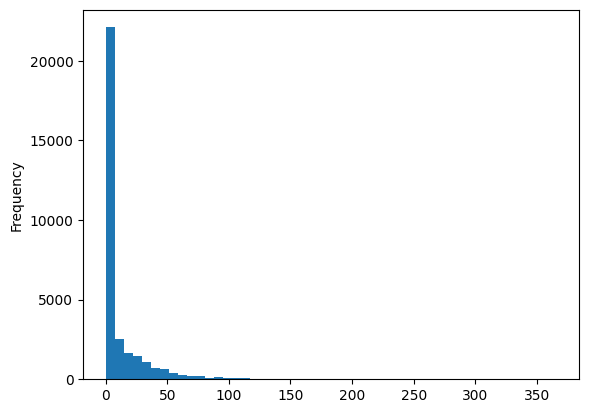

In [ ]:
grid_scores['intersection_count'].plot(kind='hist', bins=50)

In [ ]:
grid_scores["intersection_count"].rank(pct=True).describe()


,intersection_count
count,32034.000000
mean,0.500016
std,0.272556
min,0.238138
25%,0.238138
50%,0.512081
75%,0.744615
max,1.000000


In [ ]:
grid_scores["has_intersection"] = (grid_scores["intersection_count"] > 0).astype(int)

In [ ]:
positive = grid_scores["intersection_count"] > 0

grid_scores.loc[positive, "intersection_scaled"] = (
    grid_scores.loc[positive, "intersection_count"] /
    grid_scores.loc[positive, "intersection_count"].max()
)

grid_scores.loc[~positive, "intersection_scaled"] = 0

In [ ]:
grid_scores["intersection_scaled"].describe()

,intersection_scaled
count,32034.000000
mean,0.030829
std,0.063474
min,0.000000
25%,0.000000
50%,0.002732
75%,0.032787
max,1.000000


In [ ]:
grid_scores.columns

Index(['grid_id', 'total_length', 'total_rtpi', 'total_rtpi_norm',
       'total_accessibility', 'total_exposure_core', 'total_reliability',
       'grid_rtpi_mean', 'grid_rtpi_mean_norm', 'grid_accessibility_mean',
       'grid_exposure_core_mean', 'grid_reliability_mean', 'commune',
       'geometry', 'area', 'intersection_count', 'centroid',
       'has_intersection', 'intersection_scaled'],
      dtype='object')

In [ ]:
alpha = 0.5

grid_scores["retail_score"] = (
    (grid_scores["grid_rtpi_mean_norm"]) *
    (1 + alpha * grid_scores["intersection_scaled"])
)



In [ ]:
grid_scores["retail_score"].corr(grid_scores["intersection_scaled"])

np.float64(0.0480528878400332)

In [ ]:
grid_scores.head(1)

,grid_id,total_length,total_rtpi,total_rtpi_norm,total_accessibility,total_exposure_core,total_reliability,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,commune,geometry,area,intersection_count,centroid,has_intersection,intersection_scaled,retail_score
0,6,668.307394,10249.243946,12363.561839,320.342322,301.565821,66.292807,15.336122,18.499813,0.479334,0.451238,0.099195,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",102400.0,0.0,POINT (-16.00639 23.64318),0,0.0,18.499813


In [ ]:
grid_scores.drop(columns=['total_rtpi', 'total_rtpi_norm',
       'total_accessibility', 'total_exposure_core', 'total_reliability'], inplace=True)

In [ ]:
grid_scores.head(5)

,grid_id,total_length,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,commune,geometry,area,intersection_count,centroid,has_intersection,intersection_scaled,retail_score
0,6,668.307394,15.336122,18.499813,0.479334,0.451238,0.099195,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",102400.000000,0.0,POINT (-16.00639 23.64318),0,0.0,18.499813
1,7,475.473210,14.765516,17.722678,0.479334,0.452906,0.081906,Dakhla,"POLYGON ((-215636.284 2632813.377, -215636.284...",102236.480842,0.0,POINT (-16.00654 23.64604),0,0.0,17.722678
2,13,727.478540,15.542463,18.780838,0.479334,0.449278,0.105862,Dakhla,"POLYGON ((-215636.284 2631853.377, -215636.284...",102400.000000,0.0,POINT (-16.00312 23.64045),0,0.0,18.780838
3,14,75.201438,15.556144,18.799470,0.479334,0.450595,0.105862,Dakhla,"POLYGON ((-215636.284 2632173.377, -215636.284...",102400.000000,0.0,POINT (-16.00327 23.64332),0,0.0,18.799470
4,15,242.409722,14.765516,17.722678,0.479334,0.452906,0.081906,Dakhla,"POLYGON ((-215636.284 2632493.377, -215636.284...",102400.000000,0.0,POINT (-16.00343 23.64619),0,0.0,17.722678


In [ ]:
grid_scores.columns

Index(['grid_id', 'total_length', 'grid_rtpi_mean', 'grid_rtpi_mean_norm',
       'grid_accessibility_mean', 'grid_exposure_core_mean',
       'grid_reliability_mean', 'commune', 'geometry', 'area',
       'intersection_count', 'centroid', 'has_intersection',
       'intersection_scaled', 'retail_score'],
      dtype='object')

In [ ]:
grid_scores["retail_score"].corr(grid_scores["grid_rtpi_mean_norm"])

np.float64(0.9998332612364963)

In [ ]:
grid_scores["rank_rtpi"] = grid_scores["grid_rtpi_mean_norm"].rank(ascending=False)
grid_scores["rank_final"] = grid_scores["retail_score"].rank(ascending=False)

(grid_scores["rank_rtpi"] - grid_scores["rank_final"]).abs().describe()

,0
count,32034.000000
mean,305.865237
std,463.485412
min,0.000000
25%,28.125000
50%,182.000000
75%,416.000000
max,7905.000000


In [ ]:
grid_scores.sort_values("retail_score", ascending=False).head(5)

,grid_id,total_length,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,commune,geometry,area,intersection_count,centroid,has_intersection,intersection_scaled,retail_score,rank_rtpi,rank_final
24772,122283,1.177325,63.479193,100.0,0.515041,0.675407,0.998967,Souk Kdim,"POLYGON ((820203.716 3940973.377, 820203.716 3...",7550.703278,1.0,POINT (-5.46856 35.56061),1,0.002732,100.136612,3.5,1.0
10983,57158,116.029927,59.091805,100.0,0.526375,0.616465,0.993459,Settat,"POLYGON ((629483.716 3646893.377, 629637.505 3...",12638.732476,0.0,POINT (-7.61415 32.95219),0,0.000000,100.000000,3.5,4.0
15407,69613,51.329862,69.473252,100.0,0.687097,0.697278,1.000000,Yacoub El Mansour,"POLYGON ((691056.961 3756973.377, 691017.484 3...",2029.813581,0.0,POINT (-6.93331 33.93578),0,0.000000,100.000000,3.5,4.0
5081,32606,3.269188,57.966577,100.0,0.507358,0.603891,0.999797,Harbil,"POLYGON ((580203.716 3516013.377, 580203.716 3...",102400.000000,0.0,POINT (-8.15124 31.77828),0,0.000000,100.000000,3.5,4.0
10939,57050,83.932061,59.091805,100.0,0.526375,0.616465,0.993459,Settat,"POLYGON ((629163.716 3646573.377, 629163.716 3...",91068.237375,0.0,POINT (-7.61657 32.95139),0,0.000000,100.000000,3.5,4.0


In [ ]:
grid_scores["retail_score_norm"] = (
    grid_scores.groupby("commune")["retail_score"]
    .transform(lambda x: 100 * (x - x.min()) / (x.max() - x.min()))
)

In [ ]:
grid_scores.drop(columns=['rank_rtpi', 'rank_final'], inplace=True)

In [ ]:
grid_scores.columns

Index(['grid_id', 'total_length', 'grid_rtpi_mean', 'grid_rtpi_mean_norm',
       'grid_accessibility_mean', 'grid_exposure_core_mean',
       'grid_reliability_mean', 'commune', 'geometry', 'area',
       'intersection_count', 'centroid', 'has_intersection',
       'intersection_scaled', 'retail_score', 'retail_score_norm'],
      dtype='object')

In [ ]:
ordered_cols = [
    "grid_id",
    "commune",
    "geometry",
    "centroid",
    "area",
    "total_length",
    "intersection_count",
    "has_intersection",
    "intersection_scaled",
    "grid_rtpi_mean",
    "grid_rtpi_mean_norm",
    "grid_accessibility_mean",
    "grid_exposure_core_mean",
    "grid_reliability_mean",
    "retail_score",
    "retail_score_norm"
]

grid_scores = grid_scores[ordered_cols]

In [ ]:
grid_scores.head(1)

,grid_id,commune,geometry,centroid,area,total_length,intersection_count,has_intersection,intersection_scaled,grid_rtpi_mean,grid_rtpi_mean_norm,grid_accessibility_mean,grid_exposure_core_mean,grid_reliability_mean,retail_score,retail_score_norm
24772,122283,Souk Kdim,"POLYGON ((820203.716 3940973.377, 820203.716 3...",POINT (-5.46856 35.56061),7550.703278,1.177325,1.0,1,0.002732,63.479193,100.0,0.515041,0.675407,0.998967,100.136612,100.0


In [ ]:
grid_scores.to_csv("grid_scores.csv", index=False)

In [ ]:
grid_scores_d = gpd.GeoDataFrame(grid_scores, geometry="geometry", crs=32629)

In [ ]:
grid_scores_d.drop(columns=['centroid'], inplace=True)
grid_scores_d.to_file("grid_scores.gpkg")

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.1 MB/s eta 0:00:00


In [ ]:
loaded_df = pd.read_pickle('graph_data_commune_142.pkl')
df_communes_with_g = pd.DataFrame({"com_name" : list(loaded_df.keys()), "graph": list(loaded_df.values())})

In [ ]:
import osmnx as ox

In [ ]:
ox.graph_to_gdfs(df_communes_with_g["graph"][0])

In [ ]:
all_nodes = []



for idx, row in df_communes_with_g.iterrows():

    commune_name = row["com_name"]
    G = row["graph"]


    G_undirected = G.to_undirected()

    # Extract nodes
    nodes = ox.graph_to_gdfs(G_undirected, edges=False)

    degree_dict = dict(G_undirected.degree())
    nodes["degree"] = nodes.index.map(degree_dict)

    nodes = nodes[nodes["degree"] > 2].copy()

    nodes["commune"] = commune_name

    all_nodes.append(nodes)

In [ ]:
all_nodes[0]

,y,x,street_count,highway,geometry,degree,commune
osmid,,,,,,,
28849650,23.704762,-15.927430,3,NaN,POINT (-15.92743 23.70476),3,Dakhla
348237696,23.693994,-15.938133,3,NaN,POINT (-15.93813 23.69399),3,Dakhla
348237697,23.695823,-15.940120,3,NaN,POINT (-15.94012 23.69582),3,Dakhla
348237699,23.690042,-15.942472,3,NaN,POINT (-15.94247 23.69004),3,Dakhla
348237701,23.695896,-15.947647,3,NaN,POINT (-15.94765 23.6959),3,Dakhla
...,...,...,...,...,...,...,...
13253618195,23.713237,-15.944201,3,NaN,POINT (-15.9442 23.71324),3,Dakhla
13253618196,23.712797,-15.943931,3,NaN,POINT (-15.94393 23.7128),3,Dakhla
13253733603,23.712676,-15.942751,3,NaN,POINT (-15.94275 23.71268),3,Dakhla


In [ ]:
intersection_nodes = gpd.GeoDataFrame(
    pd.concat(all_nodes, ignore_index=True),
    crs=nodes.crs
)

In [ ]:
intersection_nodes = intersection_nodes.to_crs(grid_scores_d.crs)

In [ ]:
nodes_with_grid = gpd.sjoin(
    intersection_nodes,
    grid[["grid_id", "commune", "geometry"]],
    how="left",
    predicate="within"
)

In [ ]:
node_counts = (
    nodes_with_grid
    .groupby("grid_id")
    .size()
    .reset_index(name="intersection_count")
)

In [ ]:
grid = grid.merge(node_counts, on="grid_id", how="left")
grid["intersection_count"] = grid["intersection_count"].fillna(0)

In [ ]:
grid["intersection_count"].value_counts()
g_n = grid.copy()

In [ ]:
grid.to_csv("grid_with_intersections.csv", index=False)

In [ ]:
grid.head(10)

,id,commune,geometry,grid_id,grid_rtpi_mean,grid_rtpi_mass
0,0,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",0,0.000000,0.000000
1,0,Dakhla,"POLYGON ((-215956.284 2632493.377, -215956.284...",1,0.000000,0.000000
2,0,Dakhla,"POLYGON ((-215956.284 2632493.377, -216275.83 ...",2,0.000000,0.000000
3,0,Dakhla,"POLYGON ((-215636.284 2631533.377, -215636.284...",3,0.000000,0.000000
4,0,Dakhla,"POLYGON ((-215636.284 2631853.377, -215636.284...",4,0.000000,0.000000
5,0,Dakhla,"POLYGON ((-215956.284 2632173.377, -215636.284...",5,0.000000,0.000000
6,0,Dakhla,"POLYGON ((-215956.284 2632173.377, -215956.284...",6,15.336122,10249.243946
7,0,Dakhla,"POLYGON ((-215636.284 2632813.377, -215636.284...",7,14.765516,7020.607425
8,0,Dakhla,"POLYGON ((-215636.284 2632813.377, -215937.607...",8,0.000000,0.000000
9,0,Dakhla,"POLYGON ((-215316.284 2630893.377, -215316.284...",9,0.000000,0.000000


In [ ]:
grid.to_csv("grid.csv", index=False)

In [ ]:
roads_grid['grid_id'] = roads_grid.index

In [ ]:
roads_grid.head(1)

,streetName,centroid,commune_1,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,...,reliability,accessibility,RTPI_raw,RTPI,id,commune_2,geometry,length_in_cell,weighted_rtpi,grid_id
0,طريق تويمة,POINT (-2.93239 35.16704),Nador,primary,False,137.356588,7.3,21159,24.8,18.82,...,0.908479,0.979137,0.80061,80.060963,137,Nador,"LINESTRING (1052908.546 3908442.77, 1052894.66...",50.168131,4016.508931,0


KeyError: "['id'] not in index"

In [10]:
import pandas as pd

In [1]:
!gdown 1-xMw5C1c9EZ-UBWILabaw0Pk2-aNyRKv

Downloading...
From (original): https://drive.google.com/uc?id=1-xMw5C1c9EZ-UBWILabaw0Pk2-aNyRKv
From (redirected): https://drive.google.com/uc?id=1-xMw5C1c9EZ-UBWILabaw0Pk2-aNyRKv&confirm=t&uuid=b9e36cbe-d19a-4350-a62b-66d3e106db6d
To: /content/merged_jobs.geojson
100% 2.01G/2.01G [00:29<00:00, 68.6MB/s]


In [2]:
import geopandas as gpd

trafic_raw = gpd.read_file("/content/merged_jobs.geojson")

In [14]:
trafic_raw.head(1)

,jobName,creationTime,segmentId,newSegmentId,speedLimit,frc,streetName,distance,segmentTimeResults,userPreference,dateRanges,timeSets,networkName,zoneId,probeSource,mapsVersions,geometry
0,polygon_2,2026-02-18 15:29:24.780000+00:00,NaN,None,NaN,NaN,None,NaN,None,"{'distanceUnit': 'KILOMETERS', 'includedSpeedL...","[{'@id': 1, 'name': 'all_month', 'from': '2024...","[{'@id': 2, 'name': '7:00-23:00', 'dayToTimeRa...",polygon_2,Africa/Casablanca,ALL,[['SouthWestEurope_eur2026.01.1400-23.126-0 OP...,None


In [8]:
gdf_with_speed = trafic_raw[trafic_raw['segmentTimeResults'].notna()].copy()

In [11]:
gdf_exploded = gdf_with_speed.explode('segmentTimeResults', ignore_index=True)

# Now normalize/expand the segmentTimeResults dictionary into separate columns
# This extracts all nested keys as columns
segment_results_df = pd.json_normalize(gdf_exploded['segmentTimeResults'])

# Reset index to align with the exploded GeoDataFrame
segment_results_df.index = gdf_exploded.index

# Drop the original segmentTimeResults column and join the new columns
gdf_final = gdf_exploded.drop('segmentTimeResults', axis=1).join(segment_results_df)

In [17]:
gdf_final.geometry

,geometry
0,"LINESTRING (-6.30668 34.80882, -6.30655 34.808..."
1,"LINESTRING (-6.30629 34.808, -6.3064 34.8084, ..."
2,"LINESTRING (-6.30668 34.80882, -6.30695 34.808..."
3,"LINESTRING (-6.30788 34.80711, -6.30783 34.807..."
4,"LINESTRING (-6.30788 34.80711, -6.3081 34.8069..."
...,...
2076683,"LINESTRING (-8.54277 30.72463, -8.54272 30.724..."
2076684,"LINESTRING (-8.54277 30.72463, -8.54294 30.724..."
2076685,"LINESTRING (-8.54324 30.72438, -8.54294 30.724..."
2076686,"LINESTRING (-8.54324 30.72438, -8.5433 30.7243..."


In [ ]:


# north = 33.6747424
# south = 33.2966072
# east = -7.3631248
# west = -7.8985737


# G = get_graph_data(coords=(west, south, east, north))


edges = ox.graph_to_gdfs(G, nodes=False)
edges



road_data = get_roads_data(edges)

# traffic_data = pd.read_csv("/content/casablanca_traffic_aug_2024.csv")

# traffic_data.drop(columns=["Unnamed: 0"], inplace=True)

# traffic_data.head()

# road_data.head()





def join_tomtom_road(tomtom_df, road_df):
  try:
    road_traffic = tomtom_df.copy()
    road_traffic["geometry"] = road_traffic["shape"].apply(wkt.loads)
    osmnx_gdf = gpd.GeoDataFrame(road_df, geometry="geometry", crs="EPSG:3857")
    tomtom_gdf = gpd.GeoDataFrame(road_traffic, geometry="geometry", crs="EPSG:3857")
    tomtom_gdf = tomtom_gdf.reset_index().rename(columns={"index": "traffic_id"})
    tomtom_join_road = gpd.sjoin_nearest(tomtom_gdf, osmnx_gdf, how="left", distance_col="dist")
    tomtom_best_match = (
      tomtom_join_road
      .sort_values("dist")
      .drop_duplicates(subset="traffic_id")
      .reset_index(drop=True)
    )
    date_time = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")

    tomtom_best_match.to_csv(f"tomtom_best_match_road_{date_time}.csv", index=False)
    print(f"Data saved to tomtom_best_match_road_{date_time}.csv")
    return tomtom_best_match
  except Exception as e:
    print(f"Error in join_tomtom_road: {e}")
    return pd.DataFrame()

tom_data = join_tomtom_road(traffic_data, road_data)

tom_data.columns

tom_data.head()

f = traffic_data["medianSpeed"] == 0.0

f.value_counts()

traffic_data[traffic_data["medianSpeed"] == 0.0 ]["sampleSize"].unique()

cleaned_traffic_data = tom_data[
    (tom_data["medianSpeed"] > 0.0) & (tom_data["sampleSize"] > 0)
]

cleaned_traffic_data.head()

cleaned_traffic_data.columns

#Metaphor: Imagine a billboard on a slow, wide boulevard. The slower the traffic and the bigger the road, the longer and wider your store gets seen
cleaned_traffic_data["RVES"] = (1 / cleaned_traffic_data["harmonicAverageSpeed"]) * (cleaned_traffic_data["lanes"] + 1) * (cleaned_traffic_data["width_estimated"]) * (cleaned_traffic_data["length"])

# Imagine how “healthy” a person walks — average and median walking speeds should match. If not, they’re limping. Same with roads: unstable roads = unstable business flow.
cleaned_traffic_data["TFHI"] = (cleaned_traffic_data["averageSpeed"] / cleaned_traffic_data["medianSpeed"]) * (1 - cleaned_traffic_data["travelTimeRatio"])

#Metaphor: A road with mood swings — one day it's calm, the next it’s chaos. Customers don’t like surprises on the road.
cleaned_traffic_data["CVR"] = cleaned_traffic_data["travelTimeStandardDeviation"] / cleaned_traffic_data["averageTravelTime"]

#ou’re dating a road. You want it hot (visible), stable (predictable), and consistent (healthy flow). RSAS is the love score for retail decision-makers.
cleaned_traffic_data["RSAS"] = cleaned_traffic_data["RVES"] * (1 - cleaned_traffic_data["CVR"]) * cleaned_traffic_data["TFHI"]

#Estimate how easy it is to enter/exit the road. Very important for customer conversion.
cleaned_traffic_data["IEFS"] = (
    (cleaned_traffic_data["lanes"] + 1) *
    cleaned_traffic_data["width_estimated"] *
    cleaned_traffic_data["oneway"].apply(lambda x: 1 if x == False else 0.5)
)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_scale = ["RSAS", "IEFS"]

cleaned_traffic_data[[f"{col}_scaled" for col in columns_to_scale]] = scaler.fit_transform(
    cleaned_traffic_data[columns_to_scale]
)

cleaned_traffic_data["RTPI"] = 0.7 * cleaned_traffic_data["RSAS_scaled"] + 0.3 * cleaned_traffic_data["IEFS_scaled"]

cleaned_traffic_data["RTPI"].describe()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cleaned_traffic_data["RTPI_scaled"] = scaler.fit_transform(
    cleaned_traffic_data[["RTPI"]]
) * 100  # scale to 0–100

cleaned_traffic_data["RTPI"].describe()

In [ ]:
correlation_columns = [
    "RTPI",
    "harmonicAverageSpeed",
    "length",
    "lanes",
    "sampleSize"
]

correlations = df_final[correlation_columns].corr(method='pearson')

print("Pearson Correlation Coefficients with RTPI:")
correlations['RTPI']

Pearson Correlation Coefficients with RTPI:


,RTPI
RTPI,1.000000
harmonicAverageSpeed,0.294941
length,0.181708
lanes,0.471252
sampleSize,0.459842


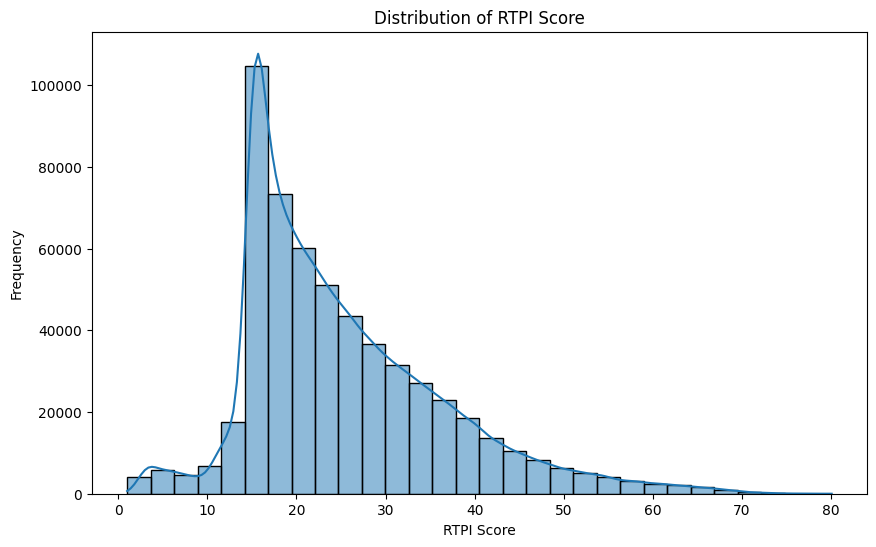

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['RTPI'], bins=30, kde=True)
plt.title('Distribution of RTPI Score')
plt.xlabel('RTPI Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
highway_rtpi_summary = df_final.groupby('highway')['RTPI'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)
print("Mean and Median RTPI by Highway Type:")
highway_rtpi_summary

Mean and Median RTPI by Highway Type:


,mean,median
highway,,
motorway,52.352254,53.082315
primary,41.709282,42.333856
trunk,41.208839,43.608736
secondary,37.002398,37.395266
tertiary,32.211885,32.399096
motorway_link,29.196622,27.613809
trunk_link,28.585875,28.337213
unclassified,24.079974,21.383001
secondary_link,23.678890,22.524983


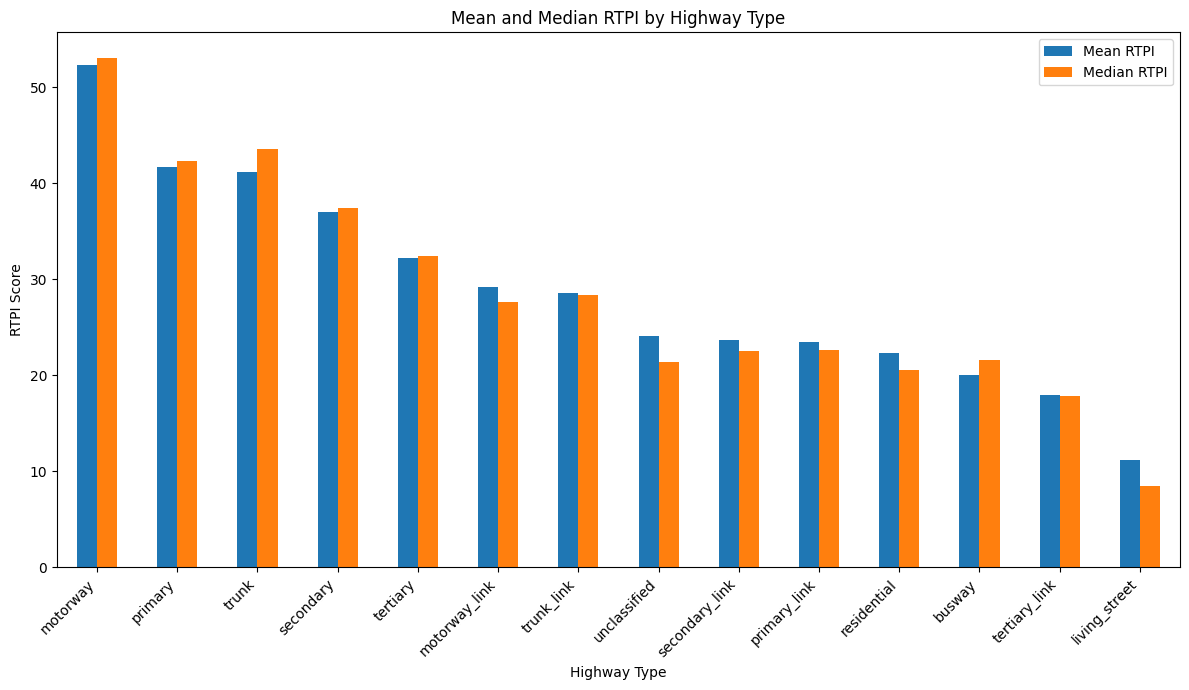

In [ ]:
highway_rtpi_summary.plot(kind='bar', figsize=(12, 7))
plt.title('Mean and Median RTPI by Highway Type')
plt.xlabel('Highway Type')
plt.ylabel('RTPI Score')
plt.xticks(rotation=45, ha='right')
plt.legend(['Mean RTPI', 'Median RTPI'])
plt.tight_layout()
plt.show()

In [ ]:
df_final[df_final["commune"] == 'Maârif'].sort_values("RTPI", ascending=False).head(20)

,streetName,geometry,centroid,commune,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,lanes,width_estimated,exposure_core,reliability,accessibility,RTPI_raw,RTPI
4,شارع المسيرة الخضراء,"LINESTRING (626813.32 3717183.907, 626888.883 ...",POINT (-7.633009899999999 33.586883650000004),Maârif,primary,False,124.351280,9.3,34367,29.43,23.71,6.0,19.5,0.822783,0.879980,0.980132,0.788057,78.805729
18,شارع محمد الزرقطوني,"LINESTRING (626936.476 3717202.601, 626964.926...",POINT (-7.631936200000001 33.5869128),Maârif,primary,False,124.351280,15.6,77302,7.74,7.74,6.0,19.5,0.727312,0.948273,0.980132,0.762301,76.230084
21,شارع ابراهيم الروداني,"LINESTRING (626380.973 3716064.057, 626356.297...",POINT (-7.63836945 33.57665275),Maârif,primary,False,130.391034,16.4,64866,8.81,8.53,8.0,26.0,0.730180,0.933496,0.999653,0.761128,76.112810
46,شارع المقاومة,"LINESTRING (628148.554 3716740.531, 628151.322...",POINT (-7.6188624123733195 33.582698960621215),Maârif,primary,False,137.048557,13.7,57238,11.49,13.28,6.0,19.5,0.725807,0.922956,0.980132,0.747449,74.744892
62,شارع أنفا,"LINESTRING (626484.724 3717606.128, 626527.064...",POINT (-7.63666845 33.59077695),Maârif,primary,False,70.856888,8.4,32283,20.28,19.12,6.0,19.5,0.757028,0.874709,0.980132,0.741667,74.166730
74,شارع ابراهيم الروداني,"LINESTRING (626405.649 3716095.722, 626436.367...",POINT (-7.63779575 33.577252599999994),Maârif,primary,False,130.391034,24.6,71514,7.33,5.90,8.0,26.0,0.690981,0.941716,0.999653,0.737944,73.794444
88,زنقة المامون محمد,"LINESTRING (625561.265 3716530.003, 625546.056...",POINT (-7.647166189505715 33.581023115804754),Maârif,tertiary,False,273.236057,8.4,16806,14.81,15.40,6.0,19.5,0.799271,0.819713,0.980132,0.736413,73.641275
94,شارع المسيرة الخضراء,"LINESTRING (626324.46 3717181.161, 626299.692 ...",POINT (-7.6388181 33.5868894),Maârif,primary,False,114.386316,7.0,28784,12.77,15.60,6.0,19.5,0.755171,0.865044,0.980132,0.734975,73.497526
97,RR320,"LINESTRING (625825.212 3717275.82, 625828.113 ...",POINT (-7.643923983619626 33.587833611948724),Maârif,tertiary,False,186.480667,19.9,74639,4.98,5.63,6.0,19.5,0.689515,0.945320,0.980132,0.733892,73.389197
101,زنقة سقراط,"LINESTRING (625939.201 3715896.609, 625956.797...",POINT (-7.642882979839407 33.57517139724584),Maârif,tertiary,False,238.113195,5.8,18607,27.53,27.77,4.0,13.0,0.810632,0.828289,0.919226,0.733385,73.338522


In [ ]:
unique_roads_per_cell = roads_grid.groupby('grid_id')['logical_road_id'].nunique().reset_index(name='unique_road_count')
print("First 5 rows of unique road counts per grid cell:")
unique_roads_per_cell[unique_roads_per_cell["unique_road_count"] > 1].head()


First 5 rows of unique road counts per grid cell:


,grid_id,unique_road_count
25,107,2
26,127,2
27,128,2
28,148,2
29,149,2


In [ ]:
roads_grid[roads_grid["grid_id"] == 107]

,streetName,centroid,commune_1,highway,oneway,length,harmonicAverageSpeed,sampleSize,averageTravelTime,travelTimeStandardDeviation,...,RTPI_raw,RTPI,RTPI_normalized,RTPI_normalized_par_com,commune_2,grid_id,geometry,length_in_cell,total_roads,logical_road_id
651844,,POINT (-15.985701811146786 23.673477846695015),Dakhla,tertiary,False,6700.350525,70.8,1,25.42,0.0,...,0.147434,14.743353,17.692493,17.692493,Dakhla,107,"LINESTRING (-213465.759 2635693.377, -213440.0...",148.942142,4,UNNAMED_107_tertiary_False
652206,,POINT (-15.985701811146786 23.67347784669502),Dakhla,tertiary,False,6700.350525,76.4,1,23.56,0.0,...,0.147356,14.735586,17.681915,17.681915,Dakhla,107,"LINESTRING (-213418.203 2635834.501, -213440.0...",148.942142,4,UNNAMED_107_tertiary_False
652348,,POINT (-15.983878017590527 23.677650201691954),Dakhla,unclassified,False,1907.128851,73.5,1,24.49,0.0,...,0.147325,14.732506,17.677720,17.677720,Dakhla,107,"LINESTRING (-213418.203 2635834.501, -213402.4...",65.765371,4,UNNAMED_107_unclassified_False
652423,,POINT (-15.983878017590525 23.677650201691947),Dakhla,tertiary,False,412.419707,60.2,1,29.90,0.0,...,0.147309,14.730873,17.675495,17.675495,Dakhla,107,"LINESTRING (-213396.284 2635896.505, -213402.4...",65.765371,4,UNNAMED_107_tertiary_False


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkb

In [ ]:
trafic_data = gpd.read_parquet("/content/tomtom_final_trafic_142.parquet")

In [ ]:
trafic_data.geometry

,geometry
0,"LINESTRING (1052908.546 3908442.77, 1052894.66..."
1,"LINESTRING (594135.714 3495441.022, 594152.651..."
2,"LINESTRING (597611.688 3499157.989, 597612.23 ..."
3,"LINESTRING (543105.847 3571157.008, 543122.297..."
4,"LINESTRING (626813.32 3717183.907, 626888.883 ..."
...,...
567033,"LINESTRING (829359.892 3973290.944, 829358.954..."
567034,"LINESTRING (836745.265 3948977.114, 836721.864..."
567035,"LINESTRING (695615.607 3638209.81, 695590.423 ..."
567036,"LINESTRING (640333.62 3712715.572, 640328.574 ..."


In [ ]:
new_point = (33.866343,-6.856388)
point_gpd = gpd.GeoDataFrame(geometry=gpd.points_from_xy([new_point[1]], [new_point[0]]), crs="EPSG:4326")
point_gpd = point_gpd.to_crs(trafic_data.crs)

In [ ]:
point_gpd

,geometry
0,POINT (698285.095 3749404.09)


In [ ]:
iso = gpd.read_file("/content/ZC_Test_Yacoub_Mansour_enrichi_Data.gpkg")

In [ ]:
iso.head(4)

,ID,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP,Shop code,Brand,Name,Shop concept,...,Rayon_tradi_pres,Rayon_tradi_reel,Rayon_stand_coupe_pres,Rayon_stand_coupe_reel,CHECK_CA_prop_conc,CHECK_CA_brand_sum,CHECK_CA_cluster_sum,CHECK_PDM_brand_sum,CHECK_PDM_cluster_sum,geometry
0,None,-9.509775778181599,30.3890368218184,10,driving-car,690441,212,Carrefour Hyper,AGADIR-AGADIR,Hyper premium,...,17,8,17,8,0.000000e+00,-2.384186e-07,-2.384186e-07,-1.110223e-16,-1.110223e-16,"POLYGON ((445752.097 3366354.968, 445745.117 3..."
1,None,-9.509775778181599,30.3890368218184,18,driving-car,1292447,212,Carrefour Hyper,AGADIR-AGADIR,Hyper premium,...,18,17,18,17,-9.536743e-07,-4.768372e-07,-4.768372e-07,-2.220446e-16,-1.110223e-16,"POLYGON ((440280.171 3365959.222, 440703.526 3..."
2,None,-8.05904832944428,31.650953095359807,10,driving-car,349486,205,Carrefour Hyper,TARGA-MARRAKECH,Hyper premium,...,25,20,27,21,4.768372e-07,9.536743e-07,9.536743e-07,4.440892e-16,4.440892e-16,"POLYGON ((579930.554 3504805.381, 579931.058 3..."
3,None,-8.05904832944428,31.650953095359807,18,driving-car,1384119,205,Carrefour Hyper,TARGA-MARRAKECH,Hyper premium,...,25,25,27,27,0.000000e+00,4.768372e-07,4.768372e-07,0.000000e+00,0.000000e+00,"POLYGON ((581436.795 3516378.367, 581514.682 3..."


In [ ]:
iso_int = iso[['AA_MINS','Shop code', 'Name','geometry']].copy()

In [ ]:
iso_int = point_gpd.copy()

In [ ]:
iso_int.head()

,geometry
0,POINT (698285.095 3749404.09)


In [ ]:
iso_int.geometry

,geometry
0,POINT (698285.095 3749404.09)


In [ ]:
iso_int["idx"] = iso_int.index

In [ ]:
trafic_x_iso = gpd.sjoin(trafic_gdf, iso_int, how="inner", predicate="intersects")

In [ ]:
trafic_x_iso.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 895519 entries, 1 to 567037
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   895519 non-null  object  
 1   geometry                     895519 non-null  object  
 2   centroid                     895519 non-null  object  
 3   commune                      895519 non-null  object  
 4   highway                      895519 non-null  object  
 5   oneway                       895519 non-null  bool    
 6   length                       895519 non-null  float64 
 7   harmonicAverageSpeed         895519 non-null  float64 
 8   sampleSize                   895519 non-null  int64   
 9   averageTravelTime            895519 non-null  float64 
 10  travelTimeStandardDeviation  895519 non-null  float64 
 11  lanes                        895519 non-null  float64 
 12  width_estimated              895519 non-n

In [ ]:
new_trafic = trafic_x_iso.drop(columns=['index_right','AA_MINS','Shop code','Name',])

In [ ]:
new_trafic_g = new_trafic.groupby("idx").agg(
    {
        "averageTravelTime": "mean",
        "sampleSize": "sum",
        "harmonicAverageSpeed": "mean",
        "length": "sum",
        "lanes": "mean",
        "travelTimeStandardDeviation" : "mean",
        "reliability" : "mean",
        "RTPI": "mean",
        "accessibility" : "mean",





<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 895519 entries, 1 to 567037
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   streetName                   895519 non-null  object  
 1   geometry                     895519 non-null  object  
 2   centroid                     895519 non-null  object  
 3   commune                      895519 non-null  object  
 4   highway                      895519 non-null  object  
 5   oneway                       895519 non-null  bool    
 6   length                       895519 non-null  float64 
 7   harmonicAverageSpeed         895519 non-null  float64 
 8   sampleSize                   895519 non-null  int64   
 9   averageTravelTime            895519 non-null  float64 
 10  travelTimeStandardDeviation  895519 non-null  float64 
 11  lanes                        895519 non-null  float64 
 12  width_estimated              895519 non-n

In [ ]:
polygons_idx = trafic_x_iso.groupby("idx")

In [ ]:
# Check which rows have invalid geometries
invalid_mask = ~trafic_gdf.geometry.is_valid
print(f"Number of invalid geometries: {invalid_mask.sum()}")

# Check for empty geometries
empty_mask = trafic_gdf.geometry.is_empty
print(f"Number of empty geometries: {empty_mask.sum()}")

# Check for NaN in geometry column
nan_mask = trafic_gdf.geometry.isna()
print(f"Number of null geometries: {nan_mask.sum()}")

# Inspect first few geometries
for i in range(min(5, len(trafic_gdf))):
    print(f"Row {i}: {trafic_gdf.iloc[i].geometry}")
    print(f"  Bounds: {trafic_gdf.iloc[i].geometry.bounds}")

Number of invalid geometries: 567038
Number of empty geometries: 0
Number of null geometries: 0
Row 0: LINESTRING (Infinity Infinity, Infinity Infinity)
  Bounds: (inf, inf, inf, inf)
Row 1: LINESTRING (Infinity Infinity, Infinity Infinity)
  Bounds: (inf, inf, inf, inf)
Row 2: LINESTRING (Infinity Infinity, Infinity Infinity, Infinity Infinity)
  Bounds: (inf, inf, inf, inf)
Row 3: LINESTRING (Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity, Infinity Infinity)
  Bounds: (inf, inf, inf, inf)
Row 4: LINESTRING (Infinity Infinity, Infinity Infinity)
  Bounds: (inf, inf, inf, inf)


In [ ]:
# Look at the raw "geometry" column before conversion
print(type(trafic_data['geometry'].iloc[0]))
print(repr(trafic_data['geometry'].iloc[0][:100]))  # First 100 chars

# Check if it's already WKT strings
sample = trafic_data['geometry'].iloc[0]
if isinstance(sample, str):
    print("It's a string - likely WKT")
    print(sample[:200])
elif isinstance(sample, bytes):
    print("It's bytes - likely real WKB")
    print(sample[:50])

<class 'shapely.geometry.linestring.LineString'>


TypeError: 'LineString' object is not subscriptable

In [ ]:
from shapely import wkb
import numpy as np

# Try loading with explicit endian handling
def safe_load_wkb(wkb_bytes):
    try:
        # Force little-endian interpretation
        geom = wkb.loads(wkb_bytes, hex=False)

        # Check if coordinates are reasonable
        if hasattr(geom, 'coords'):
            coords = list(geom.coords)
            # Check for infinity or extreme values
            if any(np.isinf(c).any() for c in coords):
                return None
            if any(np.isnan(c).any() for c in coords):
                return None
            # Check for reasonable coordinate ranges (UTM zone 29N)
            # Morocco UTM 29N should be roughly: x: 200,000-900,000, y: 3,000,000-4,500,000
            valid = all(200000 < x < 1000000 and 3000000 < y < 5000000 for x, y in coords)
            return geom if valid else None
        return geom
    except Exception as e:
        print(f"Error loading WKB: {e}")
        return None

# Apply to your data
trafic_data['geometry_clean'] = trafic_data['geometry'].apply(safe_load_wkb)

# Remove failed geometries
trafic_gdf = gpd.GeoDataFrame(
    trafic_data[trafic_data['geometry_clean'].notna()],
    geometry='geometry_clean',
    crs="EPSG:32629"
)

print(f"Valid geometries: {len(trafic_gdf)} out of {len(trafic_data)}")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Expected bytes or string, got LineString
Error loading WKB: Exp

In [ ]:
# Check CRS of both
print("trafic_gdf CRS:", trafic_gdf.crs)
print("iso_int CRS:", iso_int.crs)

# Check coordinate ranges
print("trafic_gdf bounds:", trafic_gdf.total_bounds)
print("iso_int bounds:", iso_int.total_bounds)

trafic_gdf CRS: EPSG:32629
iso_int CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / UTM zone 29N", "base_crs": {"name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", 

In [ ]:
pts_indx = gpd.read_file("/content/poits_nv.gpkg")

In [ ]:
pts_indx.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 25 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Shop code                                            20 non-null     object        
 1   Brand                                                20 non-null     object        
 2   Name                                                 19 non-null     object        
 3   Ville                                                19 non-null     object        
 4   Lat                                                  19 non-null     float64       
 5   Lon                                                  19 non-null     float64       
 6   State                                                19 non-null     object        
 7   Rayon alcool (rayon_alcool)                          20 non-null     bool          

In [ ]:
pts_int = pts_indx[['Shop code','Name','geometry']].copy()

In [ ]:
pts_int = point_gpd.copy()

In [ ]:
pts_int["buffer_100m"] = pts_int.buffer(100)
pts_int["buffer_200m"] = pts_int.buffer(200)
pts_int["buffer_300m"] = pts_int.buffer(300)
pts_int["buffer_400m"] = pts_int.buffer(400)
pts_int["buffer_500m"] = pts_int.buffer(500)
pts_int["buffer_600m"] = pts_int.buffer(600)
pts_int["buffer_700m"] = pts_int.buffer(700)

In [ ]:
pts_int

,geometry,buffer_100m,buffer_200m,buffer_300m,buffer_400m,buffer_500m,buffer_600m,buffer_700m
0,POINT (698285.095 3749404.09),"POLYGON ((698385.095 3749404.09, 698384.614 37...","POLYGON ((698485.095 3749404.09, 698484.132 37...","POLYGON ((698585.095 3749404.09, 698583.651 37...","POLYGON ((698685.095 3749404.09, 698683.169 37...","POLYGON ((698785.095 3749404.09, 698782.688 37...","POLYGON ((698885.095 3749404.09, 698882.206 37...","POLYGON ((698985.095 3749404.09, 698981.725 37..."


In [ ]:
import geopandas as gpd
import pandas as pd

distances = [100, 200, 300, 400, 500, 600, 700]

buffers_list = []

for d in distances:
    tmp = pts_int.copy()
    tmp["distance"] = d
    tmp["geometry"] = pts_int.geometry.buffer(d)
    buffers_list.append(tmp)

buffers_gdf = pd.concat(buffers_list, ignore_index=True)
buffers_gdf = gpd.GeoDataFrame(buffers_gdf, geometry="geometry", crs=pts_int.crs)

In [ ]:
buffers_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   geometry     7 non-null      geometry
 1   buffer_100m  7 non-null      geometry
 2   buffer_200m  7 non-null      geometry
 3   buffer_300m  7 non-null      geometry
 4   buffer_400m  7 non-null      geometry
 5   buffer_500m  7 non-null      geometry
 6   buffer_600m  7 non-null      geometry
 7   buffer_700m  7 non-null      geometry
 8   distance     7 non-null      int64   
dtypes: geometry(8), int64(1)
memory usage: 636.0 bytes


In [ ]:
joined = gpd.sjoin(
    trafic_gdf,
    buffers_gdf,
    how="inner",
    predicate="intersects"
)

In [ ]:
joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 0 entries
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   streetName                   0 non-null      object  
 1   geometry                     0 non-null      geometry
 2   centroid                     0 non-null      geometry
 3   commune                      0 non-null      object  
 4   highway                      0 non-null      object  
 5   oneway                       0 non-null      bool    
 6   length                       0 non-null      float64 
 7   harmonicAverageSpeed         0 non-null      float64 
 8   sampleSize                   0 non-null      int64   
 9   averageTravelTime            0 non-null      float64 
 10  travelTimeStandardDeviation  0 non-null      float64 
 11  lanes                        0 non-null      float64 
 12  width_estimated              0 non-null      float64 
 13  exposure_core 

In [ ]:
joined['CVR'] = joined['travelTimeStandardDeviation'] / joined['averageTravelTime']

In [ ]:
joined["capacity_raw"] = joined["lanes"] * joined["width_estimated"]

In [ ]:
joined.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 20605 entries, 6 to 566760
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   streetName                   20605 non-null  object  
 1   geometry                     20605 non-null  object  
 2   centroid                     20605 non-null  object  
 3   commune                      20605 non-null  object  
 4   highway                      20605 non-null  object  
 5   oneway                       20605 non-null  bool    
 6   length                       20605 non-null  float64 
 7   harmonicAverageSpeed         20605 non-null  float64 
 8   sampleSize                   20605 non-null  int64   
 9   averageTravelTime            20605 non-null  float64 
 10  travelTimeStandardDeviation  20605 non-null  float64 
 11  lanes                        20605 non-null  float64 
 12  width_estimated              20605 non-null  float64 
 1

In [ ]:
# keep only the geometry you actually want (clipped lines)
gdf = joined.copy()

gdf = gdf.set_geometry("geometry_clean")  # or your clipped geometry
gdf = gdf.drop(columns=[
    "buffer_100m","buffer_200m","buffer_300m",
    "buffer_400m","buffer_500m","buffer_600m","buffer_700m",
    "geometry"  # drop old geometry if needed
], errors="ignore")

In [ ]:
agg_dict = {
    # counts
    "streetName": "count",   # total roads
    "oneway": "sum",         # True=1 → count of oneway

    # CVR
    "CVR": ["mean", "median", "std"],

    # traffic behavior (VERY important for your story)
    "harmonicAverageSpeed": "mean",
    "averageTravelTime": "mean",
    "travelTimeStandardDeviation": "mean",

    # road structure
    "lanes": "mean",
    "width_estimated": "mean",
    "length": "sum",   # total road length inside buffer

    # demand proxy
    "sampleSize": "sum",

    # capacity
    "capacity_raw": "mean"
}

In [ ]:
grouped = (
    gdf
    .groupby(["Shop code", "distance"])
    .agg(agg_dict)
)

# flatten columns
grouped.columns = ["_".join(col).strip() for col in grouped.columns]
grouped = grouped.reset_index()

# rename for clarity
grouped = grouped.rename(columns={
    "streetName_count": "road_count",
    "oneway_sum": "oneway_count"
})

In [ ]:
grouped["oneway_ratio"] = grouped["oneway_count"] / grouped["road_count"]

# high speed = less stopping
grouped["stop_difficulty_index"] = (
    grouped["harmonicAverageSpeed_mean"] *
    grouped["oneway_ratio"]
)

In [ ]:
# get one geometry per shop (original point or buffer)
shops_geom = pts_int[["Shop code", "geometry"]]

final = grouped.merge(shops_geom, on="Shop code", how="left")
final = gpd.GeoDataFrame(final, geometry="geometry", crs=pts_int.crs)

In [ ]:
1

84

In [ ]:
final.to_file("trafic_scores_hypers.gpkg")

In [ ]:
final.to_excel("trafic_scores_hypers.xlsx")

In [ ]:
import os

output_dir = "outputs_gpkg"
os.makedirs(output_dir, exist_ok=True)

for d in final["distance"].unique():
    subset = final[final["distance"] == d]

    subset.to_file(
        f"{output_dir}/traffic_stats_{d}m.gpkg",
        layer=f"buffer_{d}m",
        driver="GPKG"
    )

In [ ]:
buffers_500 = pts_int.copy()
buffers_500["geometry"] = pts_int.geometry.buffer(500)

buffers_500 = buffers_500[["Shop code", "geometry"]]
buffers_500 = gpd.GeoDataFrame(buffers_500, geometry="geometry", crs=pts_int.crs)

In [ ]:
joined_500 = gpd.sjoin(
    trafic_gdf,
    buffers_500,
    how="inner",
    predicate="intersects"
)

In [ ]:
right_geometries_for_intersection = buffers_500.loc[joined_500["index_right"], "geometry"].set_axis(joined_500.index)
joined_500["geometry"] = joined_500.geometry.intersection(right_geometries_for_intersection)

In [ ]:
lines_500.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3433 entries, 6 to 566760
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   streetName                   3433 non-null   object  
 1   geometry                     3433 non-null   geometry
 2   centroid                     3433 non-null   object  
 3   commune                      3433 non-null   object  
 4   highway                      3433 non-null   object  
 5   oneway                       3433 non-null   bool    
 6   length                       3433 non-null   float64 
 7   harmonicAverageSpeed         3433 non-null   float64 
 8   sampleSize                   3433 non-null   int64   
 9   averageTravelTime            3433 non-null   float64 
 10  travelTimeStandardDeviation  3433 non-null   float64 
 11  lanes                        3433 non-null   float64 
 12  width_estimated              3433 non-null   float64 
 13

In [ ]:
lines_500 = joined_500.copy()

lines_500 = lines_500[[
    "Shop code",
    "streetName",
    "oneway",
    "highway",
    "length",
    "harmonicAverageSpeed",
    "sampleSize",
    "lanes",
    "width_estimated",
    "travelTimeStandardDeviation",
    "averageTravelTime",
    "geometry"
]]

lines_500 = gpd.GeoDataFrame(lines_500, geometry="geometry", crs=trafic_gdf.crs)

In [ ]:
lines_500.to_file(
    "lines_500m_stores.gpkg",
    layer="lines_500m",
    driver="GPKG"
)

In [18]:
# -*- coding: utf-8 -*-
# =============================================================================
# Hyper ISO — Traffic & Road Attractivity Analysis
# Pipeline:
#   1. Load ORS isochrone polygons
#   2. Fetch OSMnx road network directly from isochrone polygon (no pre-computed graph)
#   3. Load TomTom traffic data (all_tomtom_traffic_142.parquet)
#   4. Clip TomTom to isochrone area
#   5. Match TomTom segments → nearest OSMnx road
#   6. Compute CVR + RTPI metrics (zone-wide, no commune grouping)
#   7. Tag each road with its isochrone zone
#   8. Compute intersection counts per zone
#   9. Compute zone-level attractivity score
#  10. Save outputs (GPKG + CSV + Excel)
# =============================================================================

# %% ── 0. INSTALL ────────────────────────────────────────────────────────────

# !pip install osmnx geopandas pandas numpy shapely openpyxl pyarrow -q

# %% ── 1. IMPORTS ────────────────────────────────────────────────────────────

import os
import math
import warnings
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import shapely.wkb
from shapely import wkt

warnings.filterwarnings("ignore")
ox.settings.log_console = False   # silence OSMnx logs; set True to debug

print("✅ Imports OK")

# %% ── 2. CONFIG — EDIT THESE PATHS ─────────────────────────────────────────

# ORS isochrone GeoJSON
ISO_PATH = "/content/int_point_hyper_03_06.geojson"

# TomTom traffic parquet (before any RTPI computation)
# Use "all_tomtom_traffic_142_cleaned.parquet" if you already dropped NaN rows
TOMTOM_PATH = "all_tomtom_traffic_142.parquet"

# Projection for metric-unit operations (UTM Zone 29N — Morocco)
TARGET_CRS = "EPSG:32629"

# Max snap distance when matching TomTom → OSMnx road (meters)
MAX_MATCH_DIST_M = 50

# Intersection bonus weight in zone attractivity formula
ALPHA = 0.5

# %% ── 3. LOAD ISOCHRONE ─────────────────────────────────────────────────────

hyper_iso = gpd.read_file(ISO_PATH).to_crs("EPSG:4326")

print(f"Isochrone: {len(hyper_iso)} zone(s)")
print("Columns:", hyper_iso.columns.tolist())
print(hyper_iso.head(3))

# Detect the zone-value column (ORS uses "value" in seconds, or "aa_mins")
_ZONE_CANDIDATES = ["value"]
zone_col = next(
    (c for c in _ZONE_CANDIDATES if c in hyper_iso.columns),
    hyper_iso.columns[0],
)
print(f"\nZone column detected: '{zone_col}'")
print(hyper_iso[[zone_col]].drop_duplicates().sort_values(zone_col))

# %% ── 4. FETCH OSMnx ROAD NETWORK FROM ISOCHRONE ───────────────────────────

# Build outer polygon = union of all isochrone zones
try:
    outer_polygon = hyper_iso.geometry.union_all()   # geopandas >= 0.14
except AttributeError:
    outer_polygon = hyper_iso.geometry.unary_union   # older geopandas

print("\nFetching OSMnx drive network … (may take a minute)")
G = ox.graph_from_polygon(outer_polygon, network_type="drive")
print(f"Graph: {len(G.nodes):,} nodes  |  {len(G.edges):,} edges")

# %% ── 5. PROCESS OSMnx EDGES → ROAD DATAFRAME ──────────────────────────────

def _clean_lanes(val):
    """Unwrap list values returned by OSMnx for multi-value tags."""
    if isinstance(val, list):
        return val[0] if len(val) > 0 else None
    return val


def get_roads_data(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Derive lanes + estimated width from raw OSMnx edges.
    No commune column — works on any geographic extent.
    """
    df = edges[["lanes", "highway", "geometry", "oneway", "length"]].copy()

    # Normalize highway (OSMnx can return list for multi-tagged ways)
    df["highway"] = df["highway"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x
    )

    # ── Lanes ────────────────────────────────────────────────────────────────
    df["lanes_clean"] = df["lanes"].apply(_clean_lanes)
    df["lanes_clean"] = pd.to_numeric(df["lanes_clean"], errors="coerce")

    # Impute missing lanes: highway-level mode → median fallback
    try:
        lanes_by_highway = (
            df.dropna(subset=["lanes_clean"])
              .groupby("highway")["lanes_clean"]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.median())
              .to_dict()
        )
    except Exception as e:
        print(f"  lanes_by_highway warning: {e}")
        lanes_by_highway = {}

    mask = df["lanes_clean"].isna()
    df["lanes_filled"] = df["lanes_clean"].copy()
    df.loc[mask, "lanes_filled"] = df.loc[mask, "highway"].map(lanes_by_highway)

    df.drop(columns=["lanes", "lanes_clean"], inplace=True)
    df.rename(columns={"lanes_filled": "lanes"}, inplace=True)

    # ── Width estimation ──────────────────────────────────────────────────────
    # OSM standard classifications (matches Moroccan OSM tagging)
    DEFAULTS = {
        "motorway": 18.0,       "motorway_link": 9.0,
        "trunk": 13.0,          "trunk_link": 9.0,
        "primary": 11.0,        "primary_link": 9.0,
        "secondary": 8.5,       "secondary_link": 7.5,
        "tertiary": 6.5,        "tertiary_link": 6.0,
        "residential": 6.0,
        "unclassified": 5.0,
        "living_street": 4.0,
        "service": 4.0,
    }
    LANE_WIDTH_M = 3.25  # average lane width (meters)

    df["default_width"]   = df["highway"].map(DEFAULTS).fillna(6.0)
    df["width_from_lanes"] = df["lanes"] * LANE_WIDTH_M
    df["width_estimated"]  = df[["default_width", "width_from_lanes"]].max(axis=1)
    df["width_estimated"]  = df["width_estimated"].fillna(df["default_width"])
    df.drop(columns=["default_width", "width_from_lanes"], inplace=True)

    return df


raw_edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
road_df   = get_roads_data(raw_edges)

print(f"\n✅ Road segments processed: {len(road_df):,}")
print(road_df[["highway", "lanes", "width_estimated", "oneway", "length"]].describe())

# %% ── 6. LOAD TomTom TRAFFIC DATA ──────────────────────────────────────────

def _load_geometry(val):
    """Accept WKT string, WKB bytes, or already-shapely object."""
    try:
        if isinstance(val, bytes):
            return shapely.wkb.loads(val)
        if isinstance(val, str):
            return wkt.loads(val)
        return val       # already a Shapely geometry
    except Exception:
        return None


tomtom_raw = pd.read_parquet(TOMTOM_PATH)
print(f"TomTom loaded: {len(tomtom_raw):,} rows  |  columns: {tomtom_raw.columns.tolist()}")

# Convert geometry
tomtom_raw["geometry"] = tomtom_raw["geometry"].apply(_load_geometry)
tomtom_raw             = tomtom_raw[tomtom_raw["geometry"].notna()].copy()

# Drop rows where critical traffic metrics are missing
CRITICAL = [
    "harmonicAverageSpeed",
    "sampleSize",
    "averageTravelTime",
    "travelTimeStandardDeviation",
]
tomtom_raw.dropna(subset=CRITICAL, inplace=True)
tomtom_raw.reset_index(drop=True, inplace=True)

tomtom_gdf = gpd.GeoDataFrame(tomtom_raw, geometry="geometry", crs="EPSG:4326")
print(f"TomTom after cleaning: {len(tomtom_gdf):,} segments")

# %% ── 7. CLIP TomTom TO ISOCHRONE AREA ─────────────────────────────────────

iso_union_gdf = gpd.GeoDataFrame(geometry=[outer_polygon], crs="EPSG:4326")

clipped_idx = gpd.sjoin(
    tomtom_gdf,
    iso_union_gdf,
    how="inner",
    predicate="intersects",
)
tomtom_clipped = tomtom_gdf.loc[clipped_idx.index.unique()].copy()
tomtom_clipped.reset_index(drop=True, inplace=True)

print(f"✅ TomTom segments inside isochrone: {len(tomtom_clipped):,}")

# %% ── 8. MATCH TomTom → NEAREST OSMnx ROAD ─────────────────────────────────

def join_tomtom_osm(
    tomtom_gdf: gpd.GeoDataFrame,
    road_gdf:   gpd.GeoDataFrame,
    target_crs: str   = TARGET_CRS,
    max_dist:   float = MAX_MATCH_DIST_M,
) -> gpd.GeoDataFrame:
    """
    Nearest-geometry join between TomTom LINESTRINGs and OSMnx edges.
    Returns one best-match OSMnx road per TomTom segment.
    """
    tom = tomtom_gdf.copy().to_crs(target_crs)

    osm = road_gdf.copy()
    if osm.crs is None:
        osm = osm.set_crs("EPSG:4326")
    osm = osm.to_crs(target_crs)

    # Stable traffic_id for de-duplication
    tom = (
        tom.reset_index(drop=True)
           .reset_index()
           .rename(columns={"index": "traffic_id"})
    )

    joined = gpd.sjoin_nearest(
        tom, osm,
        how="left",
        max_distance=max_dist,
        distance_col="dist_m",
    )

    # Keep only the closest OSMnx match per TomTom segment
    best = (
        joined
        .sort_values("dist_m")
        .drop_duplicates(subset="traffic_id", keep="first")
        .reset_index(drop=True)
    )

    return best


print("Matching TomTom segments to OSMnx roads …")
df = join_tomtom_osm(tomtom_clipped, road_df)

unmatched = df["dist_m"].isna().sum()
print(f"✅ Matched: {len(df) - unmatched:,}  |  Unmatched (no OSMnx within {MAX_MATCH_DIST_M}m): {unmatched:,}")

# Drop segments with no OSMnx match (no road geometry = no width / lanes)
df.dropna(subset=["dist_m"], inplace=True)
df.reset_index(drop=True, inplace=True)

# %% ── 9. COMPUTE CVR + RTPI METRICS (zone-wide, no commune) ─────────────────
#
#  Scoring philosophy:
#    exposure_speed  — slow traffic ↑ visibility   (inverted rank)
#    capacity_score  — wide, multi-lane road        (log rank)
#    length_score    — longer segment               (log rank)
#    stability_score — low CVR = predictable flow  (inverted rank)
#    volume_score    — more probe samples           (log rank)
#    reliability     — log-normalized sample ratio
#    accessibility   — capacity × directional bonus
#    RTPI            — weighted composite [0-100]
# ─────────────────────────────────────────────────────────────────────────────

# Fill remaining lane NaN with global median (happens when OSMnx has no data)
df["lanes"] = df["lanes"].fillna(df["lanes"].median())

# ── CVR ──────────────────────────────────────────────────────────────────────
# Coefficient of Variation of travel time  (higher = less stable = worse)
df["CVR"] = df["travelTimeStandardDeviation"] / df["averageTravelTime"]
df["CVR"] = df["CVR"].clip(0, df["CVR"].quantile(0.99))

# ── Speed exposure ───────────────────────────────────────────────────────────
# Slow roads → more dwell time → more retail visibility
df["speed_pct"]      = df["harmonicAverageSpeed"].rank(pct=True)
df["exposure_speed"] = 1 - df["speed_pct"]

# ── Capacity ─────────────────────────────────────────────────────────────────
df["capacity_raw"]   = df["lanes"] * df["width_estimated"]
df["capacity_log"]   = np.log1p(df["capacity_raw"])
df["capacity_score"] = df["capacity_log"].rank(pct=True)

# ── Road length ───────────────────────────────────────────────────────────────
df["length_log"]   = np.log1p(df["length"])
df["length_score"] = df["length_log"].rank(pct=True)

# ── Stability ─────────────────────────────────────────────────────────────────
df["stability_pct"]   = df["CVR"].rank(pct=True)
df["stability_score"] = 1 - df["stability_pct"]

# ── Volume (probe sample proxy for traffic demand) ────────────────────────────
df["volume_log"]   = np.log1p(df["sampleSize"])
df["volume_score"] = df["volume_log"].rank(pct=True)

# ── Exposure core (weighted composite) ───────────────────────────────────────
df["exposure_core"] = (
    0.25 * df["exposure_speed"]  +
    0.20 * df["capacity_score"]  +
    0.15 * df["length_score"]    +
    0.20 * df["volume_score"]    +
    0.20 * df["stability_score"]
)

# ── Reliability (log-normalized by zone max sample) ───────────────────────────
df["reliability"] = (
    np.log1p(df["sampleSize"]) /
    np.log1p(df["sampleSize"].max())
).clip(0, 1)

# ── Accessibility (capacity weighted by entry direction) ──────────────────────
# Two-way roads are more accessible than one-way roads
df["entry_factor"]  = np.where(df["oneway"] == False, 1.0, 0.7)
df["accessibility"] = df["capacity_score"] * df["entry_factor"]

# ── RTPI ─────────────────────────────────────────────────────────────────────
df["exposure_weighted"] = df["exposure_core"] * df["reliability"]
df["RTPI_raw"]          = 0.75 * df["exposure_weighted"] + 0.25 * df["accessibility"]
df["RTPI"]              = df["RTPI_raw"] * 100

# Normalize 0–100 within the full isochrone
rtpi_min, rtpi_max = df["RTPI"].min(), df["RTPI"].max()
df["RTPI_normalized"] = (
    100 * (df["RTPI"] - rtpi_min) / (rtpi_max - rtpi_min)
    if rtpi_max > rtpi_min
    else 50.0
)

print("\n── RTPI distribution ──────────────────────────────")
print(df[["CVR", "exposure_core", "reliability", "accessibility", "RTPI", "RTPI_normalized"]].describe().round(3))

# %% ── 10. TAG EACH ROAD WITH ITS ISOCHRONE ZONE ─────────────────────────────
df.drop(columns=["index_right"], errors="ignore", inplace=True)
# Re-project to 4326 for zone spatial join
df_gdf_4326 = gpd.GeoDataFrame(df, geometry="geometry", crs=TARGET_CRS).to_crs("EPSG:4326")

# Use LINESTRING centroid to decide "which zone" — avoids boundary ambiguity
df_gdf_4326["_seg_centroid"] = df_gdf_4326.geometry.centroid
df_centroids = df_gdf_4326.set_geometry("_seg_centroid")

zones_joined = gpd.sjoin(
    df_centroids,
    hyper_iso[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
    how="left",
    predicate="within",
)

# Keep innermost zone (smallest value) per road segment
zones_joined = (
    zones_joined
    .sort_values("iso_zone")
    .drop_duplicates(subset="traffic_id", keep="first")
    .reset_index(drop=True)
)

df_final = (
    zones_joined
    .drop(columns=["_seg_centroid", "index_right"], errors="ignore")
    .set_geometry("geometry")
)

print(f"\nZone distribution of matched roads:")
print(df_final["iso_zone"].value_counts().sort_index())

# %% ── 11. INTERSECTION COUNT PER ZONE (from the same graph G) ───────────────

G_undir            = G.to_undirected()
all_nodes          = ox.graph_to_gdfs(G_undir, edges=False)   # EPSG:4326
degree_dict        = dict(G_undir.degree())
all_nodes["degree"] = all_nodes.index.map(degree_dict)

# Intersections = nodes where ≥ 3 distinct roads meet
intersection_nodes = all_nodes[all_nodes["degree"] > 2][["geometry"]].copy()

# Spatial join: which zone does each intersection belong to?
nodes_in_zone = gpd.sjoin(
    intersection_nodes,
    hyper_iso[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
    how="left",
    predicate="within",
)

intersection_per_zone = (
    nodes_in_zone.dropna(subset=["iso_zone"])
    .groupby("iso_zone")
    .size()
    .reset_index(name="intersection_count")
)

print("\nIntersection counts per zone:")
print(intersection_per_zone)

# %% ── 12. ZONE-LEVEL ATTRACTIVITY AGGREGATION ───────────────────────────────

zone_agg = (
    df_final
    .groupby("iso_zone")
    .agg(
        road_count         = ("streetName",              "count"),
        total_length_m     = ("length",                  "sum"),
        mean_RTPI          = ("RTPI",                    "mean"),
        median_RTPI        = ("RTPI",                    "median"),
        std_RTPI           = ("RTPI",                    "std"),
        mean_speed_kmh     = ("harmonicAverageSpeed",    "mean"),
        mean_CVR           = ("CVR",                     "mean"),
        std_CVR            = ("CVR",                     "std"),
        mean_lanes         = ("lanes",                   "mean"),
        mean_width_m       = ("width_estimated",         "mean"),
        total_sample_size  = ("sampleSize",              "sum"),
        mean_accessibility = ("accessibility",           "mean"),
        mean_exposure_core = ("exposure_core",           "mean"),
        mean_reliability   = ("reliability",             "mean"),
        oneway_count       = ("entry_factor",
                               lambda x: (x == 0.7).sum()),
    )
    .reset_index()
)

zone_agg["oneway_ratio"]            = zone_agg["oneway_count"] / zone_agg["road_count"]
zone_agg["road_density_per_km"]     = (
    zone_agg["road_count"] / (zone_agg["total_length_m"] / 1000)
)

# Merge intersection counts
zone_agg = zone_agg.merge(intersection_per_zone, on="iso_zone", how="left")
zone_agg["intersection_count"] = zone_agg["intersection_count"].fillna(0)

zone_agg["intersection_density"] = (
    zone_agg["intersection_count"] / (zone_agg["total_length_m"] / 1000)
)

max_int = zone_agg["intersection_count"].max()
zone_agg["intersection_scaled"] = (
    zone_agg["intersection_count"] / max_int if max_int > 0 else 0.0
)

# ── Zone attractivity score ───────────────────────────────────────────────────
#  Base: mean RTPI across all matched road segments
#  Bonus: intersection density (more junctions = more customer flow opportunities)
zone_agg["zone_attractivity_score"] = (
    zone_agg["mean_RTPI"] *
    (1 + ALPHA * zone_agg["intersection_scaled"])
)

# Normalize 0–100 across zones
v_min, v_max = (
    zone_agg["zone_attractivity_score"].min(),
    zone_agg["zone_attractivity_score"].max(),
)
zone_agg["zone_attractivity_norm"] = (
    100 * (zone_agg["zone_attractivity_score"] - v_min) / (v_max - v_min)
    if v_max > v_min
    else 100.0
)

# Sort by most attractive zone first
zone_agg.sort_values("zone_attractivity_score", ascending=False, inplace=True)
zone_agg.reset_index(drop=True, inplace=True)

print("\n── Zone Attractivity ──────────────────────────────")
print(
    zone_agg[[
        "iso_zone", "road_count", "mean_RTPI",
        "intersection_count", "intersection_density",
        "zone_attractivity_score", "zone_attractivity_norm",
    ]].to_string(index=False)
)

# %% ── 13. SAVE OUTPUTS ───────────────────────────────────────────────────────

KEEP_ROAD_COLS = [
    "streetName", "geometry", "highway", "oneway", "length",
    "harmonicAverageSpeed", "sampleSize", "averageTravelTime",
    "travelTimeStandardDeviation",
    "lanes", "width_estimated",
    "CVR",
    "exposure_speed", "capacity_score", "length_score",
    "stability_score", "volume_score",
    "exposure_core", "reliability", "accessibility",
    "RTPI_raw", "RTPI", "RTPI_normalized",
    "iso_zone",
]

roads_out = gpd.GeoDataFrame(
    df_final[[c for c in KEEP_ROAD_COLS if c in df_final.columns]],
    geometry="geometry",
    crs="EPSG:4326",
)

# ── Road-level ────────────────────────────────────────────────────────────────
try:
    roads_out.to_file("roads_rtpi_hyper_iso.gpkg", driver="GPKG", layer="roads_rtpi")
    print("✅ roads_rtpi_hyper_iso.gpkg")
except Exception as e:
    print(f"  GPKG warning: {e}")

roads_out.drop(columns=["geometry"]).to_csv(
    "roads_rtpi_hyper_iso.csv", index=False
)
print("✅ roads_rtpi_hyper_iso.csv")

# ── Zone-level ────────────────────────────────────────────────────────────────
zone_agg.to_csv("zone_attractivity_hyper_iso.csv", index=False)
print("✅ zone_attractivity_hyper_iso.csv")

try:
    zone_agg.to_excel("zone_attractivity_hyper_iso.xlsx", index=False)
    print("✅ zone_attractivity_hyper_iso.xlsx")
except Exception as e:
    print(f"  Excel warning: {e}")

print("\n🏁 Done.")

✅ Imports OK
Isochrone: 1 zone(s)
Columns: ['group_index', 'value', 'center', 'area', 'reachfactor', 'total_pop', 'geometry']
   group_index  value                    center          area  reachfactor  \
0            0   1080  [-6.8566999, 33.8652966]  2.970830e+08       0.1051   

   total_pop                                           geometry  
0     632400  POLYGON ((-7.03478 33.85666, -7.03313 33.8573,...  

Zone column detected: 'value'
   value
0   1080

Fetching OSMnx drive network … (may take a minute)
Graph: 14,027 nodes  |  38,576 edges

✅ Road segments processed: 38,576
              lanes  width_estimated        length
count  38576.000000     38576.000000  38576.000000
mean       2.010084         6.747110     78.967955
std        0.243067         1.065991    195.116319
min        1.000000         6.000000      0.419912
25%        2.000000         6.500000     29.482804
50%        2.000000         6.500000     48.417506
75%        2.000000         6.500000     81.020866
max 

In [2]:
import geopandas as gpd

In [ ]:
morocco mall, hay hassani : marjane
casa carefour 5


In [3]:
mags = gpd.read_file("/content/Mags_moderne_fin_2025_VFF.gpkg")

In [6]:
mags["Brand"].unique()

array(['Aswak Assalam', 'Atacadão', 'BIM', 'Kazyon', 'Hyper U',
       'U Express', 'Marjane', 'Marjane Market', 'Marjane City',
       'Carrefour Hyper', 'Carrefour Market', 'Carrefour Express',
       'Supeco', 'Gourmet'], dtype=object)

In [5]:
mags_carrefour_casa = mags[(mags["Brand"] == "Carrefour Hyper") & (mags["Ville"] == "CASABLANCA")]

In [7]:
mags[(mags["Brand"] == "Marjane") & (mags["Ville"] == "CASABLANCA")]

,Shop code,Brand,Name,Ville,Lat,Lon,State,Rayon alcool (rayon_alcool),Rayon poisson (rayon_poisson),Rayon FLEG (rayon_fel),...,Shop concept,Cluster,CA MJ,CA theo base MJ x 363,CA Alim theo base MJ x 363,Poids alim,CA 2025,CA 2025 Alimentaire,Surface,geometry
1265,MAR38,Marjane,Ibn Tachefine,CASABLANCA,33.586148,-7.592701,Open,False,True,True,...,Hypermarkets (competition),Hyper,503487.0,182765718.0,131856415.0,0.72,182765718.0,131856415.0,9286.0,POINT (630592.983 3717157.723)
1267,MAR39,Marjane,MARINA,CASABLANCA,33.607138,-7.621808,Open,False,True,True,...,Hypermarkets (competition),Hyper,561501.0,203824737.0,143756936.0,0.71,203824737.0,143756936.0,11429.0,POINT (627860.787 3719448.9)
1269,MAR02,Marjane,Californie,CASABLANCA,33.544660,-7.640776,Open,False,True,True,...,Hypermarkets (competition),Hyper,1403071.0,509314644.0,317527674.0,0.62,509314644.0,317527674.0,9286.0,POINT (626191.801 3712497.871)
1270,MAR06,Marjane,Ain Sebaa,CASABLANCA,33.595370,-7.531772,Open,False,True,True,...,Hypermarkets (competition),Hyper,1211258.0,439686815.0,292222691.0,0.66,439686815.0,292222691.0,12143.0,POINT (636232.98 3718258.829)
1271,MAR15,Marjane,Hay Hassani,CASABLANCA,33.566244,-7.676343,Open,False,True,True,...,Hypermarkets (competition),Hyper,872478.0,316709455.0,198142088.0,0.63,316709455.0,198142088.0,10714.0,POINT (622858.942 3714848.349)
1272,MAR37,Marjane,SIDI OTHMAN,CASABLANCA,33.545939,-7.549536,Open,False,True,True,...,Hypermarkets (competition),Hyper,427148.0,155054880.0,107652956.0,0.69,155054880.0,107652956.0,9286.0,POINT (634661.327 3712754.495)
1274,MAR26,Marjane,Morocco Mall,CASABLANCA,33.574544,-7.708423,Open,False,True,True,...,Hypermarkets (competition),Hyper,540286.0,196123974.0,131627029.0,0.67,196123974.0,131627029.0,9286.0,POINT (619869.641 3715731.085)
1275,MAR13,Marjane,Derb sultane,CASABLANCA,33.561813,-7.593536,Open,False,True,True,...,Hypermarkets (competition),Hyper,801051.0,290781537.0,180934608.0,0.62,290781537.0,180934608.0,14286.0,POINT (630552.122 3714458.4)


In [8]:
maj = ["MAR26","MAR15"]

In [9]:
mags = mags.to_crs(4326)

In [10]:
mags_carrefour_casa = mags_carrefour_casa.to_crs(4326)

In [15]:
mags[mags["Shop code"].isin(maj)]

,Shop code,Brand,Name,Ville,Lat,Lon,State,Rayon alcool (rayon_alcool),Rayon poisson (rayon_poisson),Rayon FLEG (rayon_fel),...,Shop concept,Cluster,CA MJ,CA theo base MJ x 363,CA Alim theo base MJ x 363,Poids alim,CA 2025,CA 2025 Alimentaire,Surface,geometry
1271,MAR15,Marjane,Hay Hassani,CASABLANCA,33.566244,-7.676343,Open,False,True,True,...,Hypermarkets (competition),Hyper,872478.0,316709455.0,198142088.0,0.63,316709455.0,198142088.0,10714.0,POINT (-7.67634 33.56624)
1274,MAR26,Marjane,Morocco Mall,CASABLANCA,33.574544,-7.708423,Open,False,True,True,...,Hypermarkets (competition),Hyper,540286.0,196123974.0,131627029.0,0.67,196123974.0,131627029.0,9286.0,POINT (-7.70842 33.57454)


In [ ]:
{0:"Marjane Hay Hassani",
 1:"Marjane Morocco Mall",
 2:"Carrefour Bouskoura",
 3:"Carrefour DAR BOUAZZA",
 4:"Carrefour ZENATA",
 5:"Carrefour Ain Sebaa",
 6:"Carrefour Almaz"}

In [ ]:
final_list = [[-7.67634, 33.56624], [-7.70842, 33.57454], [-7.64201, 33.53595], [-7.79946, 33.51704], [-7.48025, 33.62755], [-7.5454, 33.58992], [-7.67008, 33.50783]]

In [16]:
mags_carrefour_casa["Name"]

,Name
1462,BSK-CASABLANCA
1465,DARB-CASABLANCA
1470,ZENATA-CASABLANCA
1471,CRF Hyper Ain Sebaa
1472,CRF Hyper Almaz


In [24]:
mags["Cluster"].unique()

array([' Hyper ', ' Hypercash ', ' Discounter ', ' Market ', ' Proxi ',
       None], dtype=object)

In [27]:
mags_b = mags[mags["Brand"] == "Carrefour Hyper" ]

In [28]:
mags_b

,Shop code,Brand,Name,Ville,Lat,Lon,State,Rayon alcool (rayon_alcool),Rayon poisson (rayon_poisson),Rayon FLEG (rayon_fel),...,Shop concept,Cluster,CA MJ,CA theo base MJ x 363,CA Alim theo base MJ x 363,Poids alim,CA 2025,CA 2025 Alimentaire,Surface,geometry
1457,201,Carrefour Hyper,SALE-SALE,SALÉ,34.058822,-6.802189,Open,True,True,True,...,HYPER standard,Hyper,861712.0,312801395.0,226820606.0,0.73,312801395.0,226820606.0,5600.0,POINT (702841.809 3770857.51)
1458,202,Carrefour Hyper,MAZAR-MARRAKECH,MARRAKECH,31.593143,-7.986071,Open,True,True,True,...,Hyper premium,Hyper,1271233.0,461457660.0,357941808.0,0.78,461457660.0,357941808.0,5500.0,POINT (596193.787 3495785.995)
1459,203,Carrefour Hyper,FES-FES,FES,34.046301,-4.994652,Open,True,True,True,...,HYPER standard,Hyper,534724.0,194104838.0,144798088.0,0.75,194104838.0,144798088.0,4500.0,POINT (869797.578 3774533.438)
1460,204,Carrefour Hyper,OUJDA-OUJDA,OUJDA,34.659484,-1.906309,Open,False,True,True,...,HYPER standard,Hyper,591313.0,214646767.0,162322316.0,0.76,214646767.0,162322316.0,3400.0,POINT (1150570.769 3858255.054)
1461,205,Carrefour Hyper,TARGA-MARRAKECH,MARRAKECH,31.650679,-8.059179,Open,True,True,True,...,Hyper premium,Hyper,1002209.0,363801921.0,273262168.0,0.75,363801921.0,273262168.0,5380.0,POINT (589202.695 3502101.484)
1462,207,Carrefour Hyper,BSK-CASABLANCA,CASABLANCA,33.535950,-7.642013,Open,True,True,True,...,Hyper premium,Hyper,966667.0,350900162.0,266195154.0,0.76,350900162.0,266195154.0,7431.0,POINT (626089.64 3711530.621)
1463,206,Carrefour Hyper,TANGER-TANGER,TANGER,35.781498,-5.841010,Open,True,True,True,...,Hyper premium,Hyper,976467.0,354457511.0,265025862.0,0.75,354457511.0,265025862.0,6300.0,POINT (785541.739 3964319.031)
1464,209,Carrefour Hyper,TETOUAN-TETOUAN,TETOUAN,35.578338,-5.333947,Open,True,True,True,...,HYPER standard,Hyper,616284.0,223711245.0,160620498.0,0.72,223711245.0,160620498.0,4500.0,POINT (832236.406 3943370.689)
1465,210,Carrefour Hyper,DARB-CASABLANCA,CASABLANCA,33.517042,-7.799464,Open,True,True,True,...,Hyper premium,Hyper,793075.0,287886282.0,214650802.0,0.75,287886282.0,214650802.0,3596.0,POINT (611493.573 3709253.678)
1466,211,Carrefour Hyper,TEMARA-TEMARA,TEMARA,33.907419,-6.937497,Open,True,True,True,...,HYPER standard,Hyper,554197.0,201173387.0,150845621.0,0.75,201173387.0,150845621.0,4700.0,POINT (690689.699 3753805.974)


In [29]:
shop_int = ["5102","5101"]

In [30]:
geom_mags_int = mags[mags["Shop code"].isin(shop_int)]

In [32]:
geom_mags_int_4326 = geom_mags_int.to_crs("EPSG:4326")

In [33]:
geom_mags_int_4326.geometry

,geometry
1470,POINT (-7.48025 33.62755)
1471,POINT (-7.5454 33.58992)


In [ ]:
2 5 6 18
hyper zenata
hyper ainsebaa


In [34]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
==============================================================================
Multi-Destination Isochrone  |  Traffic & Retail Attractivity Analysis v2.0
==============================================================================

Pipeline
--------
  1.  Load ORS isochrone GeoJSON
        → main zones  (group_index, value in seconds: 180/300/600/1080)
        → ORS overlap features (multi-site intersection polygons)
  2.  Load & clean TomTom parquet  (once, globally)
  3.  For every destination (group_index):
        a. Build outer polygon = union of all rings
        b. Fetch OSMnx drive network
        c. Build road DataFrame  (lanes, width, highway class …)
        d. Clip TomTom to destination bounding polygon
        e. Nearest-geometry snap: TomTom segments → OSMnx edges  (≤50 m)
        f. Compute CVR, RTPI, CRAS, exposure/reliability/accessibility
        g. Tag each road with its innermost isochrone ring
        h. Count degree-≥3 intersections per ring
        i. Aggregate per ring + per destination
  4.  ORS overlap-zone analysis (shared catchments between sites)
  5.  Cross-site summary + Retail Attractivity Index (RAI)
  6.  Exports
        → multi_iso_analysis_<YYYYMMDD_HHMM>.xlsx   (11 sheets, formatted)
        → multi_iso_roads_<YYYYMMDD_HHMM>.gpkg       (road-level GeoPackage)

Metric Reference
----------------
  CVR    Coefficient of Variation of travel time  = std(TT) / mean(TT)
         Lower → more reliable flow.  Used for LoS A-F classification.
  RTPI   Road Traffic Performance Index           ∈ [0-100]
         Weighted composite: exposure speed, road capacity, segment length,
         probe volume, travel time stability, reliability, and accessibility.
  CRAS   Composite Road Attractivity Score        ∈ [0-100]
         Retail-oriented overlay: RTPI + highway class suitability +
         stability + traffic volume.
  RAI    Retail Attractivity Index per ring       ∈ [0-100]
         Ring-level composite: CRAS, population density, intersection
         density, accessibility, reliability — weighted for retail use.
  WRAI   Weighted RAI per destination             ∈ [0-100]
         Inner rings carry higher weights (primary trade area bias).

==============================================================================
"""

# %% ── 0. INSTALLS (uncomment once per environment) ──────────────────────────
# !pip install osmnx geopandas pandas numpy shapely openpyxl pyarrow -q

# %% ── 1. IMPORTS ─────────────────────────────────────────────────────────────
import os
import ast
import warnings
import datetime
from collections import defaultdict

import numpy  as np
import pandas as pd
import geopandas as gpd
import osmnx  as ox
import shapely.wkb
from shapely import wkt

from openpyxl import Workbook
from openpyxl.styles import (
    PatternFill, Font, Alignment, Border, Side,
    numbers as xl_numbers,
)
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.chart import BarChart, Reference
from openpyxl.chart.label import DataLabel

warnings.filterwarnings("ignore")
ox.settings.log_console = False
print("✅ Imports OK")


# %% ── 2. CONFIGURATION ───────────────────────────────────────────────────────

# ── Paths ─────────────────────────────────────────────────────────────────────
ISO_PATH    = "/content/ors__v2_isochrones_{profile}_post_1780485542734.geojson"   # ORS GeoJSON
TOMTOM_PATH = "all_tomtom_traffic_142.parquet"           # TomTom traffic parquet

# ── Projection (UTM Zone 29N — Morocco) ──────────────────────────────────────
TARGET_CRS  = "EPSG:32629"

# ── Snap distance TomTom → OSMnx (meters) ────────────────────────────────────
MAX_MATCH_M = 50

# ── Intersection bonus coefficient in zone attractivity formula ───────────────
ALPHA = 0.5

# ── Timestamp (unique filenames) ─────────────────────────────────────────────
TS = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# ── Site labels (customise per project) ──────────────────────────────────────
SITE_LABELS = {
    0: "Site A",
    1: "Site B",
    2: "Site C",
}

# ── Isochrone ring metadata ───────────────────────────────────────────────────
#   value  = ORS range value (seconds)
#   label  = human-readable label
#   weight = inner-ring bias weights for Weighted RAI (must sum to 1)
#   band   = ordinal ring number
RING_META = {
    180:  {"label": "Ring 1  (< 3 min)",   "weight": 0.40, "band": 1},
    300:  {"label": "Ring 2  (3–5 min)",   "weight": 0.30, "band": 2},
    600:  {"label": "Ring 3  (5–10 min)",  "weight": 0.20, "band": 3},
    1080: {"label": "Ring 4  (10–18 min)", "weight": 0.10, "band": 4},
}

# ── Level-of-Service thresholds (CVR-based) ──────────────────────────────────
LOS_TABLE = [
    (0.10, "A – Free Flow",            "70AD47"),
    (0.20, "B – Stable Flow",          "92D050"),
    (0.30, "C – Approaching Capacity", "FFC000"),
    (0.40, "D – Near-Capacity",        "FF9900"),
    (0.50, "E – Unstable Flow",        "FF4500"),
    (9999, "F – Forced / Breakdown",   "C00000"),
]

# ── Highway retail-suitability score (0–1) ────────────────────────────────────
#   Reflects road visibility, access points, and traffic composition
#   suitable for large-format retail (hypermarket / superstore)
HWY_RETAIL = {
    "motorway":      0.60, "motorway_link":  0.45,
    "trunk":         0.80, "trunk_link":     0.60,
    "primary":       1.00, "primary_link":   0.80,
    "secondary":     0.90, "secondary_link": 0.70,
    "tertiary":      0.65, "tertiary_link":  0.55,
    "residential":   0.35, "unclassified":   0.30,
    "living_street": 0.20, "service":        0.20,
}

# ── Excel palette ─────────────────────────────────────────────────────────────
XL = {
    "hdr_dark":   "1F3864",   # Navy – main table headers
    "hdr_mid":    "2E75B6",   # Medium blue – section headers
    "hdr_light":  "D9E2F3",   # Ice blue – sub-headers
    "row_alt":    "F2F7FB",   # Alternating row fill
    "accent":     "ED7D31",   # Orange – highlight / KPI
    "good":       "70AD47",   # Green
    "warn":       "FFC000",   # Amber
    "bad":        "C00000",   # Red
    "white":      "FFFFFF",
    "gray":       "D3D3D3",
    "light_gray": "F5F5F5",
}


# %% ── 3. HELPER FUNCTIONS ────────────────────────────────────────────────────

def los_classify(cvr: float) -> str:
    """Return LoS grade label for a given CVR value."""
    for thr, lbl, _ in LOS_TABLE:
        if cvr <= thr:
            return lbl
    return "F – Forced / Breakdown"


def los_hex(cvr: float) -> str:
    """Return hex colour for LoS cell background."""
    for thr, _, col in LOS_TABLE:
        if cvr <= thr:
            return col
    return "C00000"


def retail_tier(wrai: float) -> str:
    """Interpret Weighted RAI as a retail suitability tier."""
    if wrai >= 75:
        return "★★★  Prime – Large Format Retail"
    elif wrai >= 55:
        return "★★   Good  – Hypermarket / Superstore"
    elif wrai >= 35:
        return "★    Fair  – Supermarket / Specialty"
    else:
        return "○    Limited – Convenience only"


def _clean_lanes(val):
    if isinstance(val, list):
        return val[0] if val else None
    return val


def get_roads_data(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Derive lanes, estimated road width, and retail highway score."""
    df = edges[["lanes", "highway", "geometry", "oneway", "length"]].copy()
    df["highway"] = df["highway"].apply(
        lambda x: x[0] if isinstance(x, list) and x else x
    )
    df["lanes_n"] = pd.to_numeric(df["lanes"].apply(_clean_lanes), errors="coerce")
    try:
        mode_map = (
            df.dropna(subset=["lanes_n"])
              .groupby("highway")["lanes_n"]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.median())
              .to_dict()
        )
    except Exception:
        mode_map = {}
    mask = df["lanes_n"].isna()
    df["lanes_n"] = df["lanes_n"].where(~mask, df["highway"].map(mode_map))
    df.drop(columns=["lanes"], inplace=True)
    df.rename(columns={"lanes_n": "lanes"}, inplace=True)

    DEFAULTS = {
        "motorway": 18.0, "motorway_link": 9.0, "trunk": 13.0, "trunk_link": 9.0,
        "primary": 11.0,  "primary_link": 9.0,  "secondary": 8.5,
        "secondary_link": 7.5, "tertiary": 6.5, "tertiary_link": 6.0,
        "residential": 6.0, "unclassified": 5.0, "living_street": 4.0, "service": 4.0,
    }
    df["w_default"]  = df["highway"].map(DEFAULTS).fillna(6.0)
    df["w_lanes"]    = df["lanes"] * 3.25
    df["width_est"]  = df[["w_default", "w_lanes"]].max(axis=1).fillna(df["w_default"])
    df.drop(columns=["w_default", "w_lanes"], inplace=True)
    df["hwy_score"]  = df["highway"].map(HWY_RETAIL).fillna(0.3)
    return df


def _load_geom(val):
    try:
        if isinstance(val, bytes): return shapely.wkb.loads(val)
        if isinstance(val, str):   return wkt.loads(val)
        return val
    except Exception:
        return None


def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all road-level traffic and retail exposure metrics.

    CVR              = std(TT) / mean(TT)   — unreliability index
    exposure_speed   = 1 – rank(speed)      — slow roads score high (dwell time)
    capacity_score   = rank(log lanes×width) — road capacity
    stability_score  = 1 – rank(CVR)        — inverse unreliability
    volume_score     = rank(log sample)     — traffic volume proxy
    exposure_core    = weighted composite
    reliability      = log(sample)/log(max) — TomTom coverage quality
    RTPI             = 0.75×(exposure×reliability) + 0.25×accessibility  × 100
    CRAS             = retail-oriented overlay of RTPI, highway class, stability, volume × 100
    """
    df = df.copy()
    df["lanes"] = df["lanes"].fillna(df["lanes"].median())

    raw_cvr = df["travelTimeStandardDeviation"] / df["averageTravelTime"]
    df["CVR"]  = raw_cvr.clip(0, raw_cvr.quantile(0.99))
    df["LOS"]  = df["CVR"].apply(los_classify)

    df["exposure_speed"]  = 1 - df["harmonicAverageSpeed"].rank(pct=True)
    df["capacity_score"]  = np.log1p(df["lanes"] * df["width_est"]).rank(pct=True)
    df["length_score"]    = np.log1p(df["length"]).rank(pct=True)
    df["stability_score"] = 1 - df["CVR"].rank(pct=True)
    df["volume_score"]    = np.log1p(df["sampleSize"]).rank(pct=True)

    df["exposure_core"]   = (
        0.25 * df["exposure_speed"]  +
        0.20 * df["capacity_score"]  +
        0.15 * df["length_score"]    +
        0.20 * df["volume_score"]    +
        0.20 * df["stability_score"]
    )

    df["reliability"]   = (
        np.log1p(df["sampleSize"]) / np.log1p(df["sampleSize"].max())
    ).clip(0, 1)

    df["entry_factor"]  = np.where(df["oneway"] == False, 1.0, 0.7)
    df["accessibility"] = df["capacity_score"] * df["entry_factor"]

    df["RTPI_raw"]      = (
        0.75 * df["exposure_core"] * df["reliability"] +
        0.25 * df["accessibility"]
    )
    df["RTPI"]          = df["RTPI_raw"] * 100
    r0, r1              = df["RTPI"].min(), df["RTPI"].max()
    df["RTPI_norm"]     = 100 * (df["RTPI"] - r0) / (r1 - r0) if r1 > r0 else 50.0

    df["CRAS"]          = (
        0.40 * df["RTPI_norm"] / 100 +
        0.30 * df["hwy_score"]       +
        0.15 * df["stability_score"] +
        0.15 * df["volume_score"]
    ) * 100

    return df


def tag_rings(df_matched: gpd.GeoDataFrame,
              dest_zones: gpd.GeoDataFrame,
              zone_col: str) -> gpd.GeoDataFrame:
    """
    Assign each road segment to its innermost isochrone ring via centroid join.
    Rings are cumulative polygons; innermost (smallest value) wins.
    """
    df = df_matched.drop(columns=["index_right"], errors="ignore").copy()
    df_4326 = gpd.GeoDataFrame(df, geometry="geometry", crs=TARGET_CRS).to_crs("EPSG:4326")
    df_4326["_cen"] = df_4326.geometry.centroid
    centroids = df_4326.set_geometry("_cen")

    joined = gpd.sjoin(
        centroids,
        dest_zones[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
        how="left", predicate="within",
    )
    # Keep innermost (smallest value) ring per segment
    result = (
        joined.sort_values("iso_zone")
              .drop_duplicates(subset="traffic_id", keep="first")
              .drop(columns=["_cen", "index_right"], errors="ignore")
              .set_geometry("geometry")
              .reset_index(drop=True)
    )
    return result


def snap_tomtom_osm(tomtom_gdf: gpd.GeoDataFrame,
                    road_gdf:   gpd.GeoDataFrame,
                    max_dist:   float = MAX_MATCH_M) -> gpd.GeoDataFrame:
    """Nearest-geometry join: TomTom LINESTRING → closest OSMnx edge."""
    tom = tomtom_gdf.to_crs(TARGET_CRS).copy()
    osm = road_gdf.copy()
    if osm.crs is None:
        osm = osm.set_crs("EPSG:4326")
    osm = osm.to_crs(TARGET_CRS)

    tom = (
        tom.reset_index(drop=True)
           .reset_index()
           .rename(columns={"index": "traffic_id"})
    )
    joined = gpd.sjoin_nearest(
        tom, osm, how="left", max_distance=max_dist, distance_col="dist_m"
    )
    best = (
        joined.sort_values("dist_m")
              .drop_duplicates(subset="traffic_id", keep="first")
              .reset_index(drop=True)
    )
    return best


def intersections_per_ring(G,
                           dest_zones: gpd.GeoDataFrame,
                           zone_col: str) -> pd.DataFrame:
    """Count degree-≥3 nodes (true intersections) inside each isochrone ring."""
    G_u   = G.to_undirected()
    nodes = ox.graph_to_gdfs(G_u, edges=False).copy()
    deg   = dict(G_u.degree())
    nodes["degree"] = nodes.index.map(deg)
    inter = nodes[nodes["degree"] > 2][["geometry"]].reset_index()

    joined = gpd.sjoin(
        inter,
        dest_zones[["geometry", zone_col]].rename(columns={zone_col: "iso_zone"}),
        how="left", predicate="within",
    )
    # Innermost ring per node
    joined = (
        joined.dropna(subset=["iso_zone"])
              .sort_values("iso_zone")
              .drop_duplicates(subset="osmid", keep="first")
    )
    return joined.groupby("iso_zone").size().reset_index(name="intersection_count")


def ring_aggregate(df_final: pd.DataFrame,
                   dest_zones: gpd.GeoDataFrame,
                   int_counts: pd.DataFrame,
                   zone_col: str,
                   dest_id: int) -> pd.DataFrame:
    """
    Produce per-ring KPIs for one destination.
    Merges ORS population / area / reachfactor metadata.
    """
    count_col = "streetName" if "streetName" in df_final.columns else "dist_m"

    agg = (
        df_final.groupby("iso_zone")
        .agg(
            road_count           = (count_col,                "count"),
            total_length_m       = ("length",                 "sum"),
            mean_speed_kmh       = ("harmonicAverageSpeed",   "mean"),
            std_speed_kmh        = ("harmonicAverageSpeed",   "std"),
            p25_speed            = ("harmonicAverageSpeed",   lambda x: x.quantile(0.25)),
            p75_speed            = ("harmonicAverageSpeed",   lambda x: x.quantile(0.75)),
            mean_CVR             = ("CVR",                    "mean"),
            std_CVR              = ("CVR",                    "std"),
            p75_CVR              = ("CVR",                    lambda x: x.quantile(0.75)),
            mean_RTPI            = ("RTPI",                   "mean"),
            median_RTPI          = ("RTPI",                   "median"),
            std_RTPI             = ("RTPI",                   "std"),
            mean_CRAS            = ("CRAS",                   "mean"),
            mean_lanes           = ("lanes",                  "mean"),
            mean_width_m         = ("width_est",              "mean"),
            total_sample         = ("sampleSize",             "sum"),
            mean_accessibility   = ("accessibility",          "mean"),
            mean_reliability     = ("reliability",            "mean"),
            mean_stability       = ("stability_score",        "mean"),
            oneway_count         = ("entry_factor",           lambda x: (x == 0.7).sum()),
            primary_n            = ("highway",                lambda x: x.isin(["primary","primary_link","trunk","trunk_link"]).sum()),
            secondary_n          = ("highway",                lambda x: x.isin(["secondary","secondary_link"]).sum()),
            tertiary_n           = ("highway",                lambda x: x.isin(["tertiary","tertiary_link"]).sum()),
            residential_n        = ("highway",                lambda x: x.isin(["residential","unclassified","living_street"]).sum()),
        )
        .reset_index()
    )

    agg["oneway_pct"]       = 100 * agg["oneway_count"]   / agg["road_count"]
    agg["primary_pct"]      = 100 * agg["primary_n"]      / agg["road_count"]
    agg["secondary_pct"]    = 100 * agg["secondary_n"]    / agg["road_count"]
    agg["tertiary_pct"]     = 100 * agg["tertiary_n"]     / agg["road_count"]
    agg["residential_pct"]  = 100 * agg["residential_n"]  / agg["road_count"]
    agg["road_density_pkm"] = agg["road_count"] / (agg["total_length_m"] / 1000)
    agg["LOS_mode"]         = agg["mean_CVR"].apply(los_classify)

    # Merge intersection counts
    agg = agg.merge(int_counts, on="iso_zone", how="left")
    agg["intersection_count"]   = agg["intersection_count"].fillna(0)
    agg["intersection_density"] = agg["intersection_count"] / (agg["total_length_m"] / 1000)

    # Merge ORS metadata (area m², reachfactor, total_pop)
    ors = (
        dest_zones[[zone_col, "area", "reachfactor", "total_pop"]]
        .rename(columns={zone_col: "iso_zone"})
        .groupby("iso_zone")
        .first()
        .reset_index()
    )
    agg = agg.merge(ors, on="iso_zone", how="left")
    agg["area_km2"]         = agg["area"] / 1_000_000
    agg["pop_density_km2"]  = agg["total_pop"] / agg["area_km2"].replace(0, np.nan)

    # Ring labels
    agg["dest_id"]    = dest_id
    agg["site_label"] = SITE_LABELS.get(dest_id, f"Site {dest_id}")
    agg["ring_label"] = agg["iso_zone"].map({k: v["label"]  for k, v in RING_META.items()})
    agg["ring_band"]  = agg["iso_zone"].map({k: v["band"]   for k, v in RING_META.items()})
    agg["ring_wt"]    = agg["iso_zone"].map({k: v["weight"] for k, v in RING_META.items()})

    return agg.sort_values("iso_zone").reset_index(drop=True)


# %% ── 4. LOAD ISOCHRONES ─────────────────────────────────────────────────────

print("\n── Loading isochrones ─────────────────────────────")
raw_iso = gpd.read_file(ISO_PATH).to_crs("EPSG:4326")
print(f"  Total features : {len(raw_iso)}")
print(f"  Columns        : {raw_iso.columns.tolist()}")

# Separate main zone features (have group_index) from ORS overlap features
iso_main    = raw_iso[raw_iso["group_index"].notna()].copy()
iso_main["group_index"] = iso_main["group_index"].astype(int)
iso_main["value"]       = iso_main["value"].astype(int)

iso_overlap = raw_iso[raw_iso["group_index"].isna()].copy() if "group_index" in raw_iso.columns else gpd.GeoDataFrame()

destinations = sorted(iso_main["group_index"].unique())
print(f"  Destinations   : {destinations}")
print(f"  Ring values (s): {sorted(iso_main['value'].unique())}")

# Zone column
zone_col = "value"

# Destination center coordinates (from ORS properties)
dest_centers = {}
for gid in destinations:
    cen = iso_main[iso_main["group_index"] == gid]["center"].iloc[0]
    if isinstance(cen, str):
        cen = ast.literal_eval(cen)
    dest_centers[gid] = cen  # [lon, lat]
    print(f"  {SITE_LABELS.get(gid, f'Site {gid}')} center: lon={cen[0]:.5f}, lat={cen[1]:.5f}")


# %% ── 5. LOAD TOMTOM (once) ─────────────────────────────────────────────────

print("\n── Loading TomTom parquet ─────────────────────────")
tomtom_raw = pd.read_parquet(TOMTOM_PATH)
print(f"  Rows loaded    : {len(tomtom_raw):,}")
print(f"  Columns        : {tomtom_raw.columns.tolist()}")

tomtom_raw["geometry"] = tomtom_raw["geometry"].apply(_load_geom)
tomtom_raw = tomtom_raw[tomtom_raw["geometry"].notna()].copy()

CRITICAL = ["harmonicAverageSpeed", "sampleSize",
            "averageTravelTime", "travelTimeStandardDeviation"]
tomtom_raw.dropna(subset=CRITICAL, inplace=True)
tomtom_raw.reset_index(drop=True, inplace=True)

tomtom_gdf = gpd.GeoDataFrame(tomtom_raw, geometry="geometry", crs="EPSG:4326")
print(f"  After cleaning : {len(tomtom_gdf):,} segments")


# %% ── 6. MULTI-DESTINATION LOOP ─────────────────────────────────────────────

all_roads   = []   # road-level GeoDataFrames, all destinations
all_rings   = []   # ring-level aggregation rows, all destinations
dest_summary = {}  # dest-level summary dict

for gid in destinations:
    lbl = SITE_LABELS.get(gid, f"Site {gid}")
    print(f"\n{'='*60}")
    print(f"  Processing  →  {lbl}  (group_index={gid})")
    print(f"{'='*60}")

    dest_zones = iso_main[iso_main["group_index"] == gid].copy()

    # ── 6a. Outer polygon = union of all rings ────────────────────────────────
    try:
        outer = dest_zones.geometry.union_all()
    except AttributeError:
        outer = dest_zones.geometry.unary_union

    # ── 6b. Fetch OSMnx drive network ────────────────────────────────────────
    print(f"  Fetching OSMnx network …")
    try:
        G = ox.graph_from_polygon(outer, network_type="drive")
    except Exception as e:
        print(f"  ⚠  OSMnx fetch error: {e}  — skipping")
        continue
    n_nodes, n_edges = len(G.nodes), len(G.edges)
    print(f"  Graph: {n_nodes:,} nodes  |  {n_edges:,} edges")

    # ── 6c. Build road DataFrame ──────────────────────────────────────────────
    raw_edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
    road_df   = get_roads_data(raw_edges)
    print(f"  Road segments : {len(road_df):,}")

    # ── 6d. Clip TomTom to this destination ───────────────────────────────────
    outer_gdf = gpd.GeoDataFrame(geometry=[outer], crs="EPSG:4326")
    idx = gpd.sjoin(tomtom_gdf, outer_gdf, how="inner", predicate="intersects").index.unique()
    tom_clip = tomtom_gdf.loc[idx].copy().reset_index(drop=True)
    print(f"  TomTom segs in area : {len(tom_clip):,}")

    if len(tom_clip) == 0:
        print("  ⚠  No TomTom coverage — skipping destination")
        continue

    # ── 6e. Snap TomTom → OSMnx ─────────────────────────────────────────────
    print(f"  Snapping TomTom → OSMnx (≤{MAX_MATCH_M} m) …")
    df = snap_tomtom_osm(tom_clip, road_df)
    n_unmatched = df["dist_m"].isna().sum()
    match_pct = 100 * (1 - n_unmatched / len(df))
    print(f"  Match rate : {match_pct:.1f}%  ({n_unmatched:,} unmatched)")

    df.dropna(subset=["dist_m"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 6f. Compute metrics ──────────────────────────────────────────────────
    df = compute_metrics(df)

    # ── 6g. Tag rings ────────────────────────────────────────────────────────
    df_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=TARGET_CRS)
    df_tagged = tag_rings(df_gdf, dest_zones, zone_col)
    n_unzoned = df_tagged["iso_zone"].isna().sum()
    if n_unzoned:
        print(f"  ⚠  {n_unzoned} roads outside all rings — tagged NaN")
    df_tagged.dropna(subset=["iso_zone"], inplace=True)
    df_tagged["iso_zone"] = df_tagged["iso_zone"].astype(int)
    df_tagged["dest_id"]  = gid
    df_tagged["site_label"] = lbl

    # ── 6h. Intersection counts per ring ─────────────────────────────────────
    int_counts = intersections_per_ring(G, dest_zones, zone_col)

    # ── 6i. Ring aggregation ─────────────────────────────────────────────────
    ring_agg = ring_aggregate(df_tagged, dest_zones, int_counts, zone_col, gid)
    print(f"\n  Ring summary:")
    print(ring_agg[["ring_label","road_count","mean_speed_kmh",
                     "mean_CVR","mean_CRAS","total_pop","LOS_mode"]].to_string(index=False))

    all_roads.append(df_tagged)
    all_rings.append(ring_agg)

    # ── Destination-level summary ─────────────────────────────────────────────
    dest_summary[gid] = {
        "site_label": lbl,
        "dest_id": gid,
        "center_lon": dest_centers[gid][0],
        "center_lat": dest_centers[gid][1],
        "n_osmnx_nodes": n_nodes,
        "n_osmnx_edges": n_edges,
        "n_roads_matched": len(df_tagged),
        "tomtom_match_pct": round(match_pct, 1),
    }

print(f"\n✅  All destinations processed")


# %% ── 7. CONSOLIDATE ALL RINGS ───────────────────────────────────────────────

rings_df  = pd.concat(all_rings,  ignore_index=True)
roads_all = pd.concat(all_roads,  ignore_index=True)
roads_all = gpd.GeoDataFrame(roads_all, geometry="geometry", crs=TARGET_CRS)

print(f"\nTotal road segments : {len(roads_all):,}")
print(f"Total ring rows     : {len(rings_df):,}")


# %% ── 8. RETAIL ATTRACTIVITY INDEX (RAI) ────────────────────────────────────
#
#  Ring-level RAI
#  ─────────────
#  Normalize each component [0-1] across ALL rings (all destinations),
#  then combine with retail-specific weights:
#
#    W_cras   = 0.30   ← CRAS drives core road quality signal
#    W_pop    = 0.20   ← population density within ring (customer potential)
#    W_conn   = 0.20   ← intersection density (network accessibility)
#    W_acc    = 0.15   ← directional accessibility (two-way bias)
#    W_rel    = 0.15   ← travel time reliability
#
#  RAI ∈ [0, 100].
#
#  Weighted Destination RAI (WRAI)
#  ────────────────────────────────
#  WRAI = Σ (ring_weight × ring_RAI)
#    ring weights: 0.40 / 0.30 / 0.20 / 0.10  (inner bias for daily shoppers)
# ─────────────────────────────────────────────────────────────────────────────

def _norm01(s: pd.Series) -> pd.Series:
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0.5, index=s.index)


rings_df["cras_n"]  = _norm01(rings_df["mean_CRAS"])
rings_df["pop_n"]   = _norm01(rings_df["pop_density_km2"].fillna(0))
rings_df["conn_n"]  = _norm01(rings_df["intersection_density"].fillna(0))
rings_df["acc_n"]   = _norm01(rings_df["mean_accessibility"].fillna(0))
rings_df["rel_n"]   = _norm01(rings_df["mean_reliability"].fillna(0))

rings_df["RAI"] = (
    0.30 * rings_df["cras_n"]  +
    0.20 * rings_df["pop_n"]   +
    0.20 * rings_df["conn_n"]  +
    0.15 * rings_df["acc_n"]   +
    0.15 * rings_df["rel_n"]
) * 100

# Weighted RAI per destination (weighted sum across rings)
wrai_rows = []
for gid in destinations:
    sub = rings_df[rings_df["dest_id"] == gid].copy()
    if sub.empty:
        continue
    wt_sum = (sub["ring_wt"] * sub["RAI"]).sum() / sub["ring_wt"].sum()
    wrai_rows.append({
        "dest_id":    gid,
        "site_label": SITE_LABELS.get(gid, f"Site {gid}"),
        "WRAI":       round(wt_sum, 2),
        "tier":       retail_tier(wt_sum),
    })

wrai_df = pd.DataFrame(wrai_rows).sort_values("WRAI", ascending=False).reset_index(drop=True)
wrai_df["rank"] = range(1, len(wrai_df) + 1)

print("\n── Retail Attractivity Index ─────────────────────────")
print(wrai_df[["rank","site_label","WRAI","tier"]].to_string(index=False))


# %% ── 9. ORS OVERLAP ZONE ANALYSIS ──────────────────────────────────────────

overlap_rows = []
if not iso_overlap.empty and "contours" in iso_overlap.columns:
    for _, row in iso_overlap.iterrows():
        try:
            contours = row["contours"]
            if isinstance(contours, str):
                contours = ast.literal_eval(contours)
            sites_involved  = [SITE_LABELS.get(c[0], f"Site {c[0]}") for c in contours]
            rings_involved  = [list(RING_META.values())[c[1]]["label"] for c in contours]
            overlap_rows.append({
                "area_km2":        round(row.get("area", 0) / 1_000_000, 4),
                "sites_involved":  " ∩ ".join(sites_involved),
                "rings_involved":  " / ".join(rings_involved),
                "n_sites":         len(contours),
            })
        except Exception:
            continue
    overlap_df = pd.DataFrame(overlap_rows)
    if not overlap_df.empty:
        overlap_df.sort_values("area_km2", ascending=False, inplace=True)
        print(f"\n── ORS Overlap Zones : {len(overlap_df)} feature(s) ──────────")
        print(overlap_df.head(10).to_string(index=False))
else:
    overlap_df = pd.DataFrame()


# %% ── 10. EXCEL REPORT ───────────────────────────────────────────────────────

OUT_XLSX = f"multi_iso_analysis_{TS}.xlsx"

# ── Formatting helpers ─────────────────────────────────────────────────────────

_thin = Side(border_style="thin", color="BDBDBD")
_thk  = Side(border_style="medium", color="888888")
BORDER_ALL   = Border(left=_thin, right=_thin, top=_thin, bottom=_thin)
BORDER_THICK = Border(left=_thk,  right=_thk,  top=_thk,  bottom=_thk)


def _fill(hex_col: str) -> PatternFill:
    return PatternFill("solid", fgColor=hex_col)


def _font(bold=False, sz=10, color="000000", italic=False) -> Font:
    return Font(bold=bold, size=sz, color=color, italic=italic,
                name="Calibri")


def _align(h="left", v="center", wrap=False) -> Alignment:
    return Alignment(horizontal=h, vertical=v, wrap_text=wrap)


def _write_title(ws, row: int, col: int, text: str,
                 bg=None, fg="FFFFFF", size=12, bold=True, span=1):
    cell = ws.cell(row=row, column=col, value=text)
    cell.font      = _font(bold=bold, sz=size, color=fg)
    cell.alignment = _align("center")
    if bg:
        cell.fill  = _fill(bg)
    cell.border = BORDER_THICK
    if span > 1:
        ws.merge_cells(
            start_row=row, start_column=col,
            end_row=row,   end_column=col + span - 1,
        )
    return cell


def _write_header_row(ws, row: int, headers: list,
                      bg=XL["hdr_dark"], fg="FFFFFF"):
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=row, column=c, value=h)
        cell.font      = _font(bold=True, sz=9, color=fg)
        cell.fill      = _fill(bg)
        cell.alignment = _align("center")
        cell.border    = BORDER_ALL


def _write_df(ws, df: pd.DataFrame, start_row: int = 1,
              alt_color: str = XL["row_alt"],
              num_fmt: dict = None):
    """
    Write a DataFrame (without column headers) starting at start_row.
    Applies alternating row fills, number formatting per column name.
    num_fmt: {col_name: excel_format_string}
    """
    num_fmt = num_fmt or {}
    col_names = list(df.columns)
    for r_idx, row_vals in enumerate(df.itertuples(index=False), start=start_row):
        fill = _fill(alt_color) if r_idx % 2 == 0 else _fill(XL["white"])
        for c_idx, val in enumerate(row_vals, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=val)
            cell.fill      = fill
            cell.border    = BORDER_ALL
            cell.alignment = _align("center", wrap=False)
            col = col_names[c_idx - 1]
            if col in num_fmt:
                cell.number_format = num_fmt[col]


def _auto_width(ws, min_w=8, max_w=40):
    for col_cells in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col_cells[0].column)
        for cell in col_cells:
            try:
                max_len = max(max_len, len(str(cell.value or "")))
            except Exception:
                pass
        ws.column_dimensions[col_letter].width = min(max_w, max(min_w, max_len + 2))


def _freeze(ws, cell="B2"):
    ws.freeze_panes = cell


# ── Build workbook ─────────────────────────────────────────────────────────────

wb = Workbook()
wb.remove(wb.active)   # remove default blank sheet

# ─────────────────────────────────────────────────────────────────────────────
# Sheet 1: Cover / Overview
# ─────────────────────────────────────────────────────────────────────────────
ws = wb.create_sheet("01_Cover")
ws.sheet_view.showGridLines = False
ws.column_dimensions["A"].width = 3
ws.column_dimensions["B"].width = 30
ws.column_dimensions["C"].width = 45

_write_title(ws, 2, 2,
             "MULTI-DESTINATION ISOCHRONE ANALYSIS",
             bg=XL["hdr_dark"], fg="FFFFFF", size=16, span=2)
_write_title(ws, 3, 2,
             "Traffic & Retail Attractivity Report",
             bg=XL["hdr_mid"], fg="FFFFFF", size=12, span=2)

info_rows = [
    ("Analysis date",      datetime.datetime.now().strftime("%d %B %Y, %H:%M")),
    ("Data source – TomTom",  TOMTOM_PATH),
    ("Isochrone source",   ISO_PATH),
    ("Profile",            "driving-car"),
    ("CRS (metric ops)",   TARGET_CRS),
    ("Snap distance",      f"{MAX_MATCH_M} m"),
    ("Destinations",       ", ".join(SITE_LABELS.values())),
    ("Time rings (s)",     ", ".join(str(k) for k in sorted(RING_META))),
    ("", ""),
    ("Output workbook",    OUT_XLSX),
]

for i, (k, v) in enumerate(info_rows, start=5):
    ws.cell(row=i, column=2, value=k).font = _font(bold=True, sz=10)
    ws.cell(row=i, column=3, value=v).font = _font(sz=10)

# WRAI summary table on cover
r = 5 + len(info_rows) + 1
_write_title(ws, r, 2, "Weighted Retail Attractivity Index (WRAI)",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=2)
r += 1
_write_header_row(ws, r, ["Rank", "Site", "WRAI (0–100)", "Tier"])
r += 1
for _, row_w in wrai_df.iterrows():
    wrai_val = row_w["WRAI"]
    colour = XL["good"] if wrai_val >= 60 else (XL["warn"] if wrai_val >= 40 else XL["bad"])
    for c_idx, v in enumerate([row_w["rank"], row_w["site_label"],
                                round(wrai_val, 1), row_w["tier"]], 1):
        cell = ws.cell(row=r, column=c_idx + 1, value=v)
        cell.border = BORDER_ALL
        cell.alignment = _align("center")
        if c_idx == 3:
            cell.fill = _fill(colour)
            cell.font = _font(bold=True, color="FFFFFF")
    r += 1
_auto_width(ws)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 2: Destination Profiles
# ─────────────────────────────────────────────────────────────────────────────
ws2 = wb.create_sheet("02_Destination_Profiles")
_freeze(ws2, "A3")

PROFILE_COLS = [
    "site_label", "ring_label", "ring_band",
    "road_count", "total_length_m", "area_km2", "total_pop", "pop_density_km2", "reachfactor",
    "mean_speed_kmh", "std_speed_kmh", "mean_CVR", "LOS_mode",
    "mean_RTPI", "mean_CRAS", "RAI",
    "intersection_count", "intersection_density",
    "primary_pct", "secondary_pct", "oneway_pct",
]

disp_cols = [c for c in PROFILE_COLS if c in rings_df.columns]

_write_title(ws2, 1, 1, "Destination & Ring Profiles", bg=XL["hdr_dark"],
             fg="FFFFFF", size=13, span=len(disp_cols))
_write_header_row(ws2, 2, disp_cols)

NF = {
    "total_length_m": "#,##0",
    "area_km2": "#,##0.00",
    "total_pop": "#,##0",
    "pop_density_km2": "#,##0",
    "mean_speed_kmh": "0.0",
    "std_speed_kmh": "0.0",
    "mean_CVR": "0.000",
    "mean_RTPI": "0.0",
    "mean_CRAS": "0.0",
    "RAI": "0.0",
    "intersection_density": "0.0",
    "primary_pct": "0.0",
    "secondary_pct": "0.0",
    "oneway_pct": "0.0",
    "reachfactor": "0.000",
}

out_df = rings_df[disp_cols].copy()
_write_df(ws2, out_df, start_row=3, num_fmt=NF)

# Conditional format: RAI column
rai_col_idx  = disp_cols.index("RAI") + 1
rai_col_ltr  = get_column_letter(rai_col_idx)
ws2.conditional_formatting.add(
    f"{rai_col_ltr}3:{rai_col_ltr}{2 + len(out_df)}",
    ColorScaleRule(
        start_type="min",  start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max",    end_color="70AD47",
    ),
)
# CVR column (inverse: red = high CVR)
cvr_col_idx = disp_cols.index("mean_CVR") + 1
cvr_col_ltr = get_column_letter(cvr_col_idx)
ws2.conditional_formatting.add(
    f"{cvr_col_ltr}3:{cvr_col_ltr}{2 + len(out_df)}",
    ColorScaleRule(
        start_type="min",  start_color="70AD47",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max",    end_color="C00000",
    ),
)
_auto_width(ws2)
_freeze(ws2, "D3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 3: Traffic Performance (LOS)
# ─────────────────────────────────────────────────────────────────────────────
ws3 = wb.create_sheet("03_Traffic_Performance")

TRAFFIC_COLS = [
    "site_label", "ring_label",
    "mean_CVR", "std_CVR", "p75_CVR", "LOS_mode",
    "mean_speed_kmh", "p25_speed", "p75_speed",
    "mean_reliability", "mean_stability",
    "total_sample",
]
tr_cols = [c for c in TRAFFIC_COLS if c in rings_df.columns]

_write_title(ws3, 1, 1, "Traffic Performance — Level of Service Analysis",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(tr_cols))

# LoS legend
ws3.cell(row=2, column=1, value="LoS Legend →").font = _font(bold=True, sz=9)
for i, (thr, lbl, col) in enumerate(LOS_TABLE, 2):
    c = ws3.cell(row=2, column=i, value=lbl)
    c.fill = _fill(col)
    c.font = _font(bold=True, color="FFFFFF", sz=8)
    c.alignment = _align("center")

_write_header_row(ws3, 3, tr_cols)
_write_df(ws3, rings_df[tr_cols].copy(), start_row=4, num_fmt=NF)

# Colour-code the LOS_mode column
if "LOS_mode" in tr_cols:
    los_col = tr_cols.index("LOS_mode") + 1
    cvr_col2 = tr_cols.index("mean_CVR") + 1
    for r_idx in range(4, 4 + len(rings_df)):
        cvr_val = ws3.cell(row=r_idx, column=cvr_col2).value or 0
        hex_c = los_hex(float(cvr_val))
        ws3.cell(row=r_idx, column=los_col).fill  = _fill(hex_c)
        ws3.cell(row=r_idx, column=los_col).font  = _font(bold=True, color="FFFFFF", sz=9)

_auto_width(ws3)
_freeze(ws3, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 4: Road Network Quality
# ─────────────────────────────────────────────────────────────────────────────
ws4 = wb.create_sheet("04_Road_Network_Quality")

NET_COLS = [
    "site_label", "ring_label",
    "road_count", "total_length_m", "road_density_pkm",
    "mean_lanes", "mean_width_m",
    "primary_pct", "secondary_pct", "tertiary_pct", "residential_pct",
    "oneway_pct",
    "intersection_count", "intersection_density",
    "mean_CRAS",
]
nc = [c for c in NET_COLS if c in rings_df.columns]

_write_title(ws4, 1, 1, "Road Network Quality — Capacity & Structure",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(nc))
_write_header_row(ws4, 2, nc)
_write_df(ws4, rings_df[nc].copy(), start_row=3, num_fmt=NF)

# Color CRAS column
cras_ci = nc.index("mean_CRAS") + 1
cras_lt = get_column_letter(cras_ci)
ws4.conditional_formatting.add(
    f"{cras_lt}3:{cras_lt}{2 + len(rings_df)}",
    ColorScaleRule(
        start_type="min", start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max", end_color="70AD47",
    ),
)
_auto_width(ws4)
_freeze(ws4, "C3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 5: Catchment & Demographics
# ─────────────────────────────────────────────────────────────────────────────
ws5 = wb.create_sheet("05_Catchment_Demographics")

CATCH_COLS = [
    "site_label", "ring_label", "ring_band",
    "area_km2", "reachfactor", "total_pop", "pop_density_km2",
    "mean_speed_kmh", "mean_CRAS", "RAI",
]
cc = [c for c in CATCH_COLS if c in rings_df.columns]

_write_title(ws5, 1, 1, "Catchment Population & Reachability",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(cc))

# Notes on reachfactor
note = (
    "reachfactor = actual drivable area / theoretical circle area at same radius. "
    "Values < 1 indicate barriers (rivers, restricted roads, terrain)."
)
ws5.cell(row=2, column=1, value=note).font = _font(italic=True, sz=8, color="555555")
ws5.merge_cells(start_row=2, start_column=1, end_row=2, end_column=len(cc))

_write_header_row(ws5, 3, cc)
_write_df(ws5, rings_df[cc].copy(), start_row=4, num_fmt=NF)

# Color pop_density column
if "pop_density_km2" in cc:
    pdc = cc.index("pop_density_km2") + 1
    pdl = get_column_letter(pdc)
    ws5.conditional_formatting.add(
        f"{pdl}4:{pdl}{3 + len(rings_df)}",
        ColorScaleRule(
            start_type="min", start_color="FFFFFF",
            end_type="max", end_color=XL["hdr_mid"],
        ),
    )
_auto_width(ws5)
_freeze(ws5, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 6: Retail Attractivity Index
# ─────────────────────────────────────────────────────────────────────────────
ws6 = wb.create_sheet("06_Retail_Attractivity_Index")

RAI_COLS = [
    "site_label", "ring_label", "ring_band", "ring_wt",
    "cras_n", "pop_n", "conn_n", "acc_n", "rel_n",
    "RAI",
]
rc = [c for c in RAI_COLS if c in rings_df.columns]

_write_title(ws6, 1, 1, "Retail Attractivity Index (RAI) — Component Breakdown",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(rc))

formula_txt = (
    "RAI = 0.30×CRAS_norm + 0.20×PopDensity_norm + 0.20×ConnDensity_norm "
    "+ 0.15×Accessibility_norm + 0.15×Reliability_norm   [×100]"
)
ws6.cell(row=2, column=1, value=formula_txt).font = _font(italic=True, sz=8)
ws6.merge_cells(start_row=2, start_column=1, end_row=2, end_column=len(rc))

_write_header_row(ws6, 3, rc)
_write_df(ws6, rings_df[rc].copy(), start_row=4,
          num_fmt={"ring_wt": "0.00", "cras_n": "0.000",
                   "pop_n": "0.000", "conn_n": "0.000",
                   "acc_n": "0.000", "rel_n": "0.000", "RAI": "0.00"})

# Color RAI column
rai_c = rc.index("RAI") + 1
rai_l = get_column_letter(rai_c)
ws6.conditional_formatting.add(
    f"{rai_l}4:{rai_l}{3 + len(rings_df)}",
    ColorScaleRule(
        start_type="min", start_color="C00000",
        mid_type="percentile", mid_value=50, mid_color="FFC000",
        end_type="max", end_color="70AD47",
    ),
)

# WRAI summary block
r_wrai = 4 + len(rings_df) + 2
_write_title(ws6, r_wrai, 1,
             "Weighted RAI (WRAI) — Destination-Level Summary",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=5)
r_wrai += 1
_write_header_row(ws6, r_wrai, ["Rank", "Site", "WRAI (0–100)", "Tier", "Rec. Format"])
r_wrai += 1
rec_map = {
    "Tier 1": "Hypermarket / Power Centre",
    "Tier 2": "Superstore / DIY",
    "Tier 3": "Supermarket / Specialty",
}
for _, row_w in wrai_df.iterrows():
    w = row_w["WRAI"]
    c_hex = XL["good"] if w >= 60 else (XL["warn"] if w >= 40 else XL["bad"])
    for ci, v in enumerate([row_w["rank"], row_w["site_label"],
                             round(w, 2), row_w["tier"],
                             rec_map.get(row_w["tier"].split()[0], "–")], 1):
        cell = ws6.cell(row=r_wrai, column=ci, value=v)
        cell.border = BORDER_ALL
        cell.alignment = _align("center")
        if ci == 3:
            cell.fill = _fill(c_hex)
            cell.font = _font(bold=True, color="FFFFFF", sz=10)
    r_wrai += 1
_auto_width(ws6)
_freeze(ws6, "C4")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 7: Cross-Destination Comparison (pivot)
# ─────────────────────────────────────────────────────────────────────────────
ws7 = wb.create_sheet("07_Cross_Site_Comparison")

PIVOT_METRICS = [
    ("mean_speed_kmh",       "Mean Speed (km/h)"),
    ("mean_CVR",             "Mean CVR"),
    ("mean_RTPI",            "Mean RTPI"),
    ("mean_CRAS",            "Mean CRAS"),
    ("RAI",                  "RAI"),
    ("total_pop",            "Population in Ring"),
    ("area_km2",             "Area (km²)"),
    ("intersection_density", "Intersection Density (per km)"),
    ("primary_pct",          "Primary Road %"),
    ("road_count",           "Road Segments"),
]

r_cur = 1
for metric_col, metric_name in PIVOT_METRICS:
    if metric_col not in rings_df.columns:
        continue
    pivot = rings_df.pivot_table(
        index="ring_label", columns="site_label", values=metric_col, aggfunc="mean"
    ).reset_index()

    n_cols = len(pivot.columns)
    _write_title(ws7, r_cur, 1, metric_name,
                 bg=XL["hdr_mid"], fg="FFFFFF", size=10, span=n_cols)
    r_cur += 1
    _write_header_row(ws7, r_cur, list(pivot.columns), bg=XL["hdr_light"], fg=XL["hdr_dark"])
    r_cur += 1
    _write_df(ws7, pivot, start_row=r_cur, num_fmt={
        c: "0.0" for c in pivot.columns if c != "ring_label"
    })
    r_cur += len(pivot) + 2   # gap between pivots

_auto_width(ws7)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 8: Overlap Zone Analysis
# ─────────────────────────────────────────────────────────────────────────────
ws8 = wb.create_sheet("08_Overlap_Zone_Analysis")

_write_title(ws8, 1, 1, "ORS Multi-Site Overlap Zones — Shared Catchment Analysis",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=4)
note2 = (
    "Overlap zones are geographic areas simultaneously reachable from multiple sites "
    "within their respective time bands. Larger shared areas indicate stronger "
    "competitive pressure between locations."
)
ws8.cell(row=2, column=1, value=note2).font = _font(italic=True, sz=9)
ws8.merge_cells(start_row=2, start_column=1, end_row=2, end_column=4)

if not overlap_df.empty:
    _write_header_row(ws8, 3, list(overlap_df.columns))
    _write_df(ws8, overlap_df.reset_index(drop=True), start_row=4,
              num_fmt={"area_km2": "0.0000"})
else:
    ws8.cell(row=3, column=1, value="No overlap features found in GeoJSON.").font = \
        _font(italic=True, color="888888")

# Add interpretation
r_note = 5 + (len(overlap_df) if not overlap_df.empty else 0)
interp_rows = [
    ("INTERPRETATION", ""),
    ("Sites sharing large overlap areas", "→ Face strongest head-to-head competition"),
    ("Overlap in Ring 1–2 (< 5 min)",    "→ Direct primary trade area competition"),
    ("Overlap only in Ring 3–4 (> 5 min)","→ Secondary area competition, lower impact"),
    ("No overlap", "→ Distinct, non-overlapping catchments — optimal spacing"),
]
for dr, (k, v) in enumerate(interp_rows, r_note + 1):
    ws8.cell(row=dr, column=1, value=k).font = _font(bold=(k == "INTERPRETATION"), sz=9)
    ws8.cell(row=dr, column=2, value=v).font = _font(sz=9, italic=True)

_auto_width(ws8)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 9: Data Quality Report
# ─────────────────────────────────────────────────────────────────────────────
ws9 = wb.create_sheet("09_Data_Quality")

_write_title(ws9, 1, 1, "Data Quality & Coverage Assessment",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=7)
_write_header_row(ws9, 2,
    ["Site", "Center (lon)", "Center (lat)", "OSMnx Nodes",
     "OSMnx Edges", "Matched Roads", "TomTom Match %"])

for ri, (gid, sinfo) in enumerate(dest_summary.items(), 3):
    for ci, v in enumerate([
        sinfo["site_label"], round(sinfo["center_lon"], 5),
        round(sinfo["center_lat"], 5), sinfo["n_osmnx_nodes"],
        sinfo["n_osmnx_edges"], sinfo["n_roads_matched"],
        sinfo["tomtom_match_pct"],
    ], 1):
        cell = ws9.cell(row=ri, column=ci, value=v)
        cell.border    = BORDER_ALL
        cell.alignment = _align("center")
        if ci == 7:  # match %
            cell.number_format = "0.0"
            hex_c = XL["good"] if sinfo["tomtom_match_pct"] > 80 else \
                    XL["warn"] if sinfo["tomtom_match_pct"] > 60 else XL["bad"]
            cell.fill = _fill(hex_c)
            cell.font = _font(bold=True, color="FFFFFF")

# Ring distribution
r_rd = 3 + len(dest_summary) + 2
_write_title(ws9, r_rd, 1, "Road Count & Length by Site & Ring",
             bg=XL["hdr_mid"], fg="FFFFFF", size=11, span=5)
r_rd += 1
qc_cols = ["site_label", "ring_label", "road_count", "total_length_m", "total_sample"]
qc = [c for c in qc_cols if c in rings_df.columns]
_write_header_row(ws9, r_rd, qc)
r_rd += 1
_write_df(ws9, rings_df[qc].copy(), start_row=r_rd,
          num_fmt={"road_count": "#,##0", "total_length_m": "#,##0", "total_sample": "#,##0"})
_auto_width(ws9)


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 10: Raw Ring Summary
# ─────────────────────────────────────────────────────────────────────────────
ws10 = wb.create_sheet("10_Raw_Ring_Summary")

_write_title(ws10, 1, 1, "Complete Ring-Level Metrics (All Sites)",
             bg=XL["hdr_dark"], fg="FFFFFF", size=13, span=len(rings_df.columns))
_write_header_row(ws10, 2, list(rings_df.columns))

out_all = rings_df.copy()
# Drop normalised intermediates for raw sheet
drop_cols = ["cras_n", "pop_n", "conn_n", "acc_n", "rel_n"]
out_all.drop(columns=[c for c in drop_cols if c in out_all.columns], inplace=True)

_write_df(ws10, out_all, start_row=3, num_fmt=NF)
_auto_width(ws10)
_freeze(ws10, "C3")


# ─────────────────────────────────────────────────────────────────────────────
# Sheet 11: Methodology
# ─────────────────────────────────────────────────────────────────────────────
ws11 = wb.create_sheet("11_Methodology")
ws11.sheet_view.showGridLines = False

_write_title(ws11, 1, 1, "Methodology — Metric Definitions & Formulae",
             bg=XL["hdr_dark"], fg="FFFFFF", size=14, span=3)

METH = [
    ("", "", ""),
    ("METRIC", "FORMULA / DEFINITION", "RETAIL SIGNIFICANCE"),
    ("CVR",
     "CVR = σ(TravelTime) / μ(TravelTime)."
     " Clipped at 99th percentile.",
     "Travel-time reliability proxy. High CVR → erratic flow → customer deterrent."
     " Basis for Level-of-Service A–F classification."),
    ("LoS (A–F)",
     "A: CVR≤0.10 | B: ≤0.20 | C: ≤0.30 | D: ≤0.40 | E: ≤0.50 | F: >0.50",
     "Standard HCM-style classification adapted for probe-data CVR."
     " LoS A–B: free/stable flow favourable for customer access."
     " LoS E–F: congested — potential dwell benefit but access friction."),
    ("RTPI",
     "exposure_core = 0.25×SpeedRank_inv + 0.20×CapRank + 0.15×LenRank"
     " + 0.20×VolRank + 0.20×StabilRank."
     " RTPI = (0.75×exposure_core×reliability + 0.25×accessibility) × 100.",
     "Road Traffic Performance Index. Captures dwell-time potential (slow traffic),"
     " road capacity, segment length, traffic volume, and stability."
     " Scaled 0–100 within each destination dataset."),
    ("CRAS",
     "CRAS = (0.40×RTPI_norm + 0.30×HwyScore + 0.15×Stability + 0.15×Volume) × 100",
     "Composite Road Attractivity Score. Overlays RTPI with highway-class"
     " retail suitability (Primary=1.0 … Service=0.2) for a retail-oriented road score."),
    ("RAI",
     "RAI = 0.30×CRAS_norm + 0.20×PopDens_norm + 0.20×ConnDens_norm"
     " + 0.15×Accessibility_norm + 0.15×Reliability_norm × 100",
     "Ring-level Retail Attractivity Index. Combines road quality with catchment"
     " population density and network connectivity. All components normalised"
     " across all destinations and rings before weighting."),
    ("WRAI",
     "WRAI = Σ(ring_weight × ring_RAI) / Σ(ring_weight)."
     " Weights: Ring1=0.40, Ring2=0.30, Ring3=0.20, Ring4=0.10.",
     "Destination-level weighted RAI. Inner rings receive higher weights"
     " reflecting the primary trade area bias of grocery / hypermarket retail."),
    ("Intersection density",
     "# nodes with degree ≥ 3 (from OSMnx undirected graph) / road length (km).",
     "Higher density = more route choices for customers = better accessibility."
     " Key metric for multi-directional catchment."),
    ("Reachfactor",
     "ORS reachfactor = actual reachable polygon area / πr² where r = max travel distance.",
     "Measures how 'open' the network is. Low values indicate topographic or"
     " infrastructure barriers (rivers, motorways, restricted roads)."),
    ("entry_factor",
     "Two-way road = 1.0; one-way road = 0.7.",
     "Directional accessibility adjustment. Two-way roads are more accessible"
     " for retail ingress/egress."),
    ("", "", ""),
    ("DATA SOURCES", "", ""),
    ("TomTom Traffic",
     "Probe-based harmonicAverageSpeed, sampleSize, averageTravelTime,"
     " travelTimeStandardDeviation per road segment.",
     "Traffic performance and reliability metrics."),
    ("OpenStreetMap (OSMnx)",
     "Drive-network graph: edges with lanes, highway class, length, oneway flag.",
     "Road geometry, classification, and network topology."),
    ("ORS Isochrones",
     "Driving-car isochrones at 3 / 5 / 10 / 18 min from each candidate site."
     " Attributes: area (m²), reachfactor, total_pop.",
     "Defines catchment zones; supplies population and accessibility metadata."),
]

for ri, (col_a, col_b, col_c) in enumerate(METH, start=2):
    if col_a in ("METRIC", "DATA SOURCES"):
        for ci, v in enumerate([col_a, col_b, col_c], 1):
            cell = ws11.cell(row=ri, column=ci, value=v)
            cell.fill = _fill(XL["hdr_mid"])
            cell.font = _font(bold=True, color="FFFFFF", sz=9)
            cell.border = BORDER_ALL
            cell.alignment = _align("center")
    elif col_a == "":
        pass
    else:
        for ci, v in enumerate([col_a, col_b, col_c], 1):
            cell = ws11.cell(row=ri, column=ci, value=v)
            cell.alignment = _align("left", wrap=True)
            cell.border = BORDER_ALL
            bg = XL["row_alt"] if ri % 2 == 0 else XL["white"]
            cell.fill = _fill(bg)
            cell.font = _font(sz=9, bold=(ci == 1))

ws11.column_dimensions["A"].width = 22
ws11.column_dimensions["B"].width = 60
ws11.column_dimensions["C"].width = 60


# ── Save workbook ─────────────────────────────────────────────────────────────
wb.save(OUT_XLSX)
print(f"\n✅  Excel report saved → {OUT_XLSX}")


# %% ── 11. GEOPACKAGE ─────────────────────────────────────────────────────────

OUT_GPKG = f"multi_iso_roads_{TS}.gpkg"

KEEP_COLS = [
    "geometry", "dest_id", "site_label", "iso_zone", "ring_label",
    "highway", "oneway", "length", "lanes", "width_est", "hwy_score",
    "harmonicAverageSpeed", "sampleSize", "averageTravelTime",
    "travelTimeStandardDeviation",
    "CVR", "LOS", "exposure_core", "reliability", "accessibility",
    "RTPI", "RTPI_norm", "CRAS",
]
roads_export = roads_all[[c for c in KEEP_COLS if c in roads_all.columns]].copy()

# Add ring labels if missing
if "ring_label" not in roads_export.columns:
    roads_export["ring_label"] = roads_export["iso_zone"].map(
        {k: v["label"] for k, v in RING_META.items()}
    )

try:
    roads_export.to_file(OUT_GPKG, driver="GPKG", layer="roads")
    print(f"✅  GeoPackage saved → {OUT_GPKG}")
    # Save ring polygons as second layer
    iso_main.to_file(OUT_GPKG, driver="GPKG", layer="isochrone_zones")
    print(f"   + layer 'isochrone_zones' added")
except Exception as e:
    print(f"  ⚠  GPKG error: {e}")

# Save ring CSV
OUT_CSV = f"ring_summary_{TS}.csv"
rings_df.to_csv(OUT_CSV, index=False)
print(f"✅  Ring summary CSV → {OUT_CSV}")


# %% ── 12. CONSOLE SUMMARY ────────────────────────────────────────────────────

print("\n" + "═" * 65)
print("  MULTI-DESTINATION RETAIL ATTRACTIVITY — FINAL SUMMARY")
print("═" * 65)
for _, row_w in wrai_df.iterrows():
    lbl  = row_w["site_label"]
    wrai = row_w["WRAI"]
    tier = row_w["tier"]
    sub  = rings_df[rings_df["dest_id"] == row_w["dest_id"]]
    r1   = sub[sub["ring_band"] == 1]
    print(f"\n  Rank {row_w['rank']:>1d}  │  {lbl}")
    print(f"          WRAI           : {wrai:.1f}/100  ({tier})")
    if not r1.empty:
        r1r = r1.iloc[0]
        print(f"          Ring 1 speed   : {r1r.get('mean_speed_kmh', 0):.1f} km/h  "
              f"│  LoS {r1r.get('LOS_mode','?')}")
        print(f"          Ring 1 CVR     : {r1r.get('mean_CVR', 0):.3f}  "
              f"│  CRAS {r1r.get('mean_CRAS', 0):.1f}")
        print(f"          Pop (3-min)    : {r1r.get('total_pop', 0):,.0f}  "
              f"│  Density {r1r.get('pop_density_km2', 0):,.0f}/km²")
        print(f"          Intersect.dens.: {r1r.get('intersection_density', 0):.1f}/km  "
              f"│  Primary roads {r1r.get('primary_pct', 0):.1f}%")

print(f"\n{'─'*65}")
print(f"  Outputs:")
print(f"    {OUT_XLSX}")
print(f"    {OUT_GPKG}")
print(f"    {OUT_CSV}")
print(f"{'═'*65}")
print("🏁  Done.")

✅ Imports OK

── Loading isochrones ─────────────────────────────
  Total features : 24
  Columns        : ['group_index', 'value', 'center', 'area', 'contours', 'reachfactor', 'total_pop', 'geometry']
  Destinations   : [np.int64(0), np.int64(1), np.int64(2)]
  Ring values (s): [np.int64(180), np.int64(300), np.int64(600), np.int64(1080)]
  Site A center: lon=-6.85670, lat=33.86530
  Site B center: lon=-7.48003, lat=33.62726
  Site C center: lon=-7.54559, lat=33.58992

── Loading TomTom parquet ─────────────────────────
  Rows loaded    : 2,076,688
  Columns        : ['streetName', 'speedLimit', 'frc', 'distance', 'geometry', 'harmonicAverageSpeed', 'medianSpeed', 'averageSpeed', 'sampleSize', 'normalizedSampleSize', 'averageTravelTime', 'medianTravelTime', 'travelTimeRatio', 'standardDeviationSpeed', 'travelTimeStandardDeviation']
  After cleaning : 1,019,369 segments

  Processing  →  Site A  (group_index=0)
  Fetching OSMnx network …
  Graph: 14,027 nodes  |  38,576 edges
  Road se

ModuleNotFoundError: No module named 'osmnx'